### From https://github.com/dkobylianskii/f_delphes/blob/dkobylia-fevt/evaluation/fevt_paper_plots_comp.ipynb

In [1]:
import numpy as np
import uproot as uproot
import matplotlib as mpl
import matplotlib.pyplot as plt
from tqdm import tqdm
import os

from plot_utils_v2 import matching

In [2]:
from collections import defaultdict


def constant_factory(value):
    return lambda: value

In [3]:
mpl.rcParams["font.family"] = "sans-serif"
mpl.rcParams["font.size"] = 14

#### Default configs

In [4]:
c_tr = "black"
c_pf = "#1f77b4"
c_fm = "crimson"
c_dl = "green" #"seagreen"
c_df = "purple"

l_tr = "Truth"
l_pf = "FullSim"
l_fm = "Parnassus"
l_dl = "AtlFast3"

fs = 14

set_pf = {
    "linewidth": 2,
    "color": c_pf,
    "label": l_pf,
    "alpha": 0.3,
}
set_tr = {"linewidth": 2, "color": c_tr, "label": l_tr, "alpha": 1}
set_fm = {"linewidth": 2, "color": c_fm, "label": l_fm, "alpha": 1}
set_dl = {
    "linewidth": 2,
    "color": c_dl,
    "label": l_dl,
    "alpha": 1,
    "linestyle": "--",
}

settings_dict = {
    "pf": set_pf,
    "tr": set_tr,
    "fm": set_fm,
    "dl": set_dl,
}

default_settings = {
    "alpha": 1.0,
}

fancy_labels = {
    "pt": r"$p_{T}$",
    "eta": r"$\eta$",
    "phi": r"$\phi$",
    "mass": r"$m$",
    "vx": r"$v_{x}$",
    "vy": r"$v_{y}$",
    "vz": r"$v_{z}$",
    "d2": r"$\ln D_2$",
    "c2": r"$C_2$",
}

good_colors = [
    "#ff7f0e",
    "#2ca02c",
    "#9467bd",
    "#d62728",
    "#8c564b",
    "#e377c2",
]

sample_labels = {
    "JZall": r"$JZ1-9$",
}


#### Common functions

In [5]:
def load_data(filepath, entry_stop=None, load_cms=False):
    with uproot.open(
        filepath,
        num_workers=8,
    ) as f:
        data = {
            "fastsim": {},
        }
        if load_cms:
            data["pflow"] = {}
            data["truth"] = {}
        tree = f[f"evt_tree"]
        for var in tree.keys():
            if not load_cms and ("pflow" in var or "truth" in var):
                continue
            arr = tree[var].array(library="np", entry_stop=entry_stop)
            if "pflow" in var:
                data["pflow"][var.replace("pflow_", "")] = arr
            elif "fastsim" in var:
                data["fastsim"][var.replace("fastsim_", "")] = arr
            elif "truth" in var:
                data["truth"][var.replace("truth_", "")] = arr
            else:
                data[var] = arr
    return data


def zero_neutral_vtx(data):
    for key in ["pflow", "fastsim"]:
        if key not in data:
            continue
        for i in range(len(data[key]["pt"])):
            part_class = data[key]["class"][i]
            data[key]["vx"][i][part_class > 2] = 0
            data[key]["vy"][i][part_class > 2] = 0
            data[key]["vz"][i][part_class > 2] = 0


def get_common_events(data_dict):
    goodEvents = np.array(
        list(
            set.intersection(
                *[set(data["eventNumber"].astype(int)) for data in data_dict.values()]
            )
        ),
        dtype=int,
    )
    return goodEvents

def get_duplicate_event_numbers(event_numbers):
    """Return a set of event numbers that appear more than once."""
    unique, counts = np.unique(event_numbers, return_counts=True)
    duplicates = set(unique[counts > 1])
    return duplicates

def get_common_event_numbers(samples_path_dict, tree="evt_tree"):
    """Read eventNumber from every ROOT file across all samples and return the sorted intersection."""
    all_event_sets = []
    for sample, path_dict in samples_path_dict.items():
        for key, filepath in path_dict.items():
            with uproot.open(filepath) as f:
                evtnums = f[tree]["eventNumber"].array(library="np").astype(int)
                evtnums_set = set(evtnums)
                duplicates = get_duplicate_event_numbers(evtnums)
                if duplicates:
                    print(f"Found {len(duplicates)} duplicate event numbers in {key} ({sample}), removing them")
                    evtnums_set -= duplicates
                all_event_sets.append(evtnums_set)
                print(f"  {key} ({sample}): {len(evtnums)} events")
    common = set.intersection(*all_event_sets)
    common = np.array(sorted(common), dtype=int)
    print(f"Common events across all samples: {len(common)}")
    return common


def filter_events(data_dict, n_events=None, common_events=None):
    if common_events is not None:
        goodEvents = common_events[:n_events] if n_events else common_events
    else:
        goodEvents = get_common_events(data_dict)[:n_events]
    for key in data_dict.keys():
        idx_sorted = np.argsort(data_dict[key]["eventNumber"])
        idxs = np.argwhere(
            np.isin(data_dict[key]["eventNumber"][idx_sorted], goodEvents)
        ).flatten()
        for constituent in ["pflow", "fastsim", "truth"]:
            if constituent not in data_dict[key]:
                continue
            for feat_name, value in data_dict[key][constituent].items():
                data_dict[key][constituent][feat_name] = value[idx_sorted][idxs]
        data_dict[key]["eventNumber"] = data_dict[key]["eventNumber"][idx_sorted][idxs]

    print(f"Filtered events: {len(goodEvents)}")


def extract_jet_bkg(data, data_type="jet"):
    new_data = {
        "pflow": {},
        "fastsim": {},
        "truth": {},
    }
    if data_type == "jet":
        mask_fn = lambda x: x > -1
    elif data_type == "bkg":
        mask_fn = lambda x: x == -1

    for key in ["pflow", "fastsim", "truth"]:
        if key not in data:
            continue
        mask = [mask_fn(x) for x in data[key]["idx"]]
        for subkey, value in data[key].items():
            if "jets" in subkey:
                new_data[key][subkey] = value
                continue
            if subkey in ["npflow", "nfastsim", "ntruth"]:
                new_data[key][subkey] = np.array([np.sum(el) for el in mask])
                continue
            new_arr = []
            for i in range(len(value)):
                new_arr.append(value[i][mask[i]])
            new_data[key][subkey] = np.array(new_arr, dtype=object)
    new_data["eventNumber"] = data["eventNumber"]
    return new_data

In [6]:
def reshape_phi(phi):
    if phi.dtype == np.dtype(object):
        return np.array([reshape_phi(el) for el in phi], dtype=object)
    return np.arctan2(np.sin(phi), np.cos(phi))


def calc_residuals(tr_indices, indices, data, tr_data):
    varlist = ["pt", "eta", "phi"] #, "vx", "vy", "vz"]
    res_pf = {}
    n_pf = 0
    for i in range(len(indices)):
        if len(indices[i]) == 0:
            continue
        n_pf += len(data["pt"][i][indices[i]])

    for var in varlist:
        res_pf[var] = np.zeros(n_pf)

    curr_pf_len = 0

    for i in tqdm(range(len(indices)), desc="residuals"):
        if len(indices[i]) == 0:
            continue
        for var in varlist:
            data_ = data[var][i][indices[i]]
            tr_data_ = tr_data[var][i]

            if len(data_) == 0 or len(tr_data_[tr_indices[i]]) == 0:
                continue
            res_pf[var][curr_pf_len : curr_pf_len + len(data_)] = (
                tr_data_[tr_indices[i]] - data_
            )
            if var == "pt":
                res_pf[var][curr_pf_len : curr_pf_len + len(data_)] /= tr_data_[
                    tr_indices[i]
                ]

        curr_pf_len += len(data_)
    for var in varlist:
        res_pf[var] = res_pf[var][:curr_pf_len]
    res_pf["phi"] = reshape_phi(res_pf["phi"])

    return res_pf


def get_classes(tr_indices, indices, data, tr_data):
    """
    Get the classes of the matched particles.

    Parameters:
    -----------
    tr_indices: np.array
        The indices of the truth particles
    indices: np.array
        The indices of the pf particles
    data: dict
        The pf particles
    tr_data: dict
        The truth particles

    Returns:
    --------
    tr_class: np.array
        The classes of the truth particles
    data_class: np.array
        The classes of the pf particles

    """
    tr_class = []
    data_class = []

    for i in range(len(indices)):
        if len(indices[i]) == 0:
            continue
        tr_class.append(tr_data["class"][i][tr_indices[i]])
        data_class.append(data["class"][i][indices[i]])
    data_class = np.concatenate(data_class)
    data_class[data_class == 5] = 3
    return np.concatenate(tr_class), data_class


def calc_jet_residuals(tr_indices, indices, data, tr_data):
    varlist = ["pt", "eta", "phi", "c2", "d2"]
    res_pf = {}
    n_pf = 0
    for i in range(len(indices)):
        if len(indices[i]) == 0:
            continue
        n_pf += len(data["pt"][i][indices[i]])

    for var in varlist:
        res_pf[var] = np.zeros(n_pf)

    curr_pf_len = 0

    for i in tqdm(range(len(indices)), desc="residuals"):
        if len(indices[i]) == 0:
            continue
        for var in varlist:
            data_ = data[var][i][indices[i]]
            tr_data_ = tr_data[var][i]

            if len(data_) == 0 or len(tr_data_[tr_indices[i]]) == 0:
                continue
                
            res_pf[var][curr_pf_len : curr_pf_len + len(data_)] = (
                tr_data_[tr_indices[i]] - data_
            )
            if var == "pt":
                res_pf[var][curr_pf_len : curr_pf_len + len(data_)] /= tr_data_[
                    tr_indices[i]
                ]

        curr_pf_len += len(data_)
    for var in varlist:
        res_pf[var] = res_pf[var][:curr_pf_len]
    res_pf["phi"] = reshape_phi(res_pf["phi"])

    return res_pf


def calc_met_ht(data):
    met_x = []
    met_y = []
    ht = []
    for i in range(len(data["pt"])):
        met_x.append(np.sum(data["pt"][i] * np.cos(data["phi"][i])))
        met_y.append(np.sum(data["pt"][i] * np.sin(data["phi"][i])))
        ht.append(np.sum(data["pt"][i]))
    return np.array(met_x), np.array(met_y), np.array(ht)

def get_n_jets(data):
    return np.array([len(el) for el in data["jets_pt"]])

In [7]:
def load_sample(
    path_dict: dict,
    n_events: int = None,
    common_events: np.ndarray = None,
):
    data_dict = {}
    data_dict_all = {}
    data_dict_jet = {}
    data_dict_bkg = {}

    for key, value in path_dict.items():
        key = key.split("_")[0] # Clean name
        data_dict[key] = load_data(
            value, entry_stop=n_events, load_cms=True #if key == "dl" else False
        )
        # zero_neutral_vtx(data_dict[key])
    filter_events(data_dict, n_events=n_events, common_events=common_events)
    for i, key in enumerate(data_dict.keys()):
        data_dict_jet[key] = extract_jet_bkg(data_dict[key], data_type="jet")
        data_dict_bkg[key] = extract_jet_bkg(data_dict[key], data_type="bkg")
        if "tr" not in data_dict_all and 'truth' in data_dict[key]:
            data_dict_all["tr"] = data_dict[key]["truth"]
            data_dict_jet["tr"] = data_dict_jet[key]["truth"]
            data_dict_bkg["tr"] = data_dict_bkg[key]["truth"]

            data_dict_all["pf"] = data_dict[key]["pflow"]
            data_dict_jet["pf"] = data_dict_jet[key]["pflow"]
            data_dict_bkg["pf"] = data_dict_bkg[key]["pflow"]
        data_dict_all[key] = data_dict[key]["fastsim"]
        data_dict_jet[key] = data_dict_jet[key]["fastsim"]
        data_dict_bkg[key] = data_dict_bkg[key]["fastsim"]

    return data_dict_all, data_dict_jet, data_dict_bkg

## Figure helpers

In [8]:
# --- Plot configuration ---
show_ratio = True  # set to False to disable ratio sub-panels

def _hist_overflow(ax, data, bins, **kwargs):
    """Wrapper around ax.hist that folds overflow into the first/last bin.

    Values below bins[0] are clipped up to bins[0]  → accumulated in the first bin.
    Values above bins[-1] are clipped down to bins[-1] → accumulated in the last bin.
    All other kwargs are forwarded verbatim to ax.hist.
    Returns the same (n, bins, patches) tuple as ax.hist.
    """
    bins = np.asarray(bins)
    data_clipped = np.clip(np.asarray(data, dtype=float), bins[0], bins[-1])
    return ax.hist(data_clipped, bins=bins, **kwargs)


def _make_fig(xlabel, figsize=(6, 6), yscale="linear", ylabel="a.u.", ratio_ylim=(0.0, 2.0), dpi=200):
    """Create a standalone figure with optional ratio sub-panel below.
    Returns (fig, ax_main, ax_ratio). ax_ratio is None when show_ratio is False."""
    if show_ratio:
        fig, (ax_main, ax_ratio) = plt.subplots(
            2, 1, figsize=figsize,
            gridspec_kw={"height_ratios": [3, 1]},
            sharex=True,
            dpi=dpi,
        )
        ax_ratio.axhline(1.0, color=c_pf, linewidth=1.5, zorder=0)
        ax_ratio.set_ylim(*ratio_ylim)
        ax_ratio.set_ylabel(r"Fast / Full sim.", fontsize=fs - 2)
        ax_ratio.set_xlabel(xlabel, fontsize=fs)
        ax_ratio.tick_params(
            axis='y', which='both',
            left=True, right=True, labelleft=True, labelright=False, direction='in',
        )
        ax_ratio.tick_params(axis='x', which='both', bottom=True, top=True, direction='in')
        # ax_ratio.yaxis.set_label_position("right")
        fig.subplots_adjust(hspace=0.02)
    else:
        fig, ax_main = plt.subplots(1, 1, figsize=figsize, dpi=dpi)
        ax_main.set_xlabel(xlabel, fontsize=fs)
        ax_ratio = None
    ax_main.set_yscale(yscale)
    ax_main.set_ylabel(ylabel, fontsize=fs)
    ax_main.tick_params(
        axis='y', which='both',
        left=True, right=True, labelleft=True, labelright=False, direction='in',
    )
    ax_main.tick_params(axis='x', which='both', bottom=True, top=True, direction='in')
    # ax_main.yaxis.set_label_position("right")
    return fig, ax_main, ax_ratio


def _finalize_fig(fig, ax_main, ax_ratio=None, status="Preliminary"):
    """Extend y-axis top, add ATLAS label inside plot, legend on RHS, call tight_layout."""
    # Extend top of y-axis to make room for ATLAS text + legend
    ylo, yhi = ax_main.get_ylim()
    if ax_main.get_yscale() == 'log':
        ax_main.set_ylim(ylo, yhi * 10 ** 0.6)
    else:
        ax_main.set_ylim(ylo, yhi * 1.6)
    # ATLAS Simulation Internal label — bold italic "ATLAS", then regular text
    ax_main.text(
        0.04, 0.96,
        r"$\boldsymbol{ATLAS}\ \mathrm{Simulation\ " + status + r"}$",
        transform=ax_main.transAxes,
        fontsize=fs, va='top', ha='left',
    )
    # Legend: upper-right, no bounding box, 1 column
    ax_main.legend(loc='upper right', ncol=1, frameon=False, fontsize=fs - 2)
    fig.tight_layout()

    # Luminosity label, right under ATLAS
    ax_main.text(
        0.04, 0.88,
        r"$\sqrt{s} = 13.6\ \mathrm{TeV}$, $\langle\mu\rangle = 0$",
        transform=ax_main.transAxes,
        fontsize=fs - 2, va='top', ha='left',
    )

    # Dijet label, right under luminosity
    ax_main.text(
        0.04, 0.82,
        "Dijet processes",
        transform=ax_main.transAxes,
        fontsize=fs - 2, va='top', ha='left',
    )


def _add_ratio_line(ax_ratio, data, bins, ref_counts, settings):
    """Add a ratio step line (data / ref_counts) to ax_ratio."""
    # if ax_ratio is None or ref_counts is None:
    #     return
    # counts, _ = np.histogram(data, bins=bins, density=True)
    with np.errstate(divide='ignore', invalid='ignore'):
        # ratio = np.where(ref_counts > 0, counts / ref_counts, np.nan)
        ratio = np.where(ref_counts > 0, data / ref_counts, np.nan)
    ax_ratio.stairs(
        ratio, bins,
        baseline=None,
        color=settings['color'],
        linewidth=settings.get('linewidth', 2),
        linestyle=settings.get('linestyle', '-'),
        alpha=min(settings.get('alpha', 1), 1),
    )


# Load inference files

In [9]:
samples_path_dict = {
    "JZall": {
        # "fm50_path": "/storage/agrp/dreyet/f_delphes/cms-flow-evt/evals/eval_mc23e_test_JZ1-9_FullSim_50steps_rcfm_atlas_part_mc23ae_JZ1-9_nsteps25_75_50_76k_test_eta25Eval.root",
        # "fm50_path": "/storage/agrp/dreyet/f_delphes/cms-flow-evt/evals/eval_mc23e_test_JZ1-9_FullSim_50steps_rcfm_atlas_part_mc23ae_JZ1-9_nsteps10_76_50_76k_test_eta25Eval.root",
        # "fm50_path": "/storage/agrp/dreyet/f_delphes/cms-flow-evt/evals/eval_mc23e_test_JZ1-9_FullSim_50steps_rcfm_atlas_part_mc23ae_JZ1-9_nsteps25_75_50_74k_test_eta25Eval.root",
        "fm50_path": "/storage/agrp/dreyet/f_delphes/cms-flow-evt/evals/eval_mc23e_test_JZ1-9_FullSim_50steps_rcfm_atlas_part_mc23ae_JZ1-9_nsteps25_75_50_74k_test_eta27Eval.root",
        # "dl_path": "/storage/agrp/dreyet/f_delphes/cms-flow-evt/evals/eval_test_JZ1-9_AF3_76k_test_eta25Eval.root",
        # "dl_path": "/storage/agrp/dreyet/f_delphes/cms-flow-evt/evals/eval_test_JZ1-9_AF3_new_58k_test_eta25Eval.root",
        # "dl_path": "/storage/agrp/dreyet/f_delphes/cms-flow-evt/evals/eval_test_JZ1-9_AF3_bugfix_58k_test_eta25Eval.root",
        "dl_path": "/storage/agrp/dreyet/f_delphes/cms-flow-evt/evals/eval_test_JZ1-9_AF3_bugfix_58k_test_eta27Eval.root",
    }
    # "WprimeWZ": {
    #     "fm50_path": "/storage/agrp/dreyet/f_delphes/cms-flow-evt/evals/eval_mc23e_test_WprimeWZ_00000x_FullSim_50steps_rcfm_atlas_part_mc23ae_JZ1-9_nsteps10_76_50_44k_test_eta25Eval.root",
    #     "dl_path": "/storage/agrp/dreyet/f_delphes/cms-flow-evt/evals/eval_test_WprimeWZ_AF3_49k_test_eta25Eval.root",
    # }

}

num_samples = len(samples_path_dict)

In [10]:
plot_dir = "plots_bugfixed_preliminary_21052026/"
os.makedirs(plot_dir, exist_ok=True)

plot_subdirs = ['event_marginals', 'jet_marginals', 'particle_marginals',
                'event_residuals', 'jet_residuals', 'particle_residuals',
                'particle_unmatched', 'other']
for subdir in plot_subdirs:
    os.makedirs(os.path.join(plot_dir, subdir), exist_ok=True)


## Find common events

In [11]:
common_events = get_common_event_numbers(samples_path_dict)
samples_data = {}

  fm50_path (JZall): 74567 events
  dl_path (JZall): 58545 events
Common events across all samples: 58522


In [12]:
for sample, value in samples_path_dict.items():
    print(f"Loading {sample} sample")
    all_data, jet_data, bkg_data = load_sample(value, common_events=common_events)
    samples_data[sample] = {"all": all_data, "jet": jet_data, "bkg": bkg_data}

Loading JZall sample
Filtered events: 58522


In [13]:
fms = ["fm50", "dl"]
xbins = [25, 30, 40, 50]

## Compute event features

In [14]:
for key, value in samples_data.items():
    for model, data in value["all"].items():
        print(f"Calculating MET, HT, n_jets for {key} {model}")
        met_x, met_y, ht = calc_met_ht(data)
        n_jets = get_n_jets(value["jet"][model])
        data["n_jets"] = n_jets
        data["met_x"] = met_x
        data["met_y"] = met_y
        data["met_tot"] = np.sqrt(met_x**2 + met_y**2)
        data["ht"] = ht

Calculating MET, HT, n_jets for JZall tr
Calculating MET, HT, n_jets for JZall pf
Calculating MET, HT, n_jets for JZall fm50
Calculating MET, HT, n_jets for JZall dl


In [15]:
card_varnames = defaultdict(lambda: "nfastsim")
card_varnames["tr"] = "ntruth"
card_varnames["pf"] = "npflow"

# Marginal distributions

## Event-level marginals

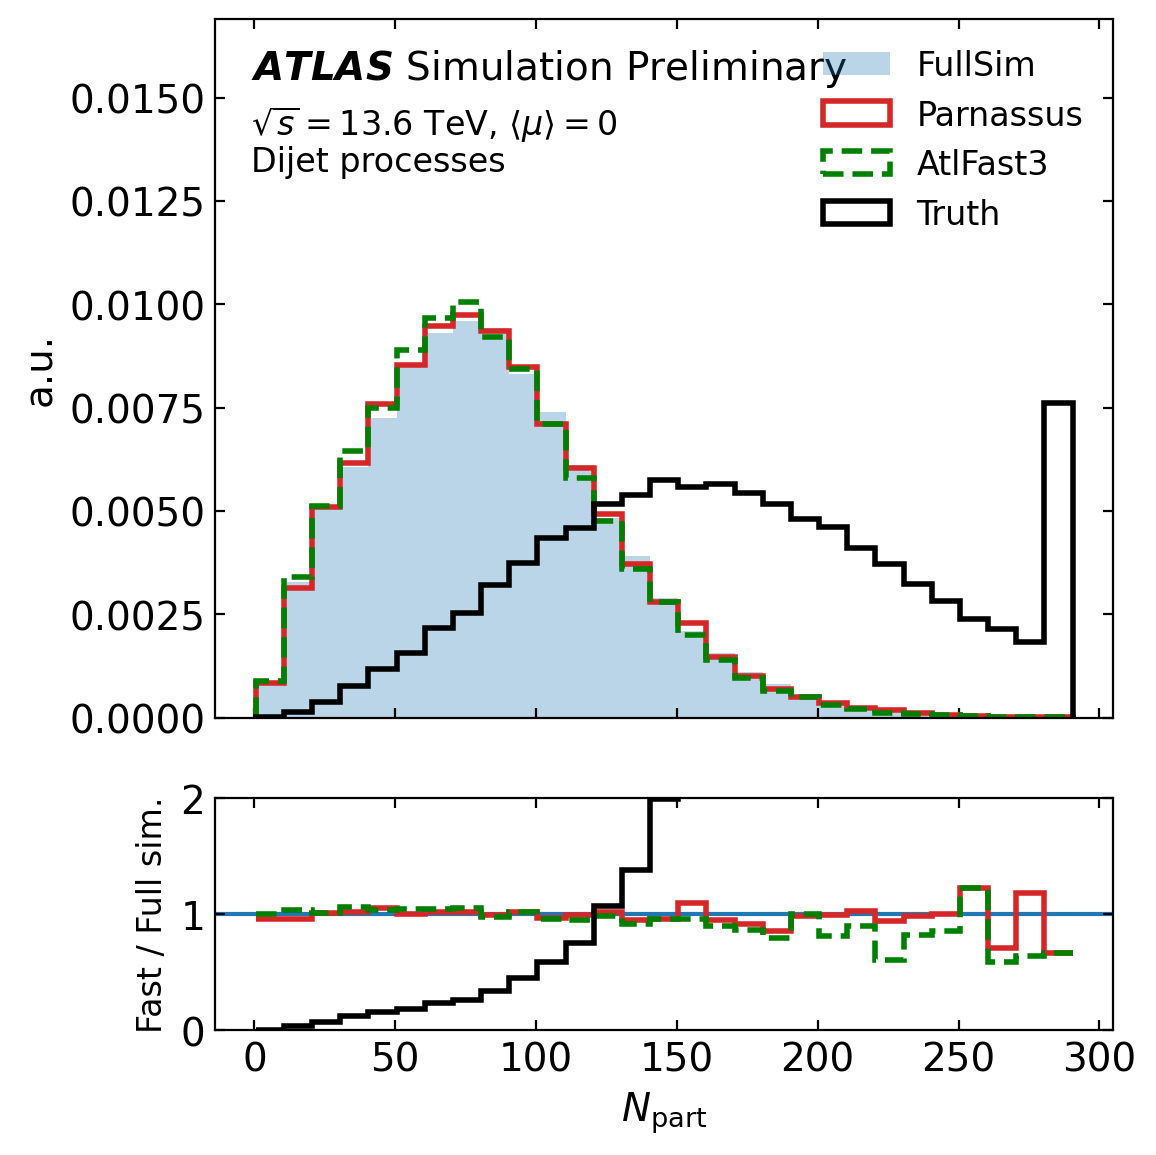

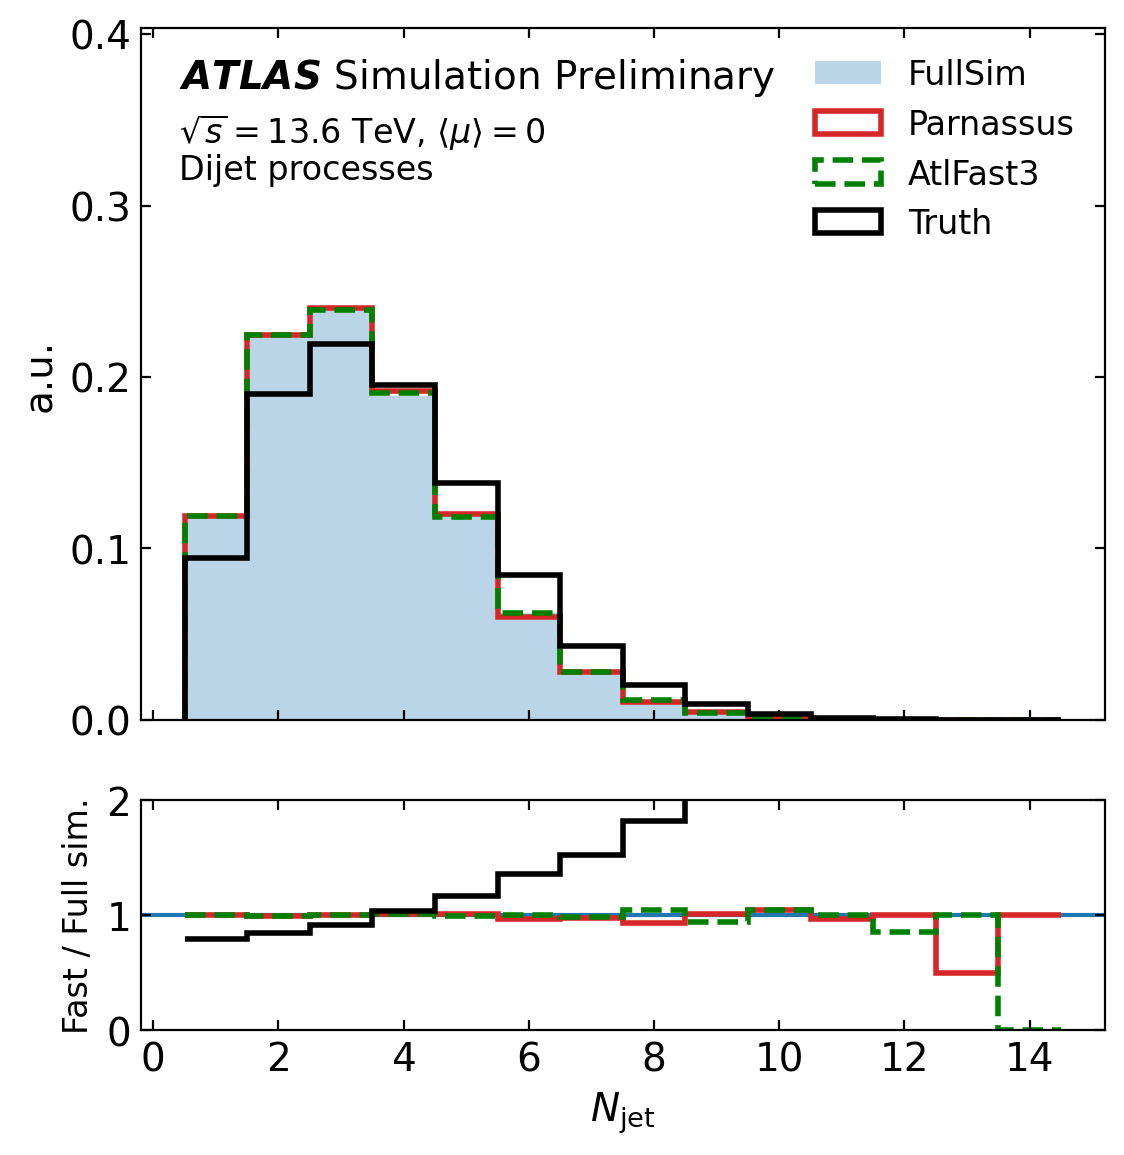

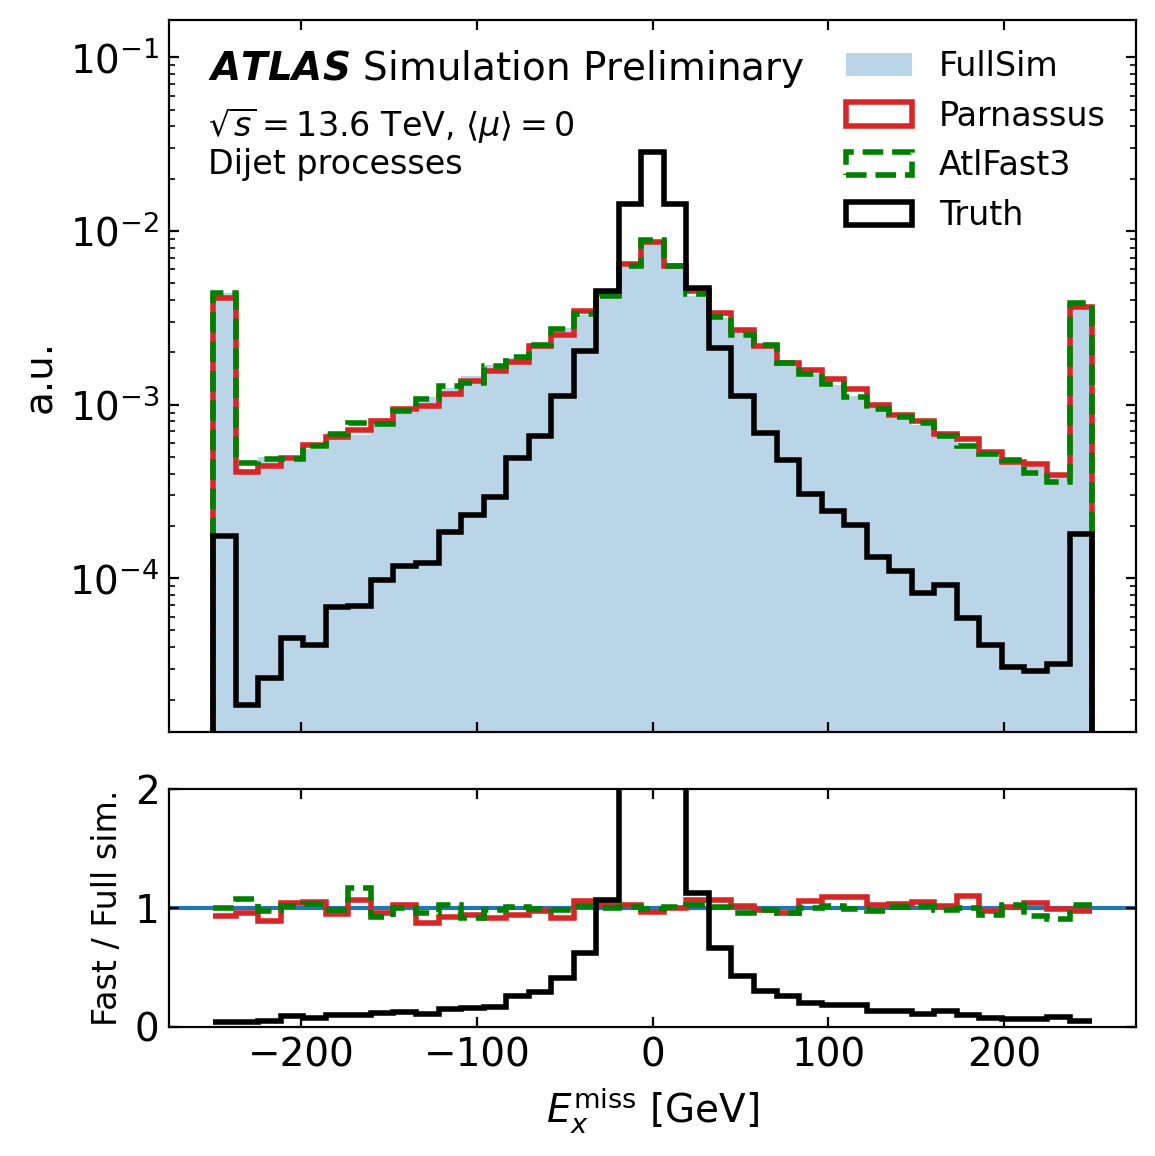

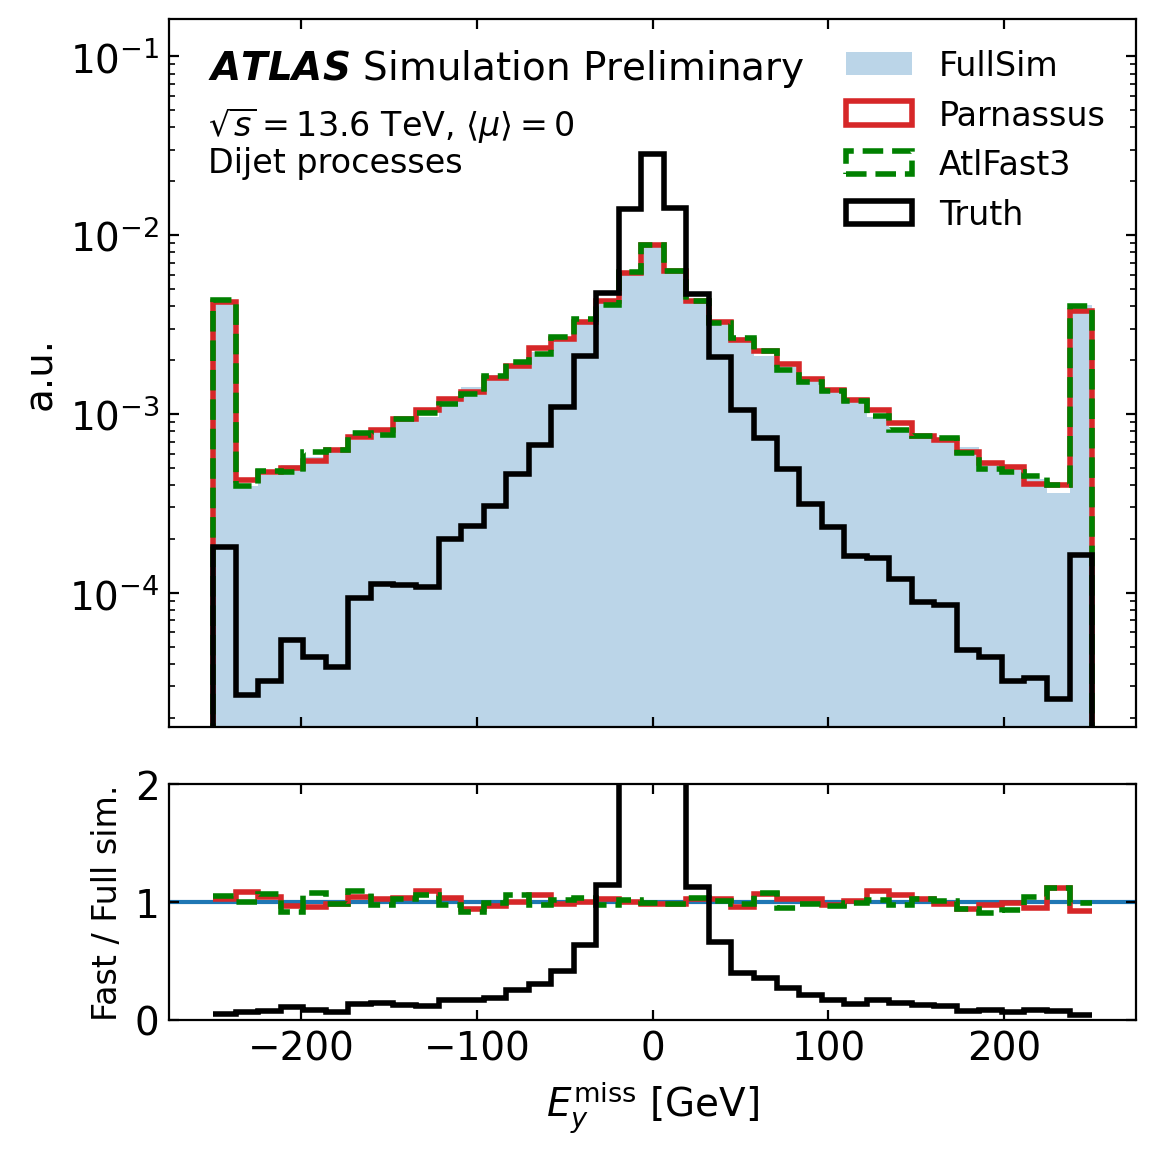

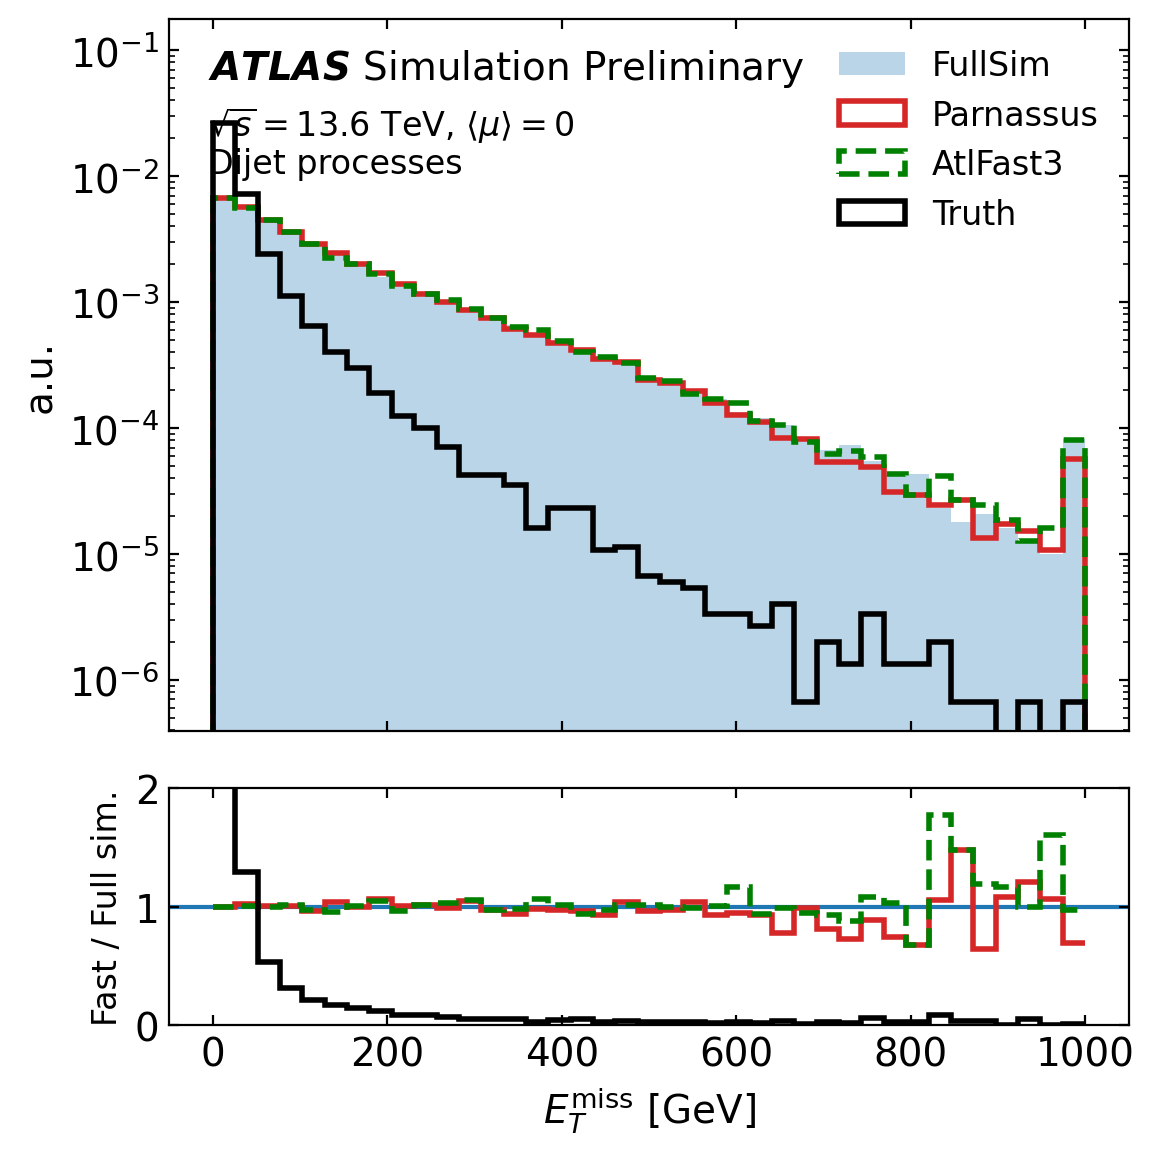

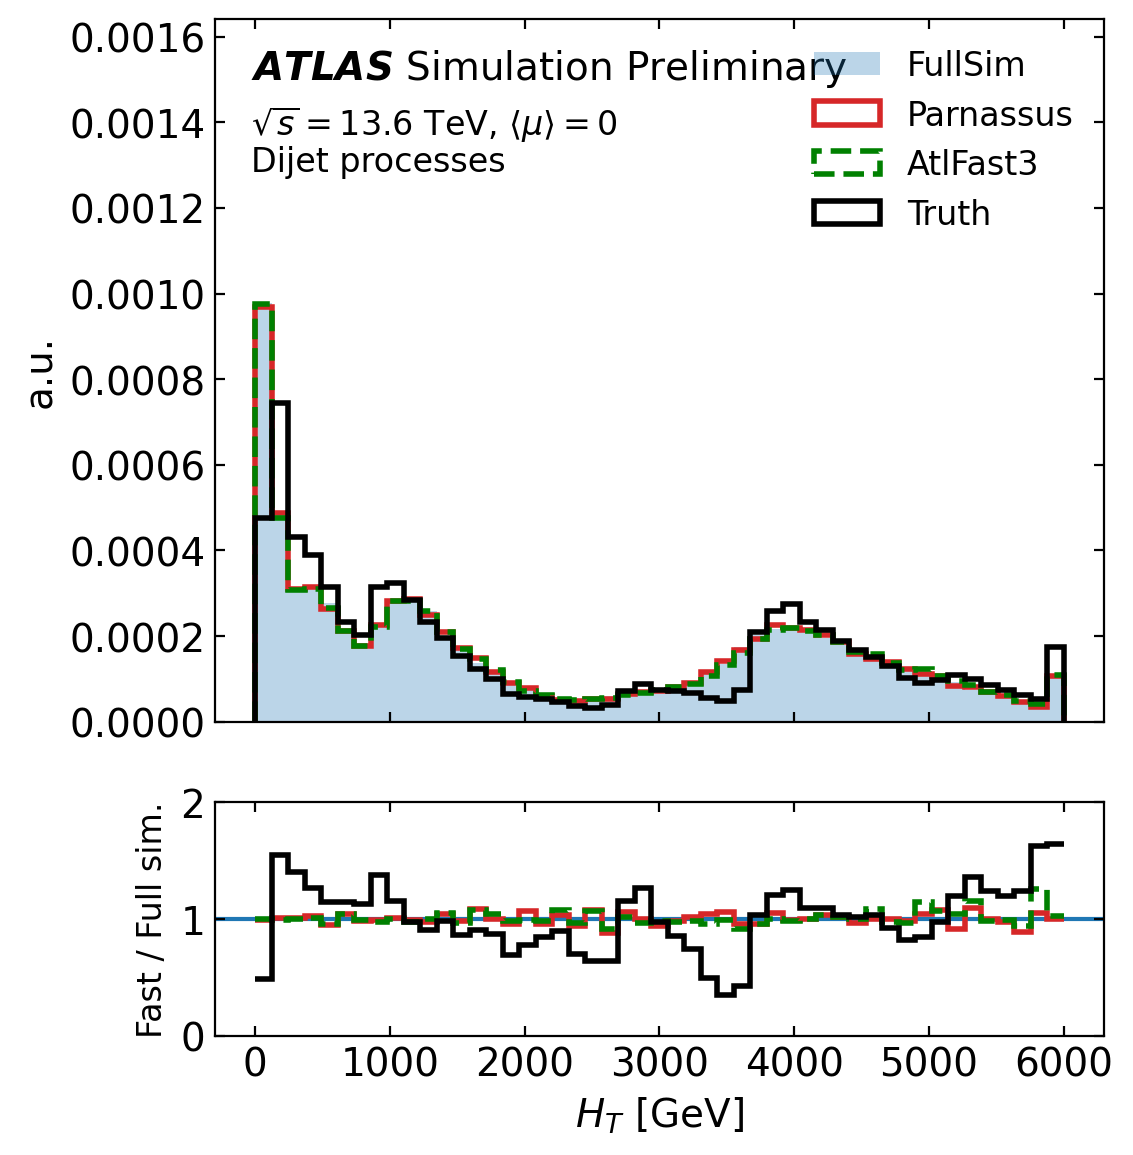

In [16]:
abs_bins_dict = {
    "n_part": {s: np.arange(0, 300, 10) + 0.5 for s in samples_data.keys()},
    "n_jets": {s: np.arange(0, 15, 1) + 0.5 for s in samples_data.keys()},
    "met_x":  {s: np.linspace(-250, 250, 40) for s in samples_data.keys()},
    "met_y":  {s: np.linspace(-250, 250, 40) for s in samples_data.keys()},
    "met_tot":  {s: np.linspace(0, 1000, 40) for s in samples_data.keys()},
    "ht":     {s: np.linspace(0, 6000, 50) for s in samples_data.keys()} if 'JZall' in samples_data else {s: np.linspace(0, 12000, 50) for s in samples_data.keys()},
}
evt_abs_var_list = ["n_part", "n_jets", "met_x", "met_y", "met_tot", "ht"]
evt_abs_xlabel_list = [
    r"$N_{\mathrm{part}}$",
    r"$N_{\mathrm{jet}}$",
    r"$E_{x}^{\mathrm{miss}}$ [GeV]",
    r"$E_{y}^{\mathrm{miss}}$ [GeV]",
    r"$E_{T}^{\mathrm{miss}}$ [GeV]",
    r"$H_T$ [GeV]",
]

for sample in samples_data.keys():
    value_truth = samples_data[sample]["all"]["tr"]
    for var, xlabel in zip(evt_abs_var_list, evt_abs_xlabel_list):
        bins = abs_bins_dict[var][sample]
        fig, ax_main, ax_ratio = _make_fig(xlabel, yscale="log" if 'met' in var else "linear")
        ref_counts = None

        for key in ['pf', *fms, 'tr']:
            if 'fm' in key:
                good_color = good_colors[xbins.index(int(key[2:]))]
            value = samples_data[sample]["all"][key]
            if var == "n_part":
                plot_data = value[card_varnames[key]] if key != "tr" else value[card_varnames["tr"]]
            else:
                plot_data = value[var]

            if key == "tr":
                s = settings_dict["tr"]
            elif key == "pf":
                s = settings_dict["pf"]
            else:
                s = settings_dict.get(key, settings_dict["fm"] | {"label": "Parnassus", "color": good_color})

            counts, _, _ = _hist_overflow(ax_main,
                plot_data, bins=bins, **s,
                density=True,
                histtype="stepfilled" if key in ("pf") else "step",
            )
            if key == "pf":
                ref_counts = counts
            else:
                _add_ratio_line(ax_ratio, counts, bins, ref_counts, s)

        _finalize_fig(fig, ax_main, ax_ratio)
        plt.show()

        fig.savefig(os.path.join(plot_dir, 'event_marginals', f"{sample}_event_marginal_{var}.png"))

## Jet-level marginals

In [17]:
def get_jet_features_dict(data):
    return {
        "pt": data["jets_pt"],
        "eta": data["jets_eta"],
        "phi": reshape_phi(data["jets_phi"]),
        "d2": np.array([np.log(el + 1e-9) for el in data["jets_d2"]], dtype=object),
        "c2": data["jets_c2"],
        "idx": data[
            "jets_pt"
        ],  # fake, not used, serves for compatibility with "matching" function
    }

In [18]:
def get_leading_jet_features_dict(data, subleading=False):
    if subleading:
        jet_idx = 1
    else:
        jet_idx = 0

    return {
        "pt": np.array(
            [el[jet_idx] for el in data["jets_pt"] if len(el) > jet_idx], dtype=np.float32
        ),
        "eta": np.array(
            [el[jet_idx] for el in data["jets_eta"] if len(el) > jet_idx], dtype=np.float32
        ),
        "phi": np.array(
            [el[jet_idx] for el in reshape_phi(data["jets_phi"]) if len(el) > jet_idx],
            dtype=np.float32,
        ),
        "d2": np.array(
            [np.log(el[jet_idx] + 1e-9) for el in data["jets_d2"] if len(el) > jet_idx],
            dtype=np.float32,
        ),
        "c2": np.array(
            [el[jet_idx] for el in data["jets_c2"] if len(el) > jet_idx], dtype=np.float32
        ),
        "idx": np.array(
            [el[jet_idx] for el in data["jets_pt"] if len(el) > jet_idx], dtype=np.float32
        ),
    }

In [19]:
jet_dicts = {key: {} for key in samples_data.keys()}
for sample in samples_data.keys():
    for key in samples_data[sample]["jet"].keys():
        jet_dicts[sample][key] = get_jet_features_dict(samples_data[sample]["all"][key])

In [20]:
leading_jet_dicts = {key: {} for key in samples_data.keys()}
for sample in samples_data.keys():
    for key in samples_data[sample]["jet"].keys():
        leading_jet_dicts[sample][key] = get_leading_jet_features_dict(
            samples_data[sample]["all"][key]
        )

subleading_jet_dicts = {key: {} for key in samples_data.keys()}
for sample in samples_data.keys():
    for key in samples_data[sample]["jet"].keys():
        subleading_jet_dicts[sample][key] = get_leading_jet_features_dict(
            samples_data[sample]["all"][key], subleading=True
        )

In [21]:
bins_jet_marg = {
    "pt": defaultdict(constant_factory(np.linspace(0, 4000, 40))),
    "eta": defaultdict(constant_factory(np.linspace(-2.5, 2.5, 40))),
    "phi": defaultdict(constant_factory(np.linspace(-np.pi, np.pi, 40))),
    "d2": defaultdict(constant_factory(np.linspace(-6, 2, 40))),
    "c2": defaultdict(constant_factory(np.linspace(0, 0.32, 40))),
}
# if 'WprimeWZ' in samples_data:
#     bins_jet_marg["d2"] = defaultdict(constant_factory(np.linspace(-2.0, 4.0, 40)))

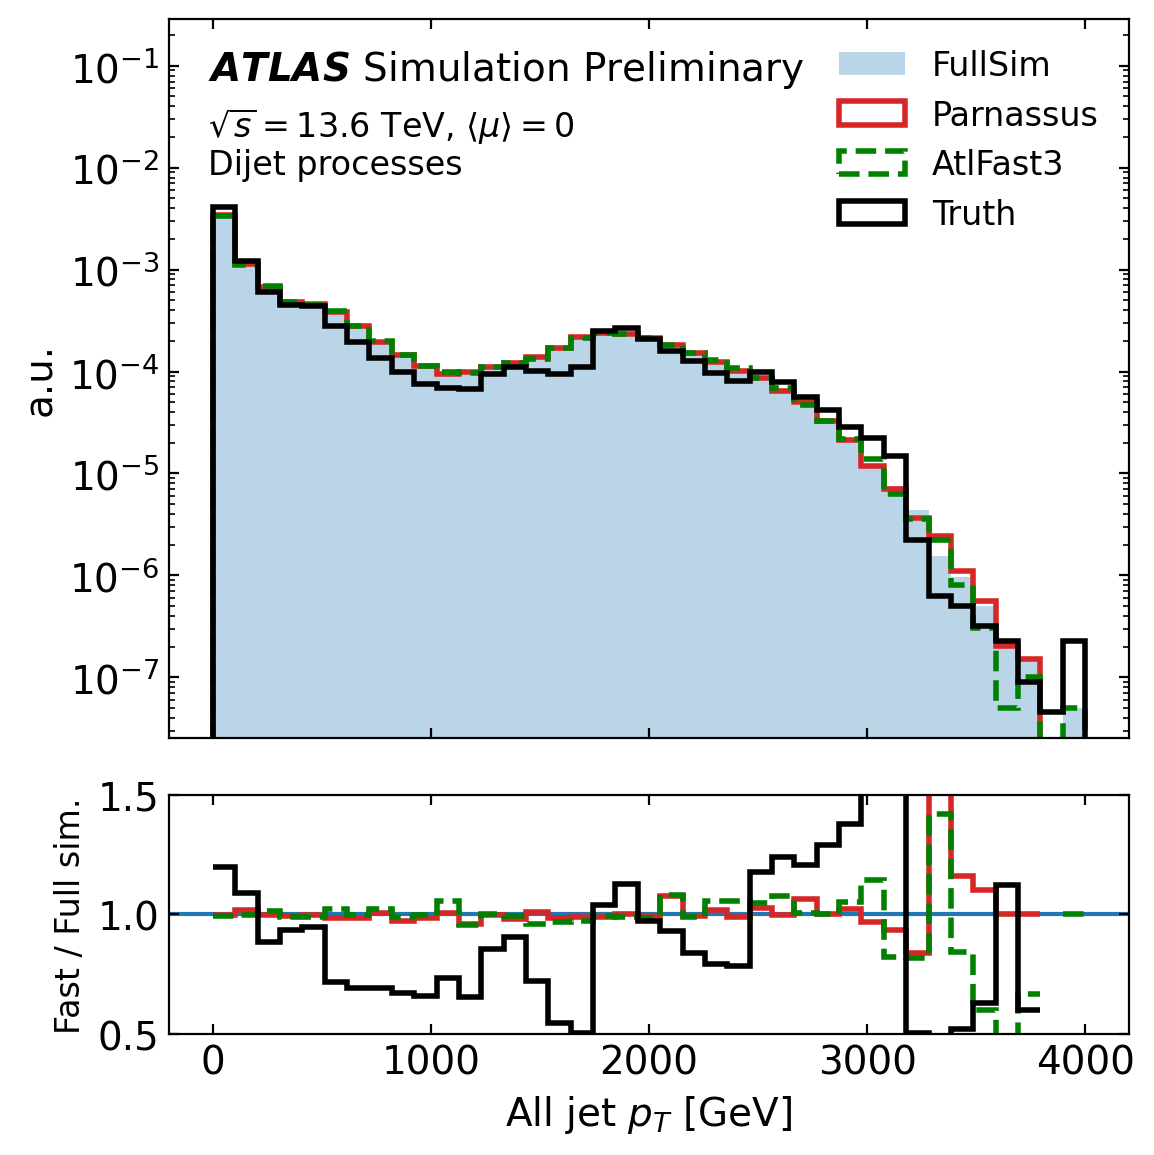

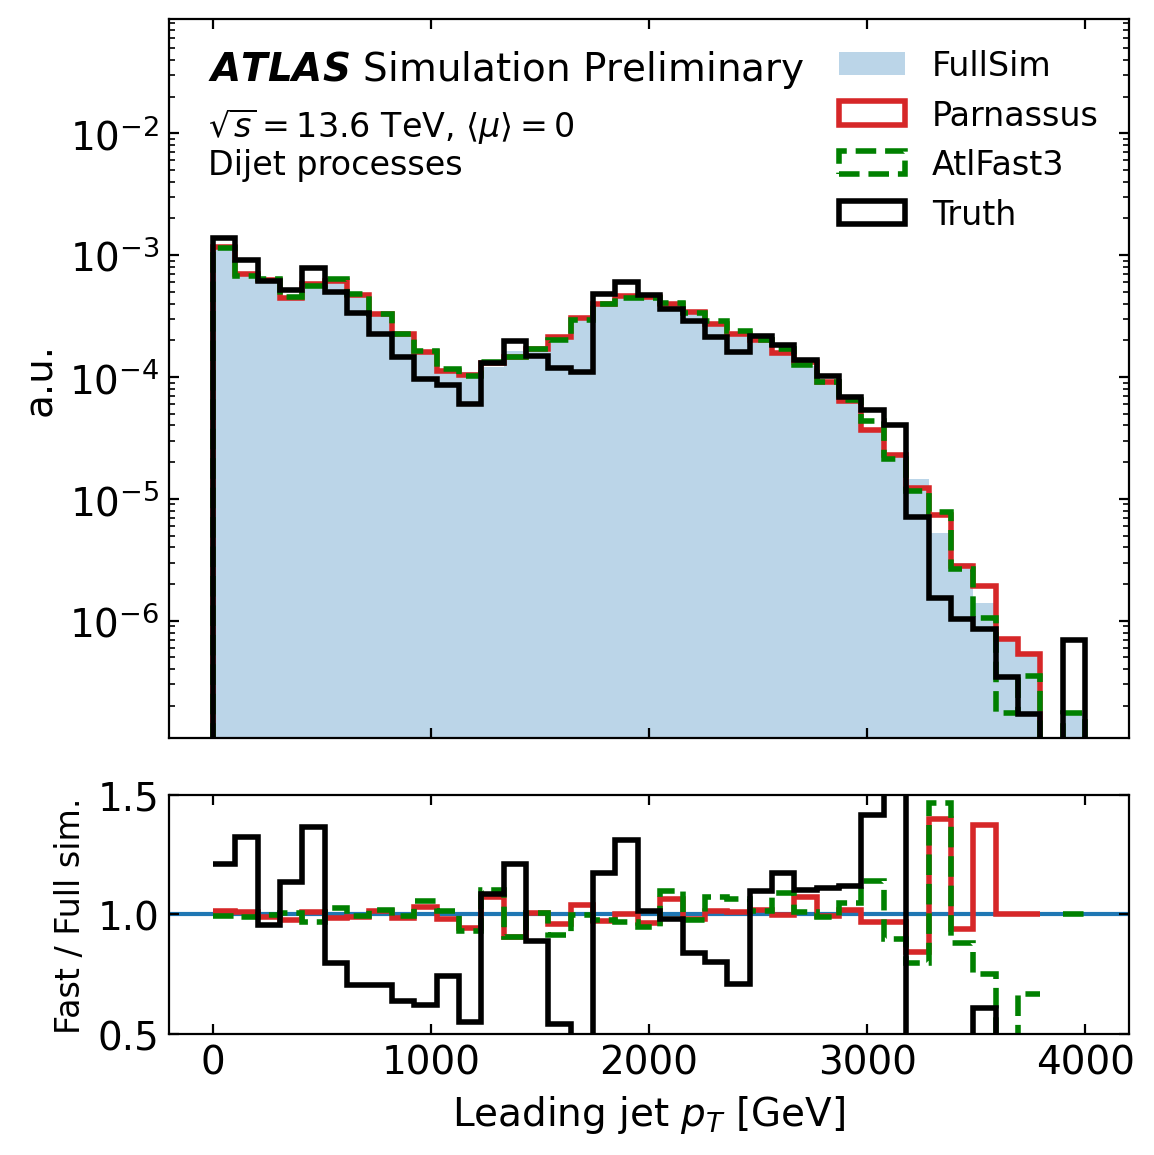

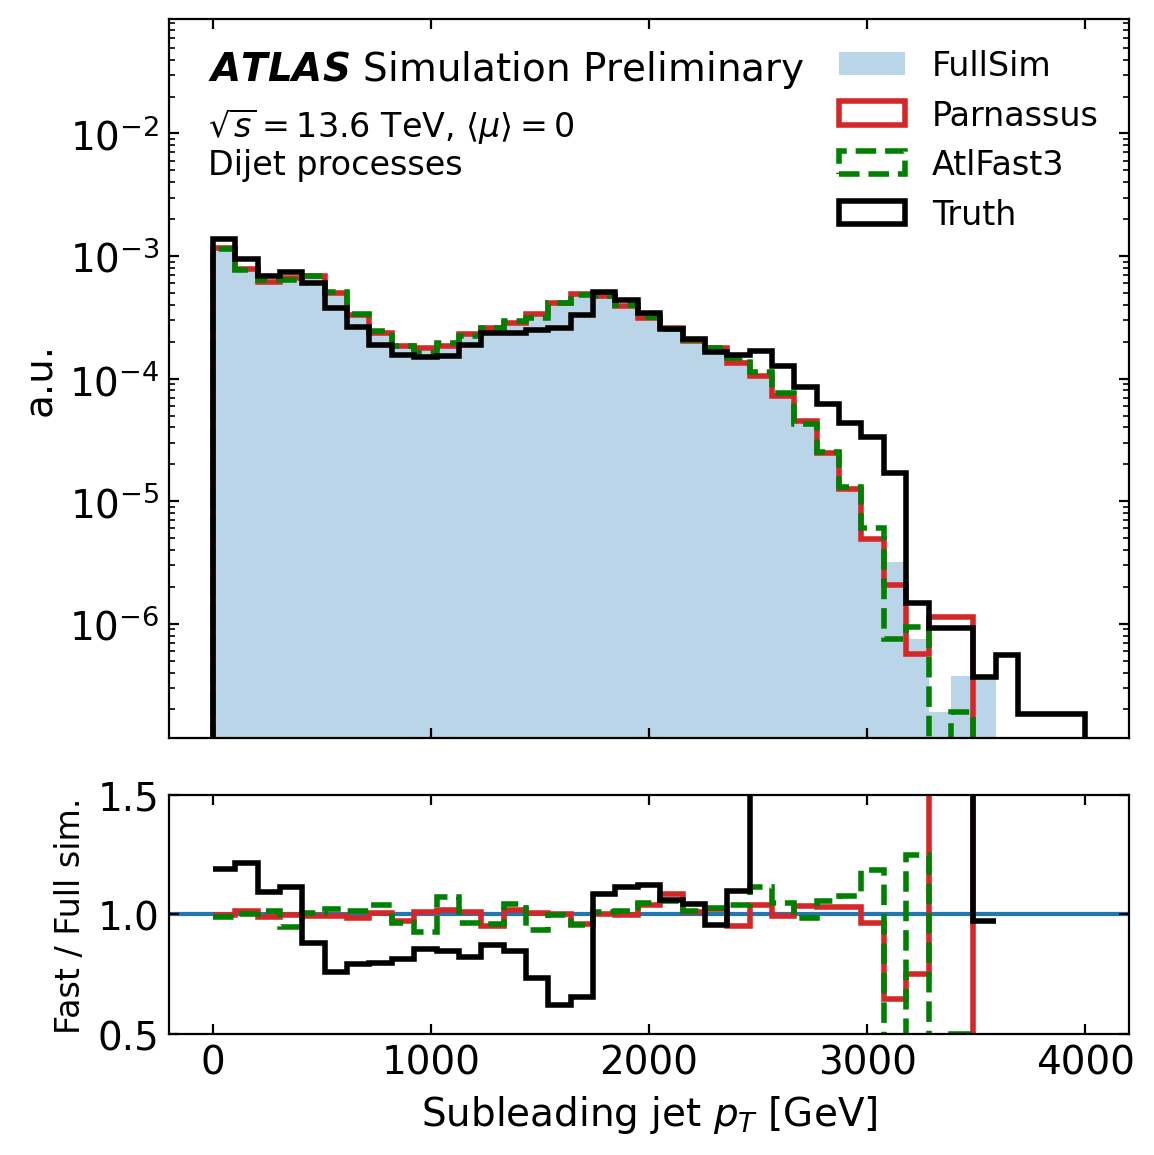

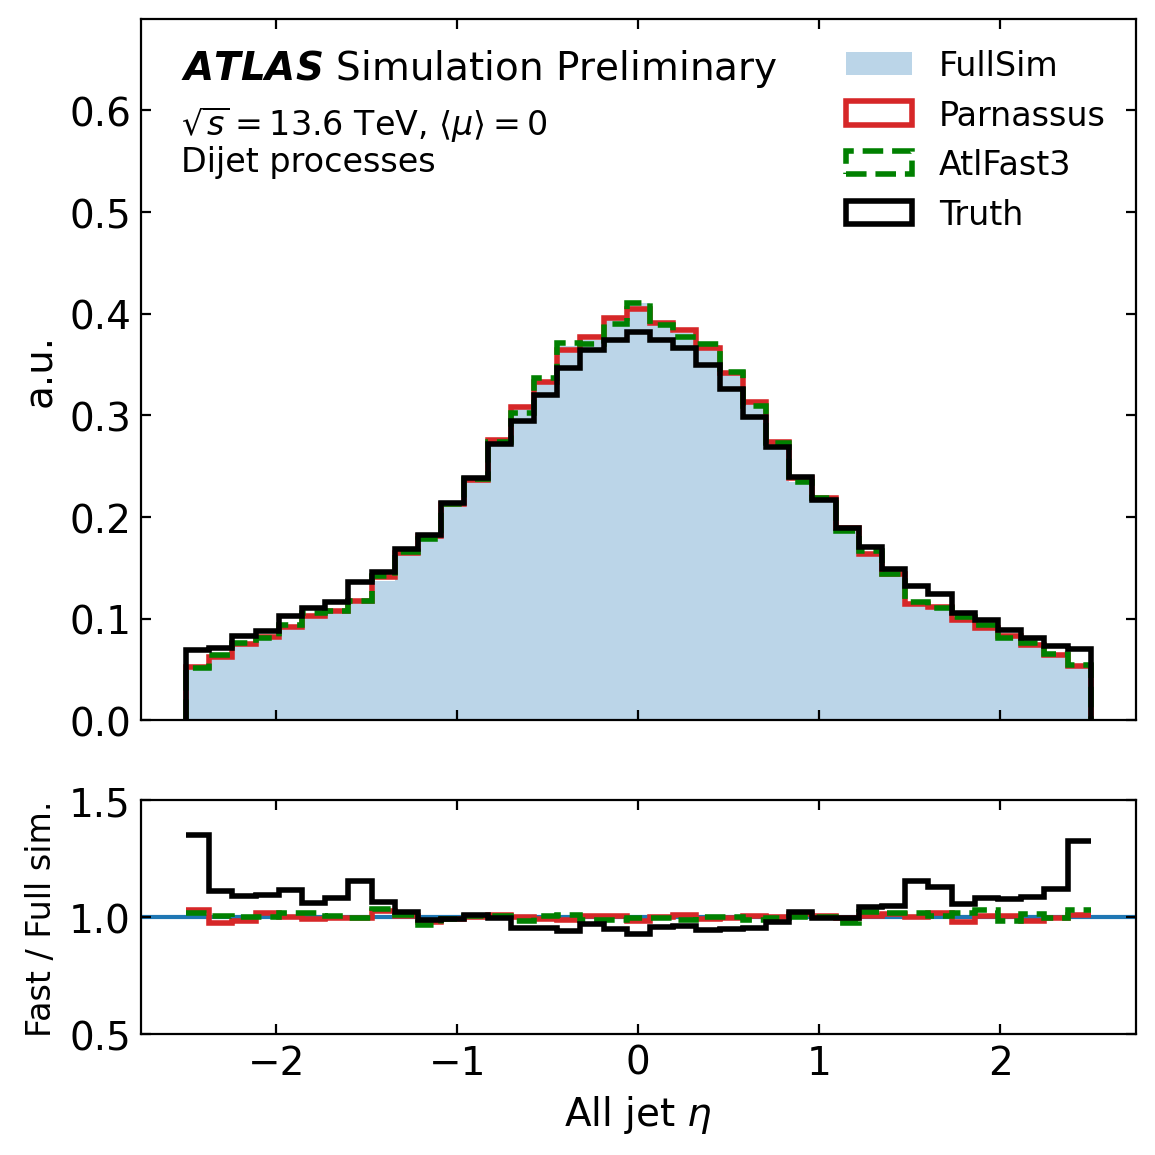

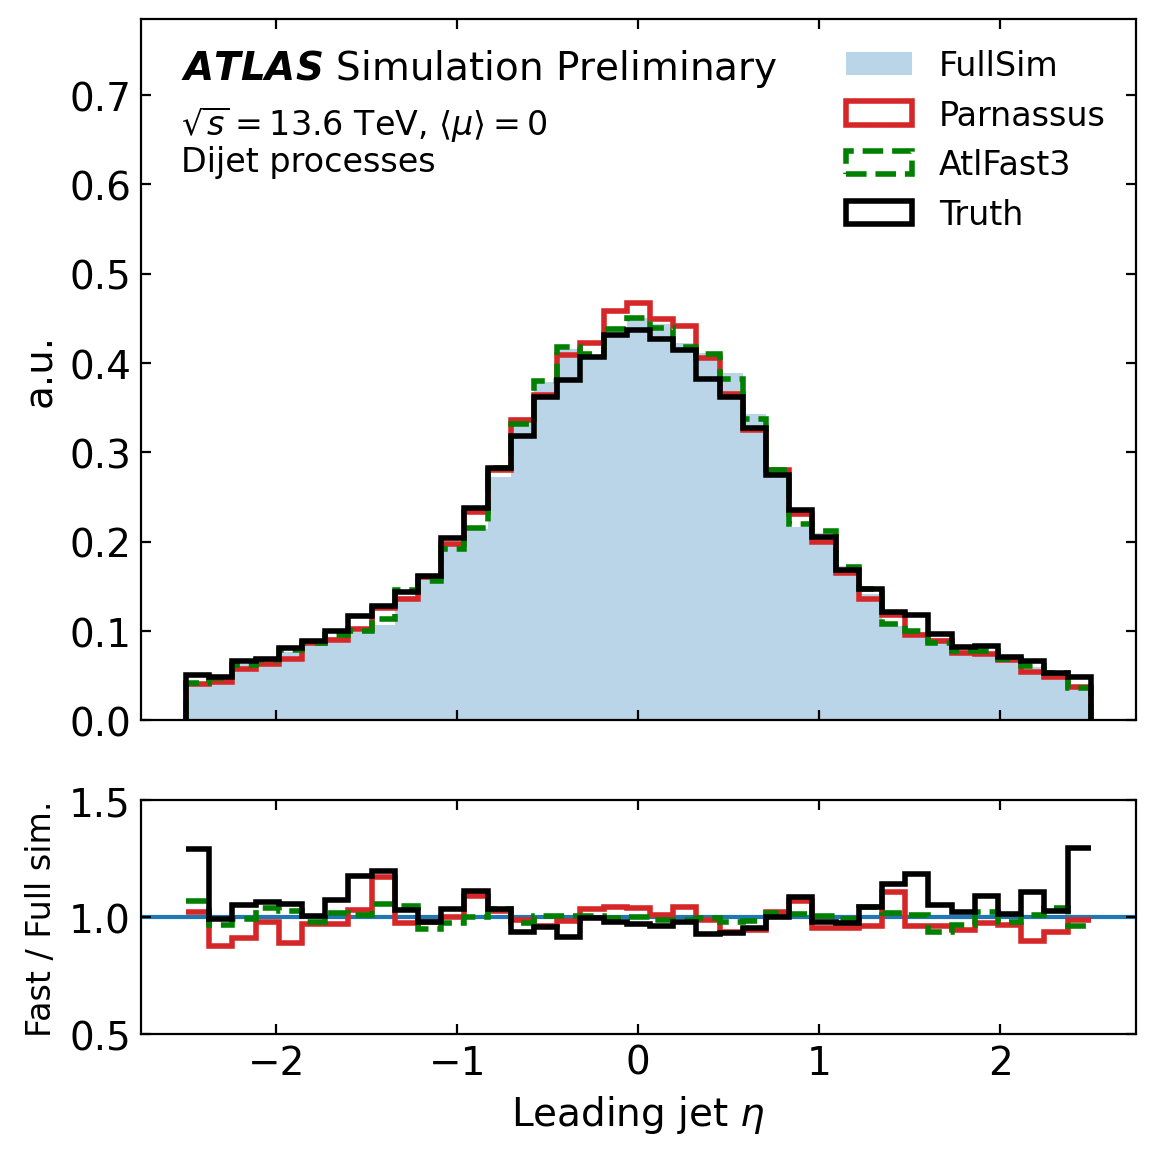

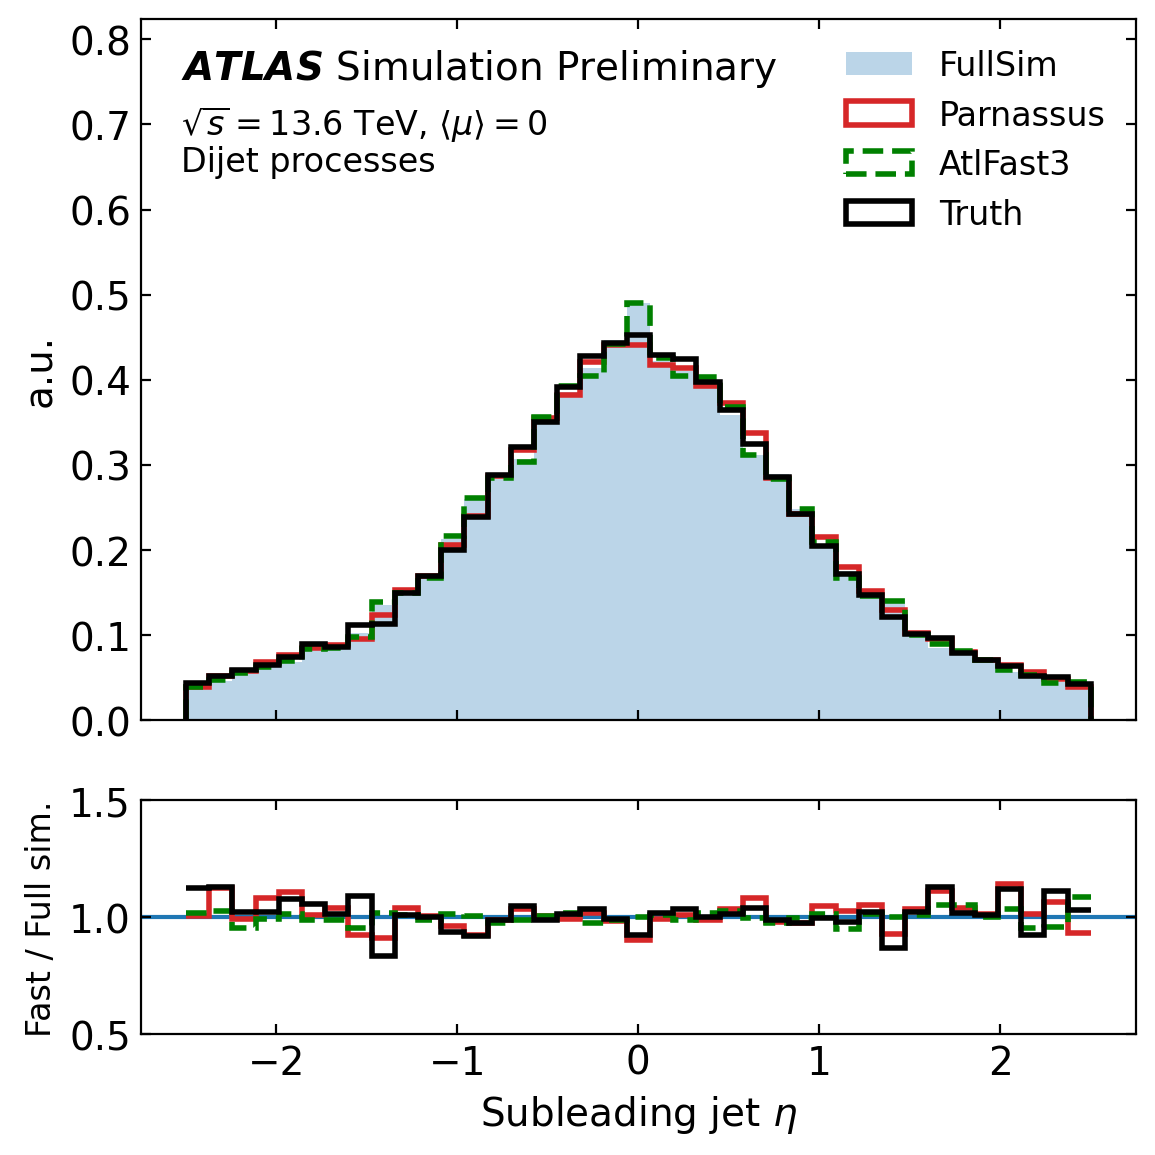

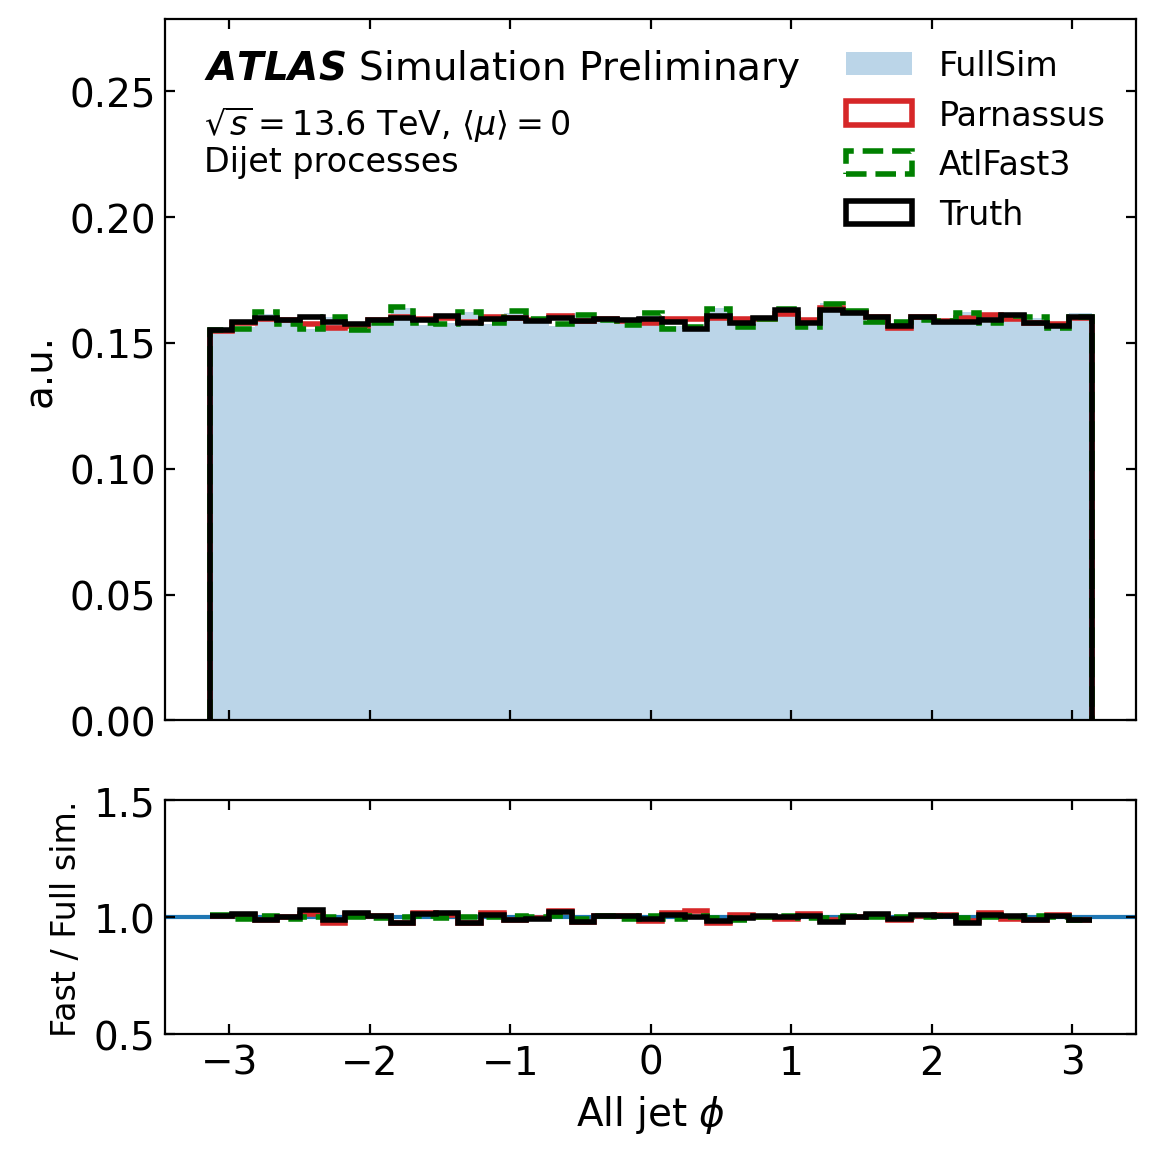

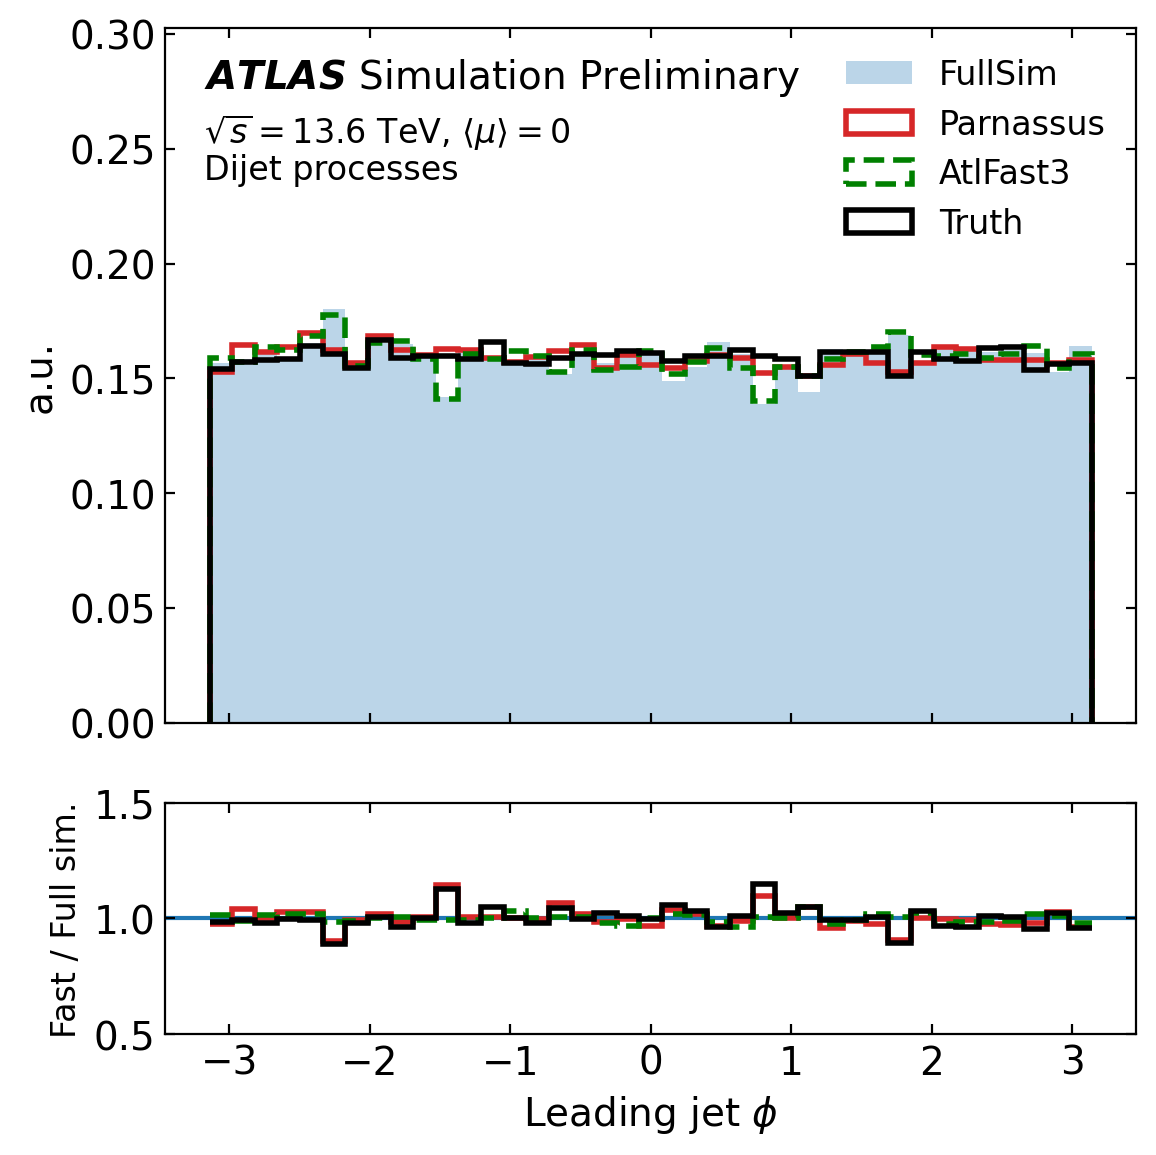

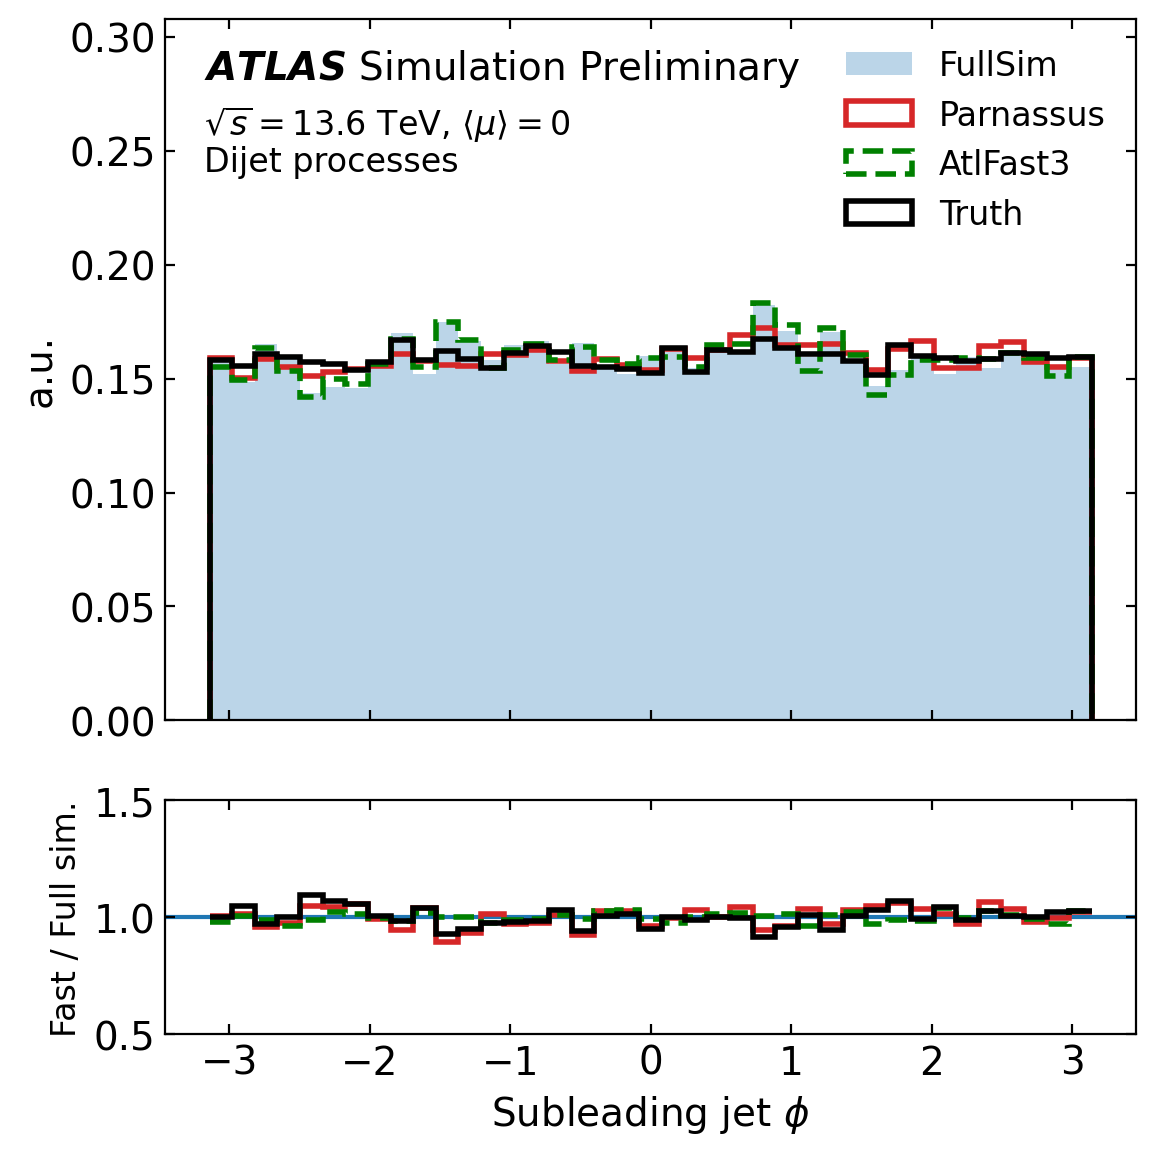

/tmp/ipykernel_716186/1026164328.py:35: RuntimeWarning: invalid value encountered in log
  plot_data = np.log(plot_data + 1e-9)


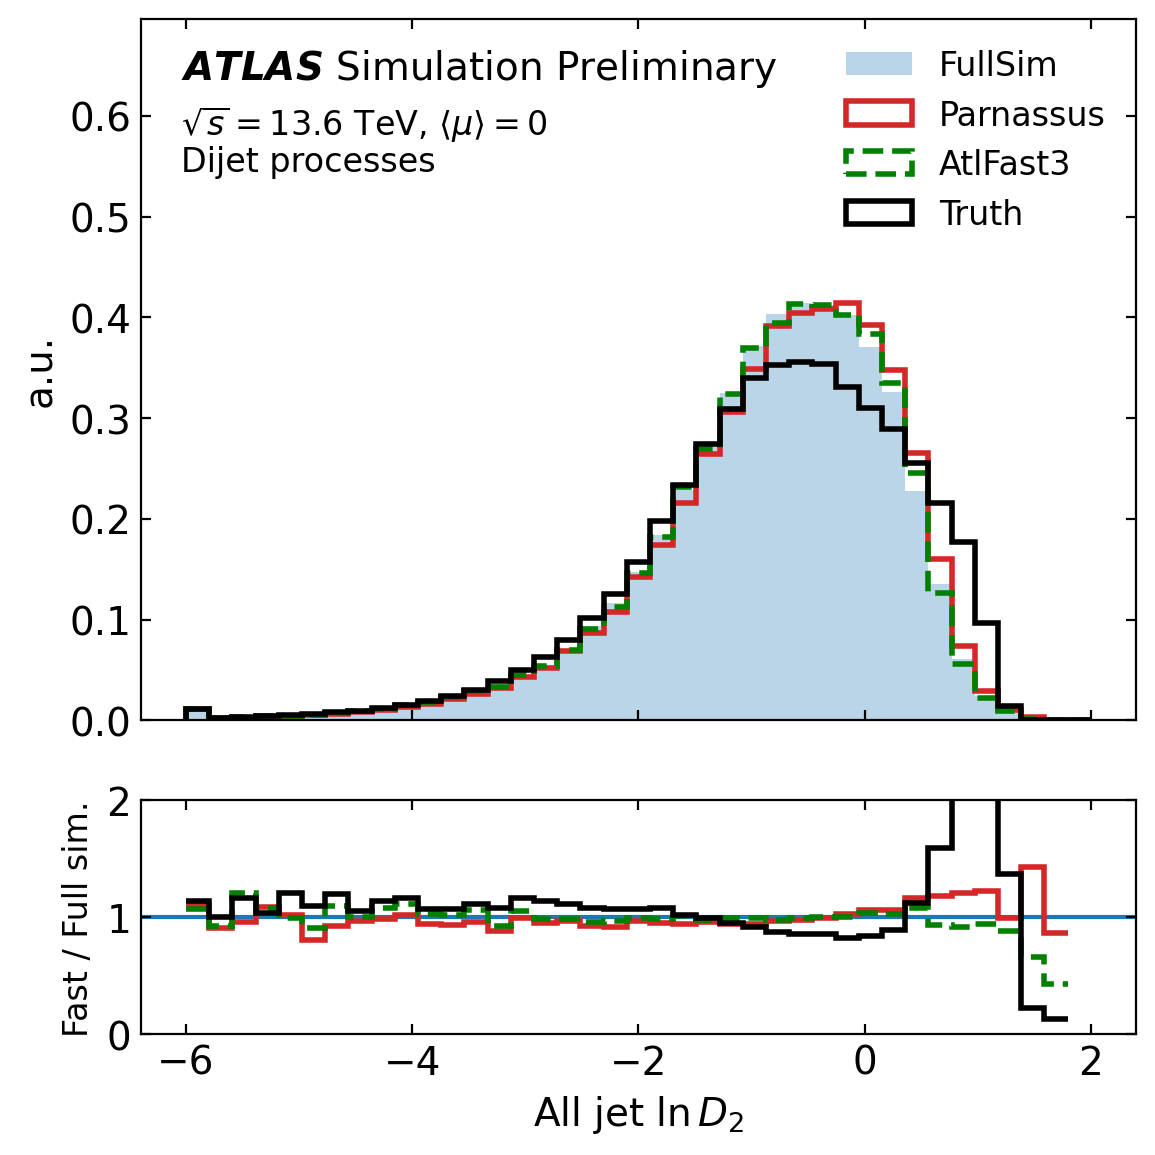

/tmp/ipykernel_716186/1026164328.py:35: RuntimeWarning: invalid value encountered in log
  plot_data = np.log(plot_data + 1e-9)


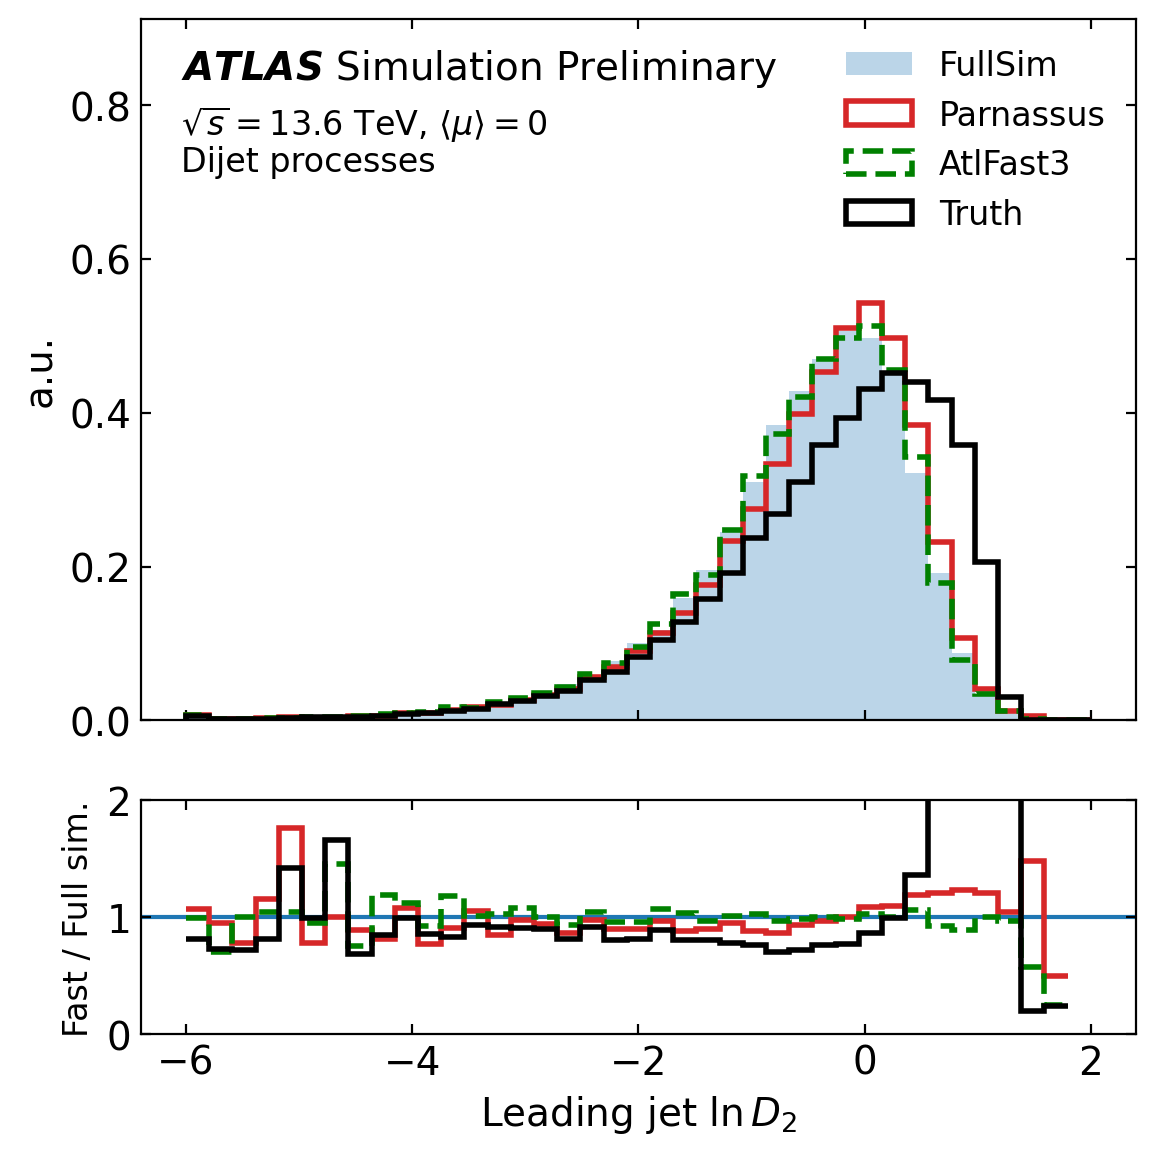

/tmp/ipykernel_716186/1026164328.py:35: RuntimeWarning: invalid value encountered in log
  plot_data = np.log(plot_data + 1e-9)


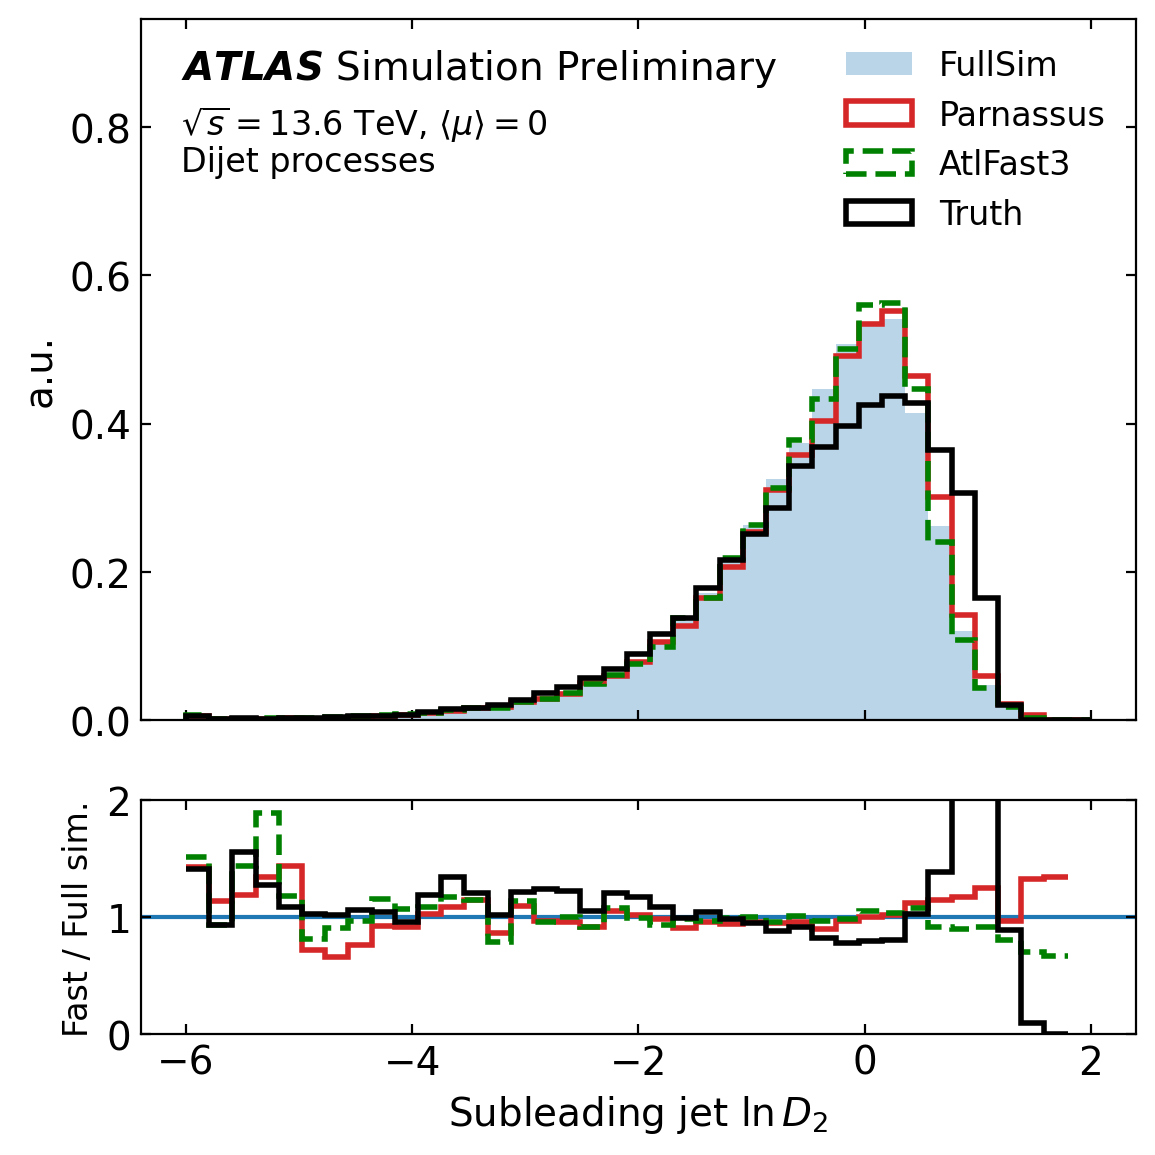

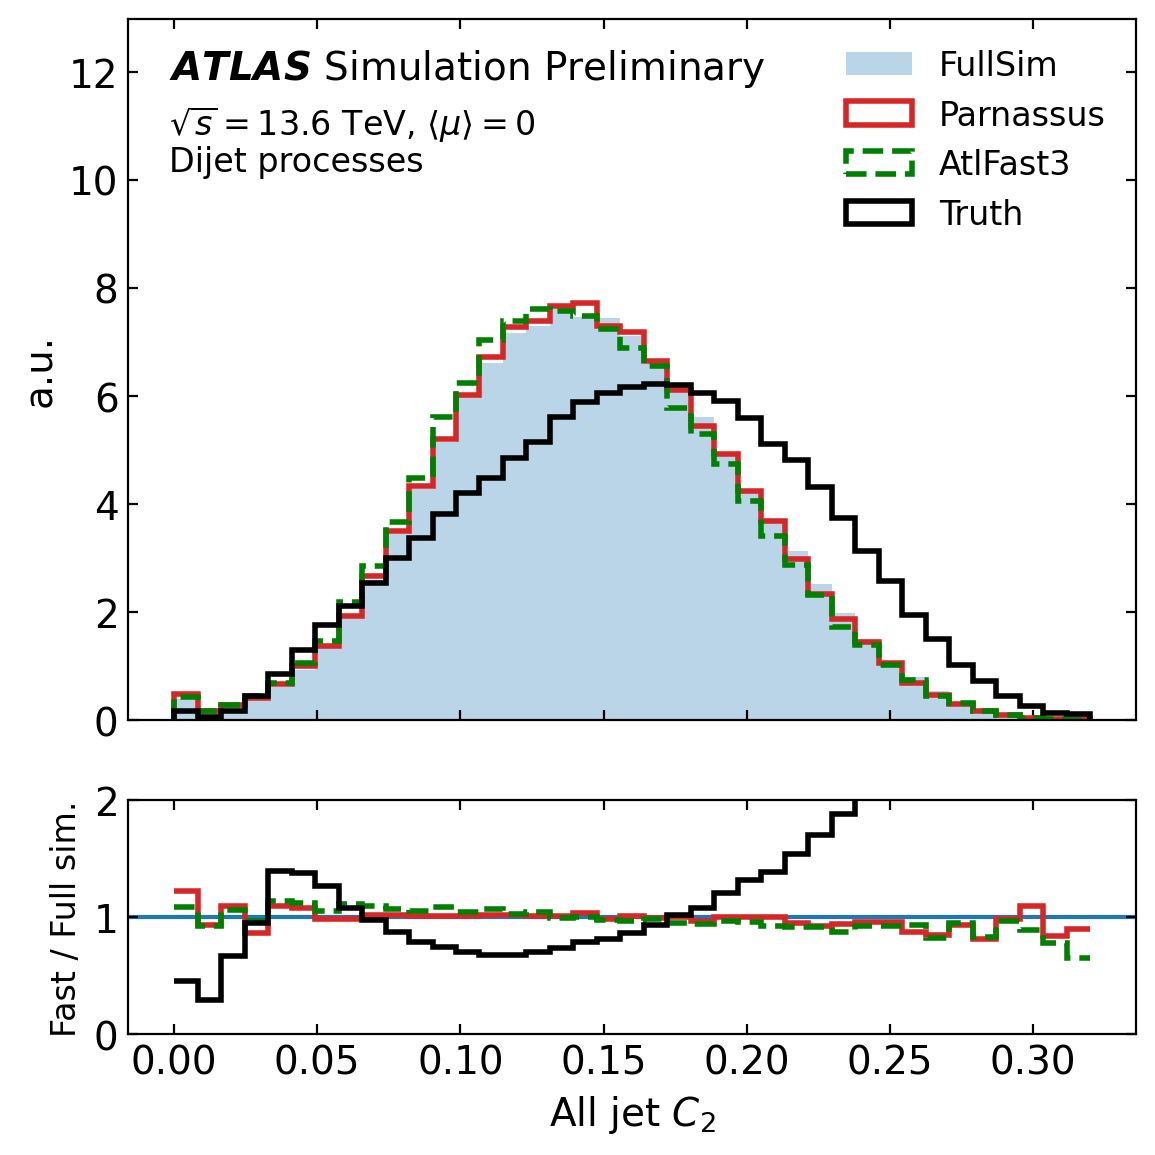

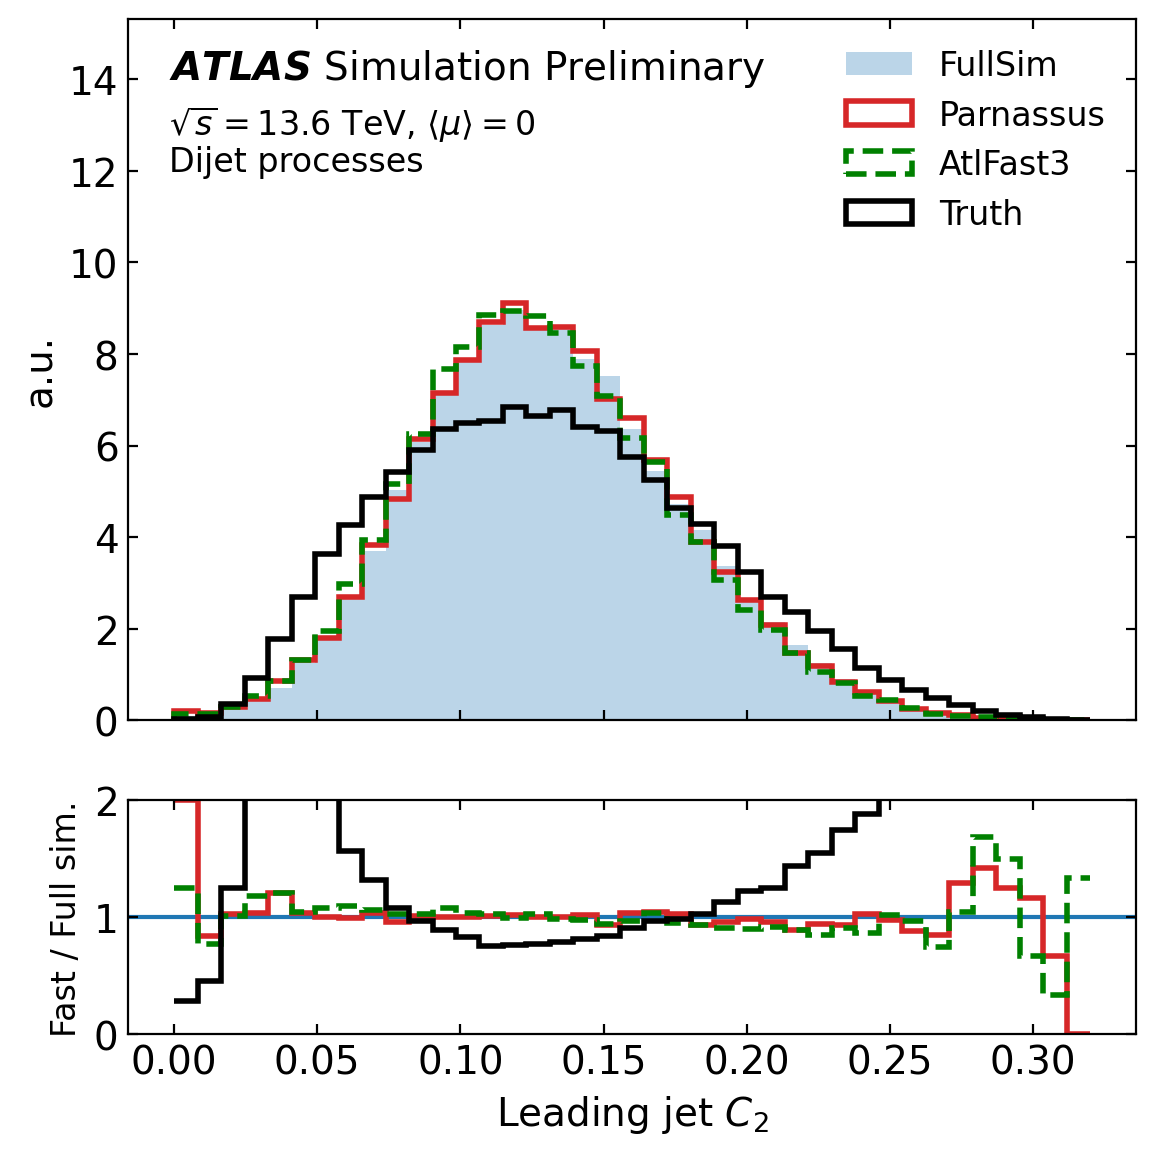

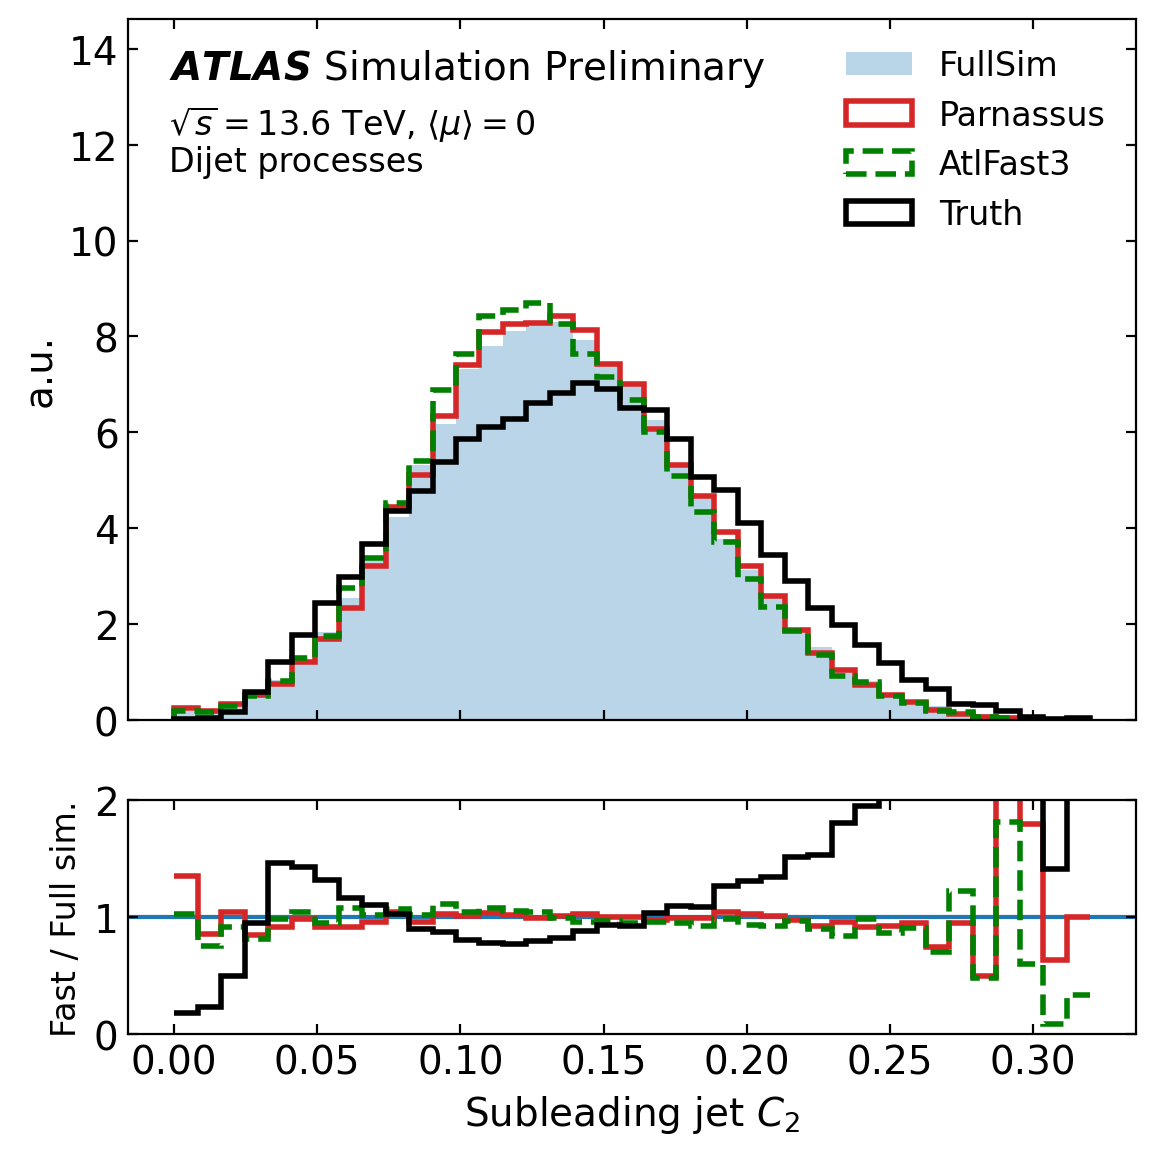

In [22]:

jet_res_var_list = ["pt", "eta", "phi", "d2", "c2"]
jet_res_xlabel_list = [
    r"jet $p_T$ [GeV]",
    r"jet $\eta$",
    r"jet $\phi$",
    r"jet $\ln{D_2}$",
    r"jet $C_2$",
]

for sample in samples_data.keys():
    for var, xlabel in zip(jet_res_var_list, jet_res_xlabel_list):
        for jet_selection in ["All", "Leading", "Subleading"]:

            new_xlabel = f"{jet_selection} {xlabel}"
            fig, ax_main, ax_ratio = _make_fig(new_xlabel, yscale="log" if var == "pt" else "linear", 
                                               ratio_ylim=(0.5, 1.5) if var in ["pt", "eta", "phi"] else (0.0, 2.0))
            ref_counts = None

            for key in ['pf', *fms, 'tr']:
                if 'fm' in key:
                    good_color = good_colors[xbins.index(int(key[2:]))]
                s = settings_dict.get(key, settings_dict["fm"] | {"label": "Parnassus", "color": good_color})

                if jet_selection == "All":
                    plot_data = jet_dicts[sample][key][var]
                    plot_data = np.concatenate(plot_data) # Flatten list of arrays into a single array
                elif jet_selection == "Leading":
                    plot_data = leading_jet_dicts[sample][key][var]
                elif jet_selection == "Subleading":
                    plot_data = subleading_jet_dicts[sample][key][var]
                else:
                    raise ValueError(f"Unknown jet selection: {jet_selection}")
        
                if var == "d2":
                    plot_data = np.log(plot_data + 1e-9)

                counts, _, _ = _hist_overflow(ax_main,
                    plot_data,
                    bins=bins_jet_marg[var][sample],
                    **s,
                    density=True,
                    histtype="stepfilled" if key == "pf" else "step",
                )
                if key == "pf":
                    ref_counts = counts
                else:
                    _add_ratio_line(ax_ratio, counts, bins_jet_marg[var][sample], ref_counts, s)

            if var == "pt":
                ### expand current ymax by factor 10
                ylo, yhi = ax_main.get_ylim()
                ax_main.set_ylim(ylo, yhi * 10)
            _finalize_fig(fig, ax_main, ax_ratio)
            plt.show()

            fig.savefig(os.path.join(plot_dir, 'jet_marginals', f"{sample}_{jet_selection.lower()}_jet_marginal_{var}.png"))
            fig.savefig(os.path.join(plot_dir, 'jet_marginals', f"{sample}_{jet_selection.lower()}_jet_marginal_{var}.pdf"))


## Particle-level marginals

In [23]:
bins_1d = {
    "pt": defaultdict(constant_factory(np.linspace(0, 3000, 40))),
    "eta": defaultdict(constant_factory(np.linspace(-2.7, 2.7, 40))),
    "phi": defaultdict(constant_factory(np.linspace(-np.pi, np.pi, 40))),
}

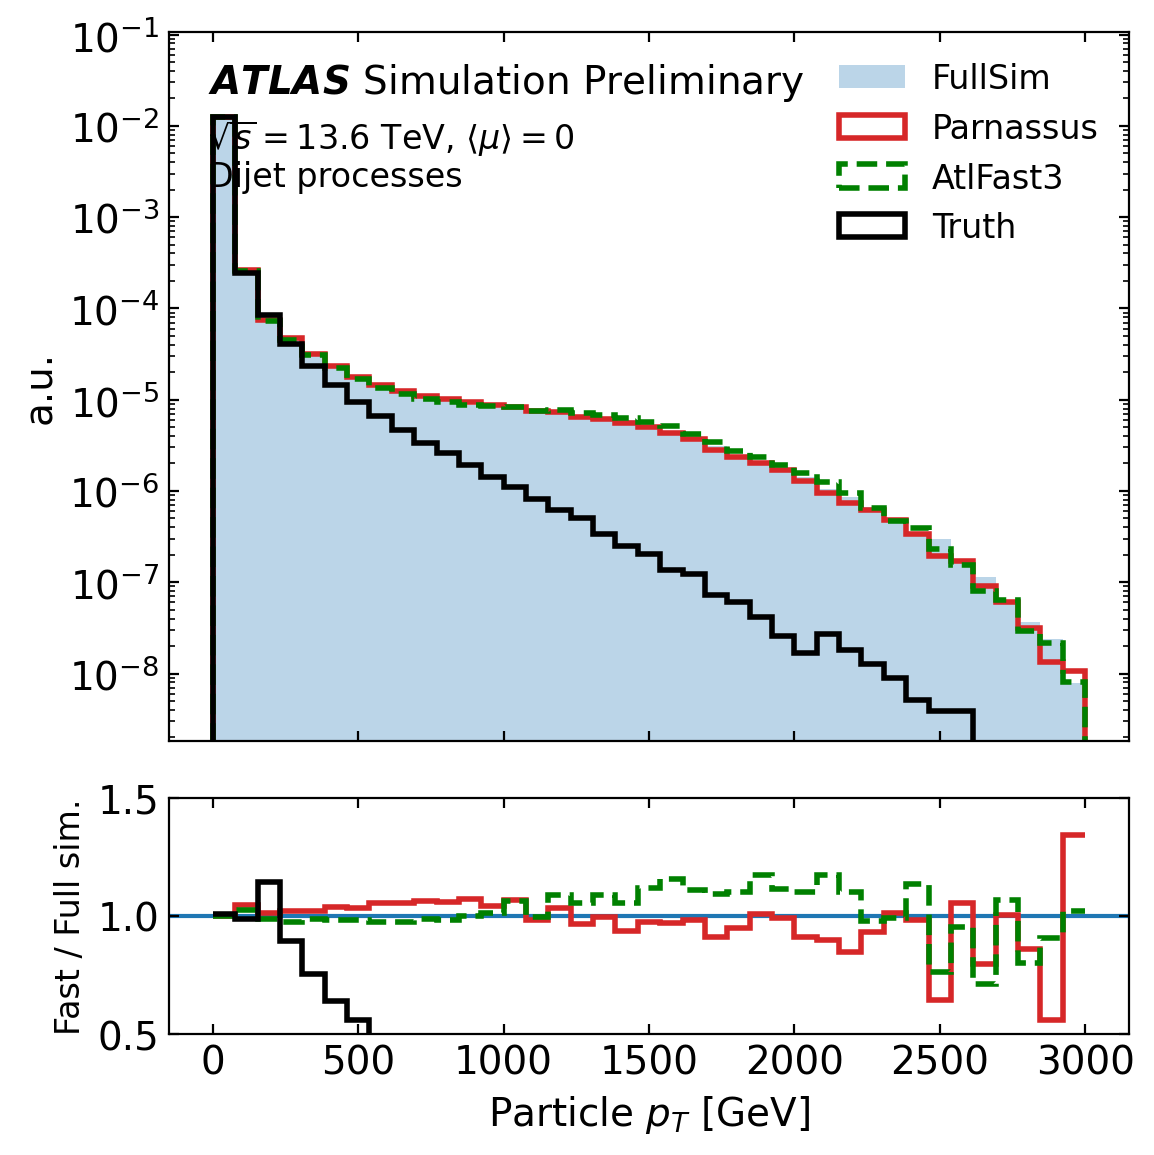

pf eta range: -2.699971914291382 to 2.699983596801758
fm50 eta range: -2.699936628341675 to 2.6997501850128174
dl eta range: -2.699976921081543 to 2.699993848800659
tr eta range: -2.699998378753662 to 2.6999993324279785


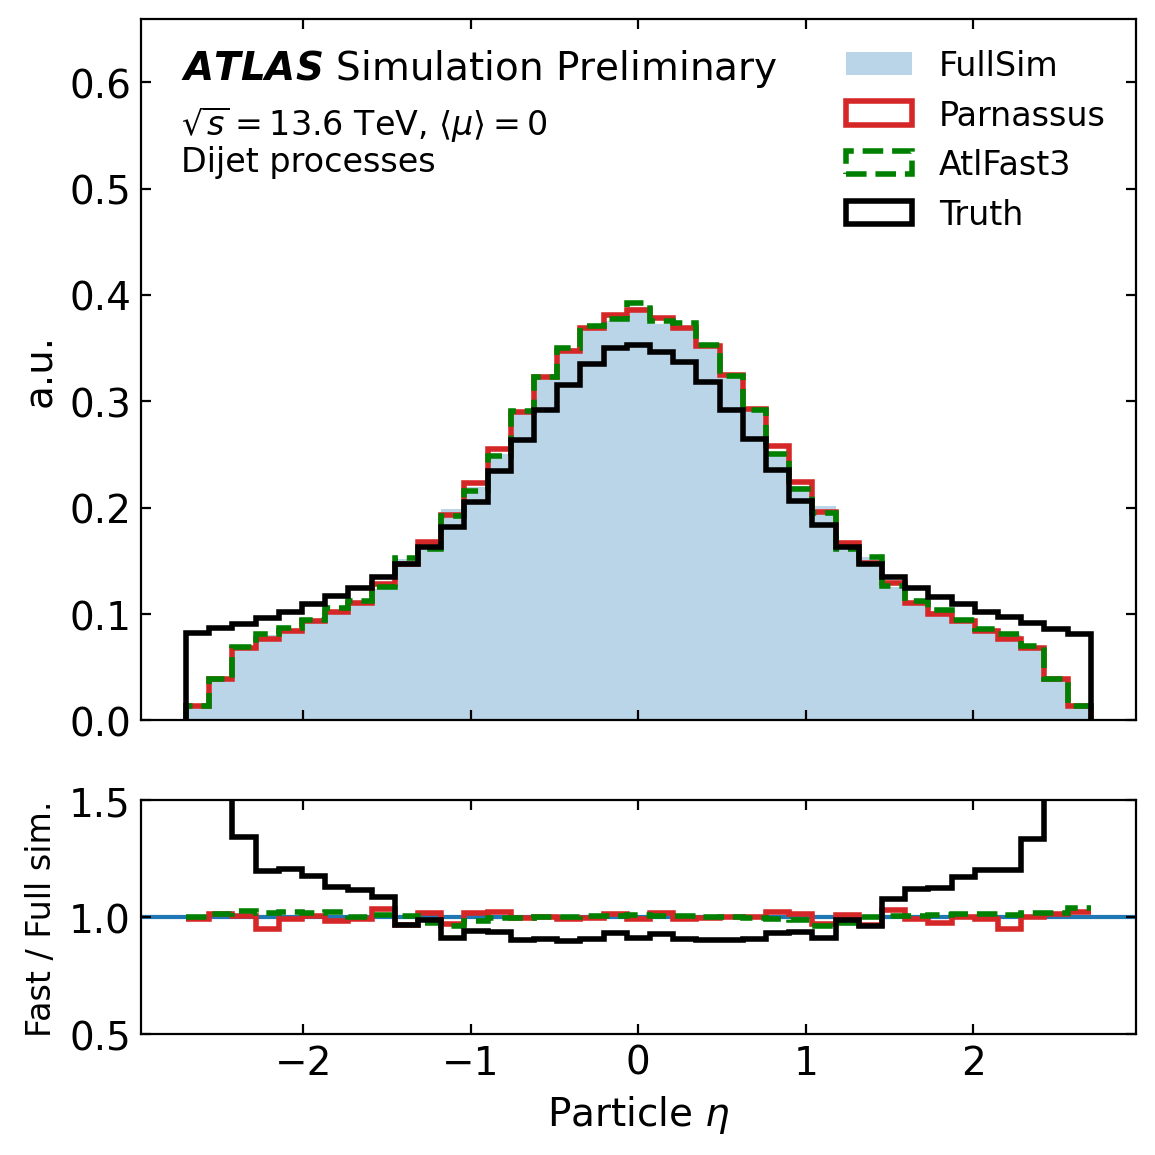

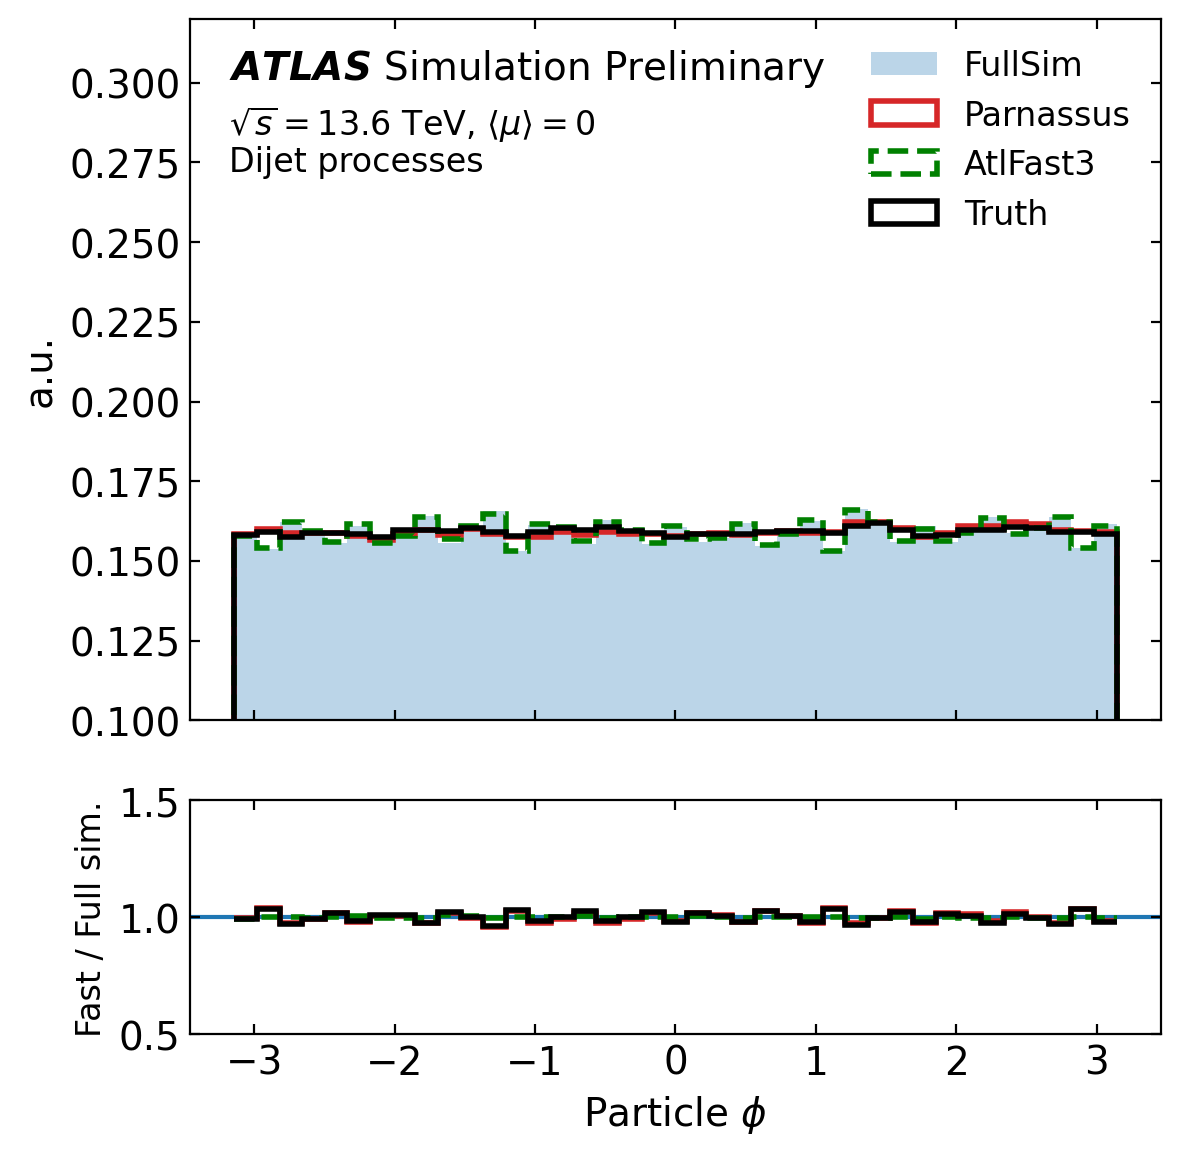

In [24]:
var_list    = ["pt", "eta", "phi"]
xlabel_list = [r"Particle $p_T$ [GeV]", r"Particle $\eta$", r"Particle $\phi$"]

for sample in samples_data.keys():
    for j, (var, xlabel) in enumerate(zip(var_list, xlabel_list)):
        yscale = "log" if var == "pt" else "linear"
        fig, ax_main, ax_ratio = _make_fig(xlabel, yscale=yscale, ratio_ylim=(0.5, 1.5))
        ref_counts = None

        for key in ['pf', *fms, 'tr']:
            if 'fm' in key:
                good_color = good_colors[xbins.index(int(key[2:]))]
            s = (
                settings_dict.get(key, settings_dict["fm"] | {"label": "Parnassus", "color": good_color})
                | {"linewidth": 2}
            )
            value = np.concatenate(samples_data[sample]["all"][key][var])
            counts, _, _ = _hist_overflow(ax_main,
                value, bins=bins_1d[var][sample], **s,
                density=True,
                histtype="stepfilled" if key == "pf" else "step",
            )
            if key == "pf":
                ref_counts = counts
            else:
                _add_ratio_line(ax_ratio, counts, bins_1d[var][sample], ref_counts, s)
            if var == "eta":
                print(f"{key} {var} range: {value.min()} to {value.max()}")

        if var == "phi":
            ax_main.set_ylim(0.1, 0.2)

        _finalize_fig(fig, ax_main, ax_ratio)
        plt.show()

        fig.savefig(os.path.join(plot_dir, 'particle_marginals', f"{sample}_particle_marginal_{var}.png"))
        fig.savefig(os.path.join(plot_dir, 'particle_marginals', f"{sample}_particle_marginal_{var}.pdf"))


# Event-level residual distributions

In [25]:
res_card_bins_dict = {
    "JZall": np.arange(-260, 10, 10) + 0.5,
    "WprimeWZ": np.arange(-200, 0, 5) + 0.5,
}
res_n_jets_bins = np.arange(-5, 3, 1) + 0.5
res_met_bins_dict = {
    "JZall": np.linspace(-100, 100, 20),
    "WprimeWZ": np.linspace(-100, 100, 20),
}
res_met_tot_bins_dict = {
    "JZall": np.linspace(0, 400, 20),
    "WprimeWZ": np.linspace(0, 400, 20),
}
res_ht_bins_dict = {
    "JZall": np.linspace(-1.0, 0.5, 50),
    "WprimeWZ": np.linspace(-0.5, 0.5, 40),
}

In [26]:
res_bins_dict = {
    "n_part_res": res_card_bins_dict,
    "n_jets_res": res_n_jets_bins,
    "met_x_res": res_met_bins_dict,
    "met_y_res": res_met_bins_dict,
    "met_tot_res": res_met_tot_bins_dict,
    "ht_res": res_ht_bins_dict,
    "ht_res_cut": res_ht_bins_dict,
}

/tmp/ipykernel_716186/2747882653.py:76: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_main.set_yticklabels([f"{tick * 100:.2f}" for tick in ticks])


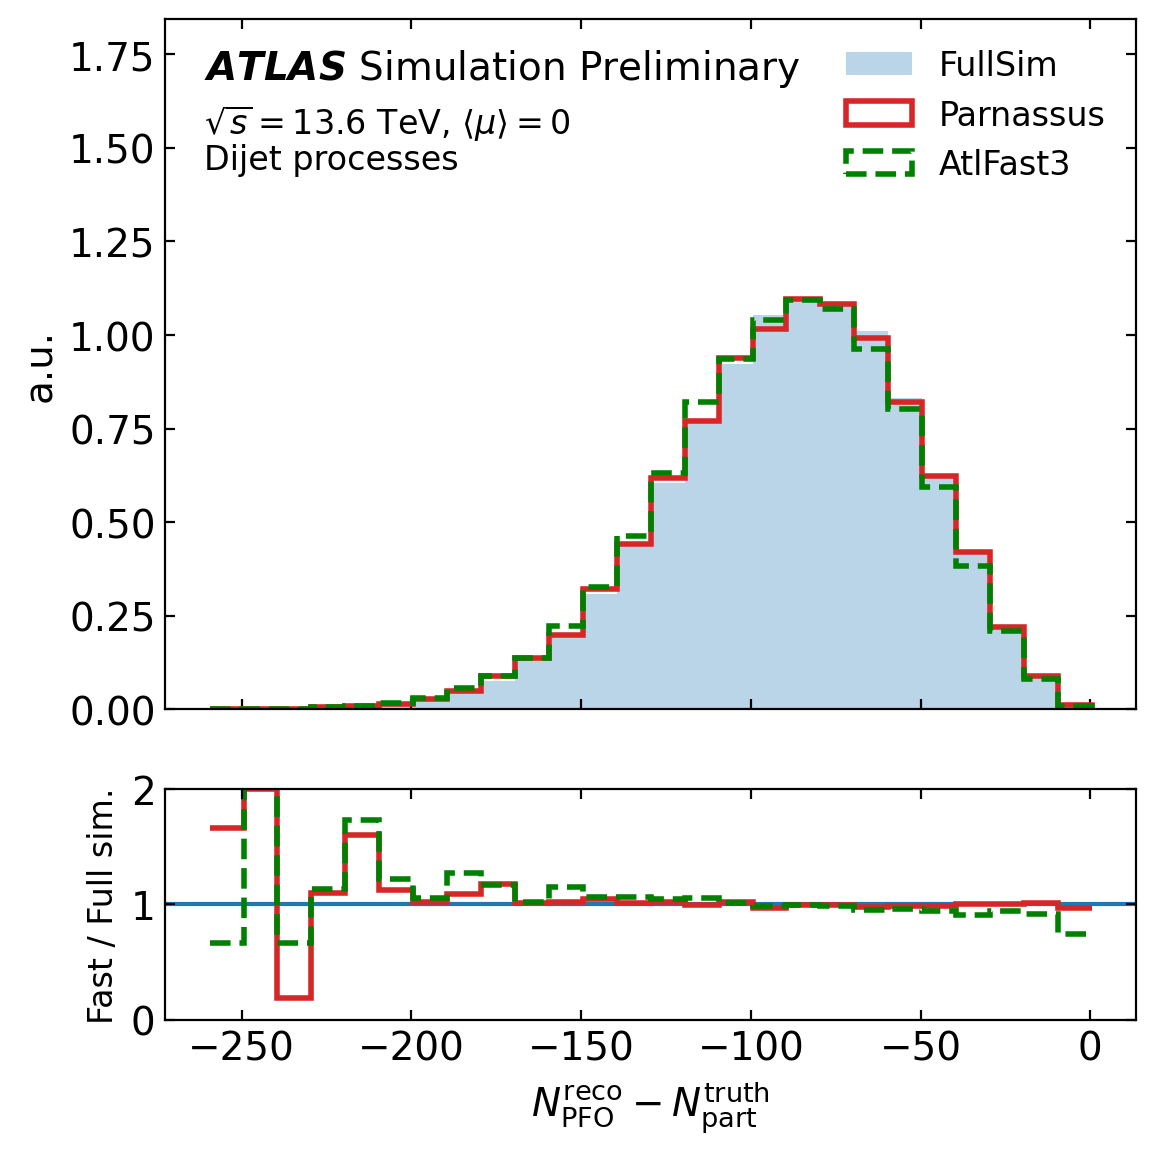

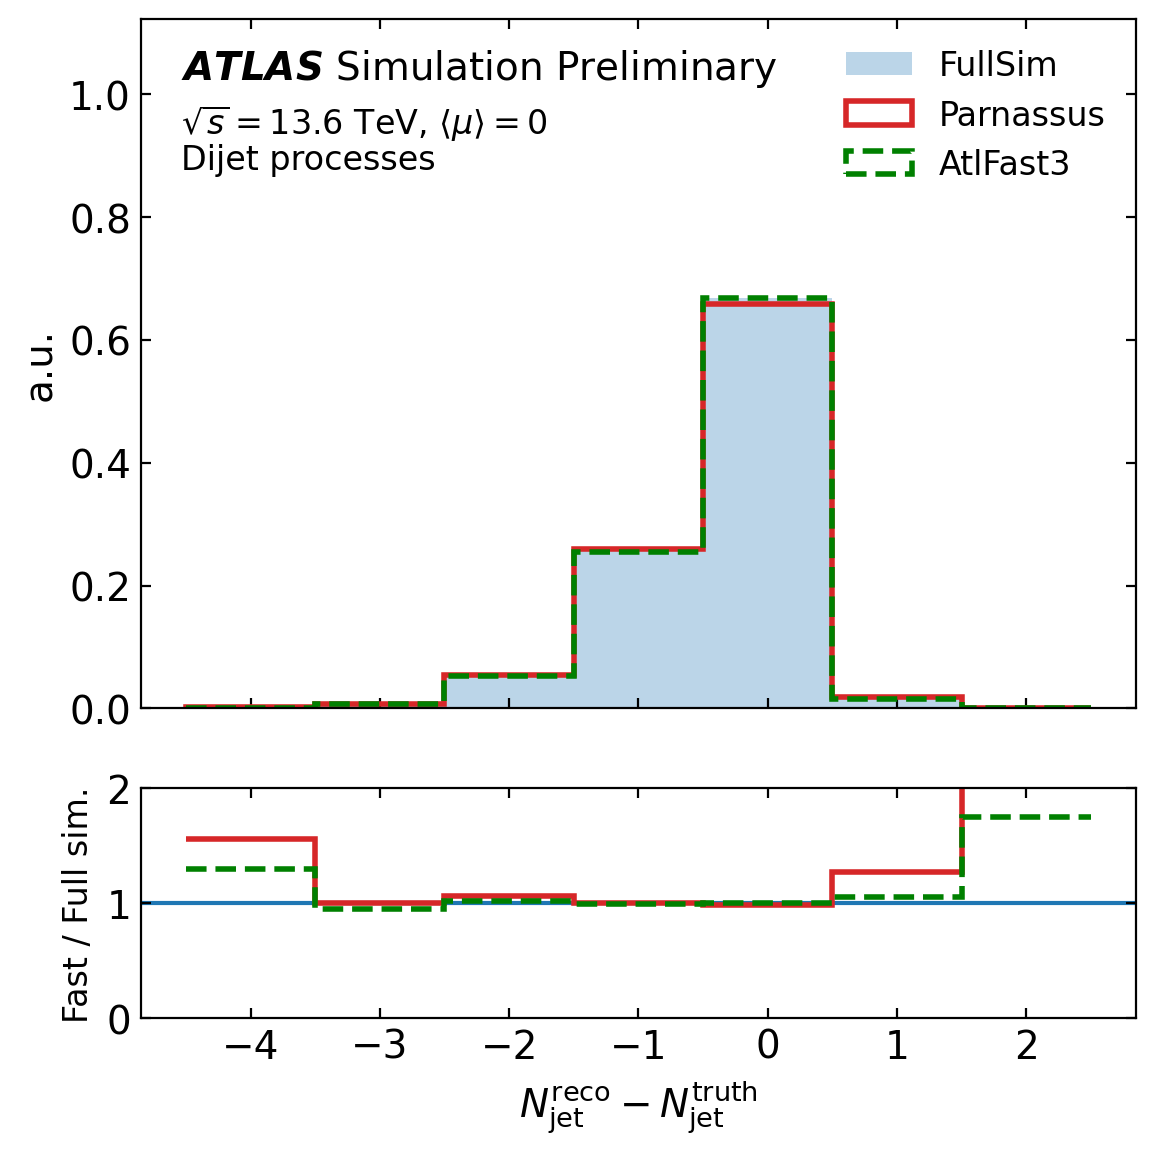

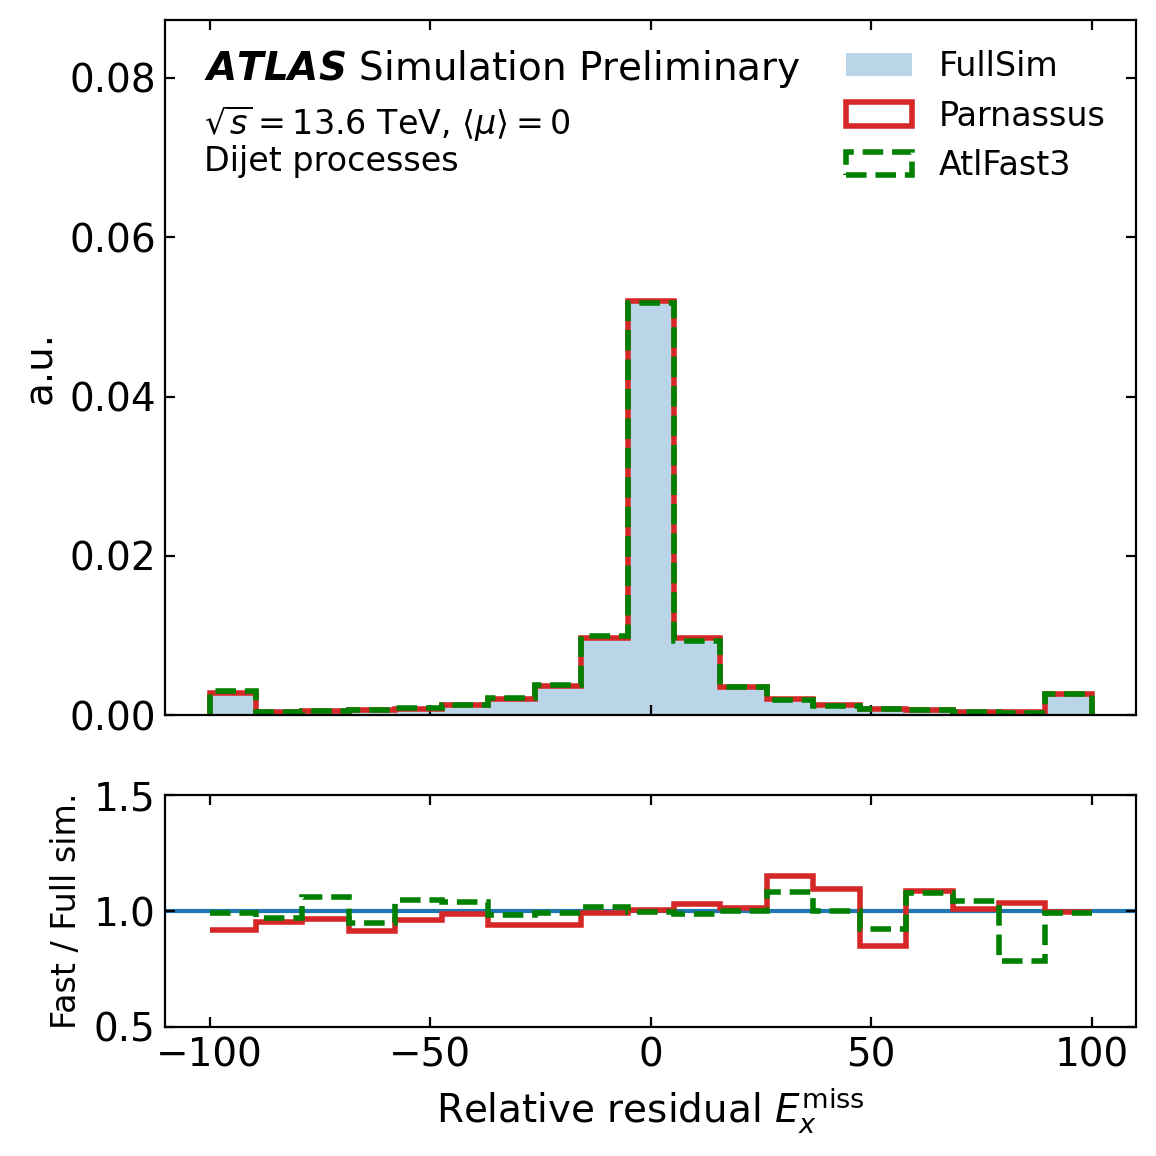

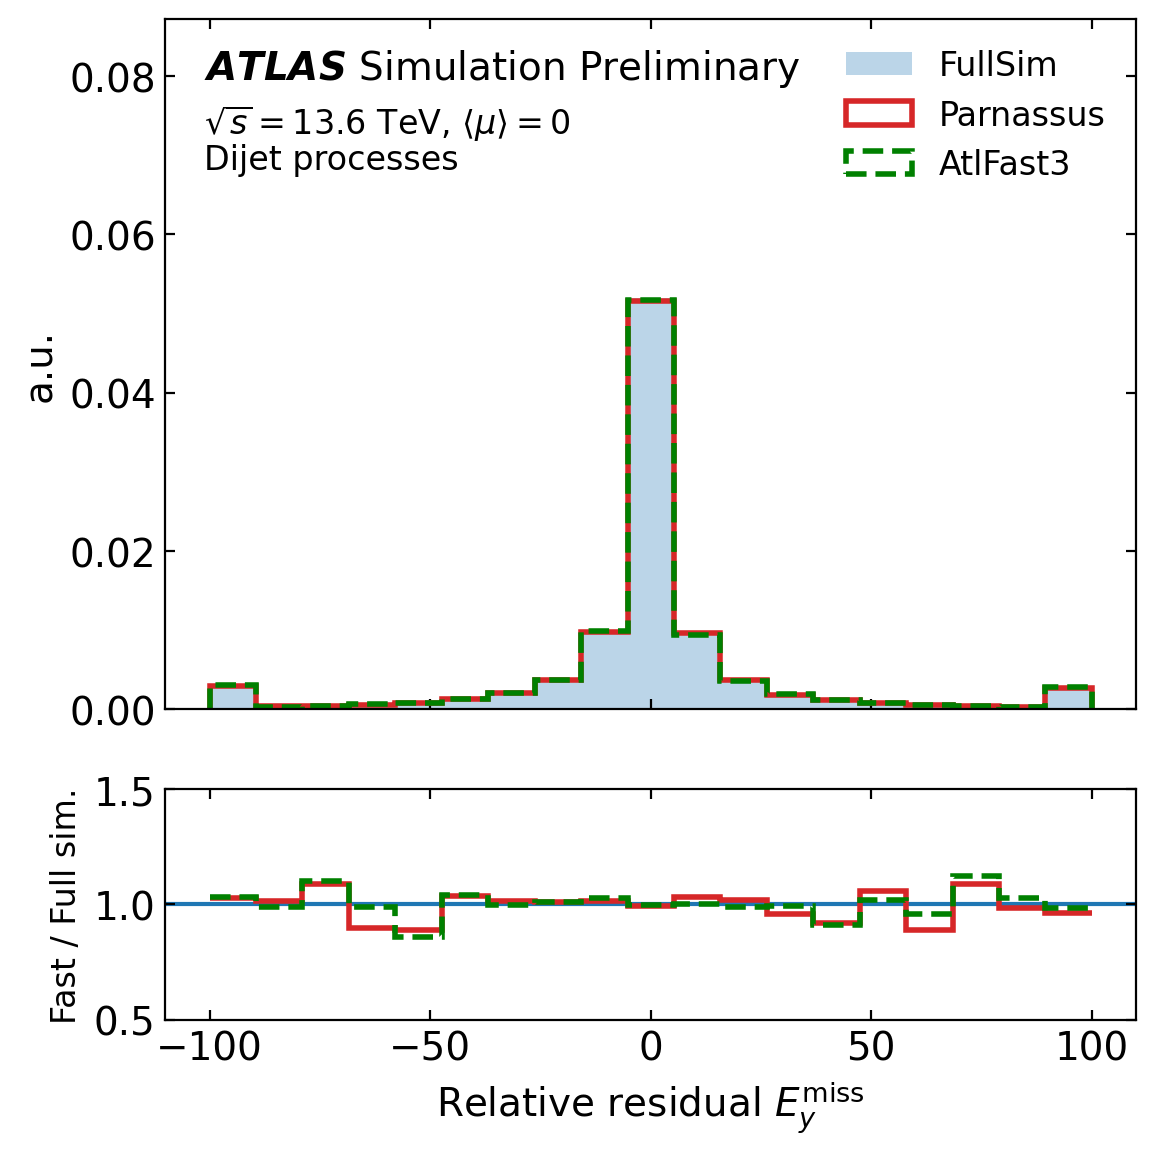

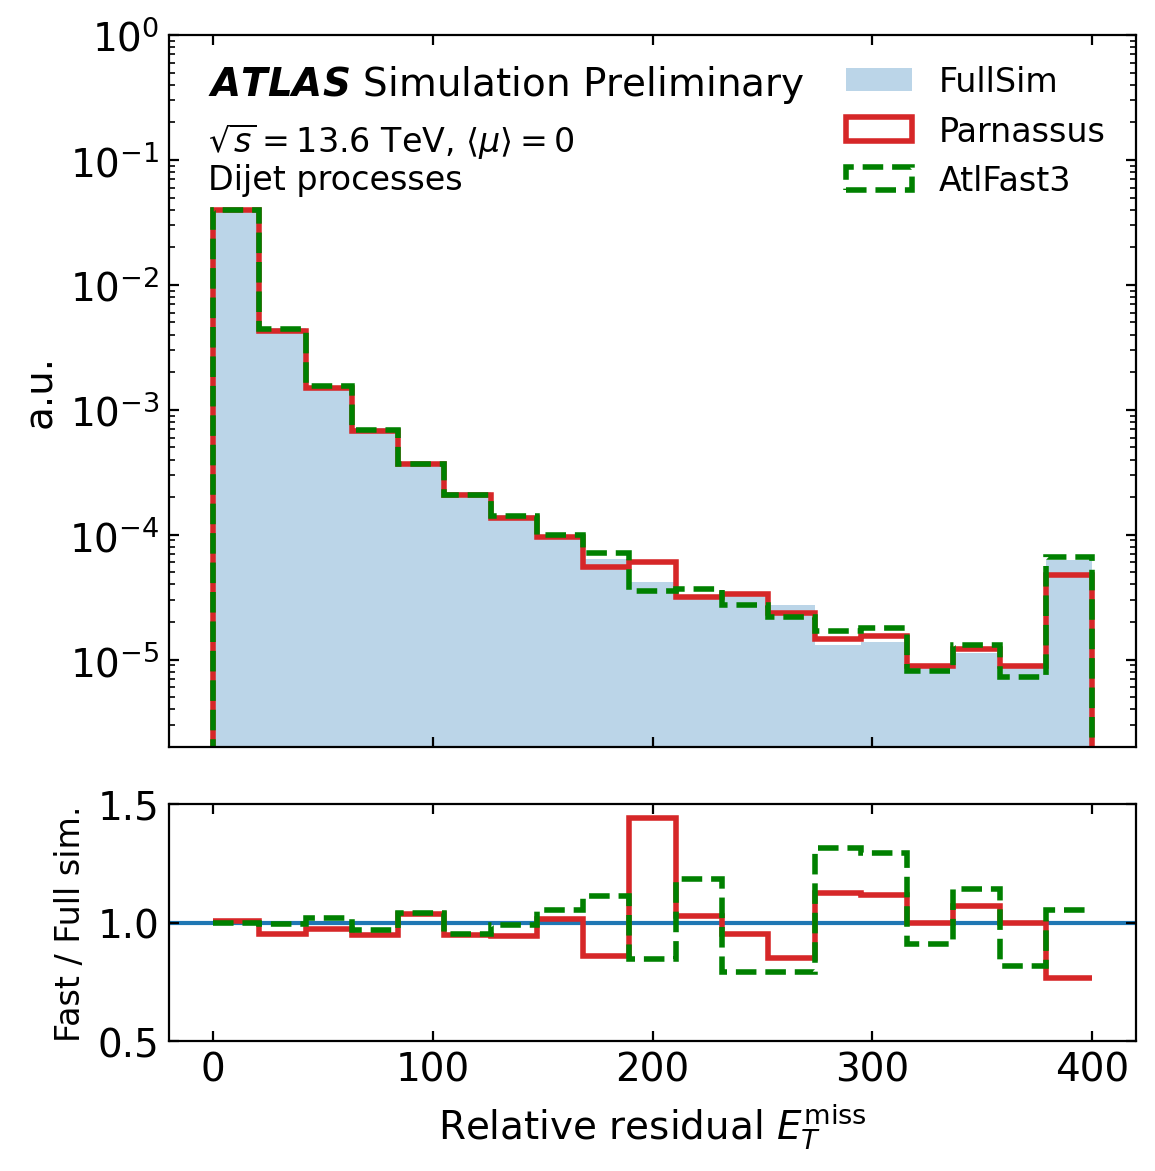

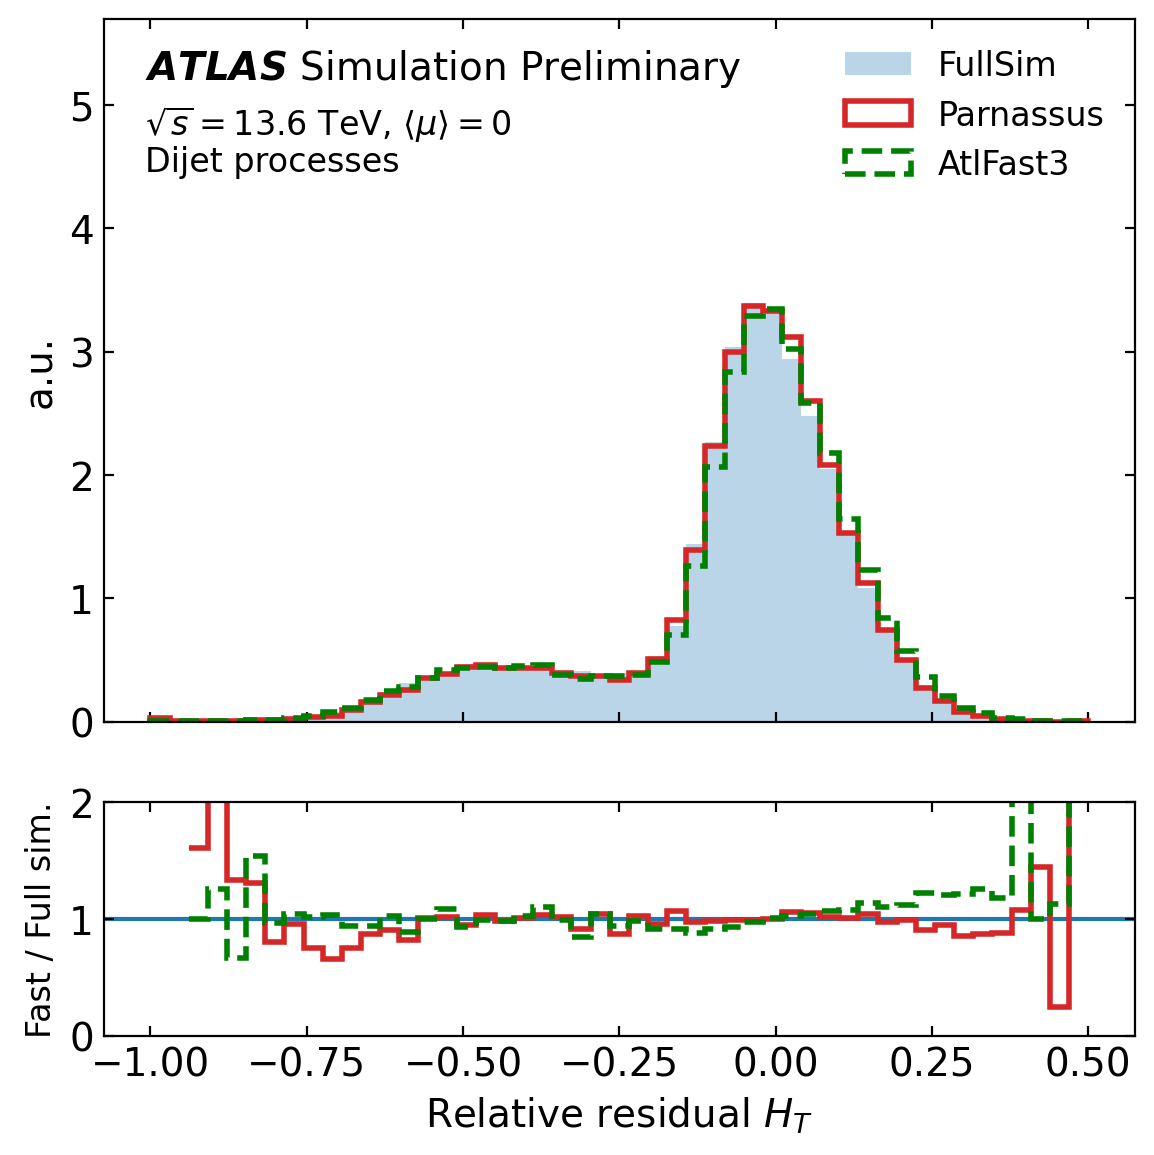

Applying HT > 250 GeV cut: 49600 events pass the cut out of 58522 total events
Applying HT > 250 GeV cut: 49600 events pass the cut out of 58522 total events
Applying HT > 250 GeV cut: 49600 events pass the cut out of 58522 total events


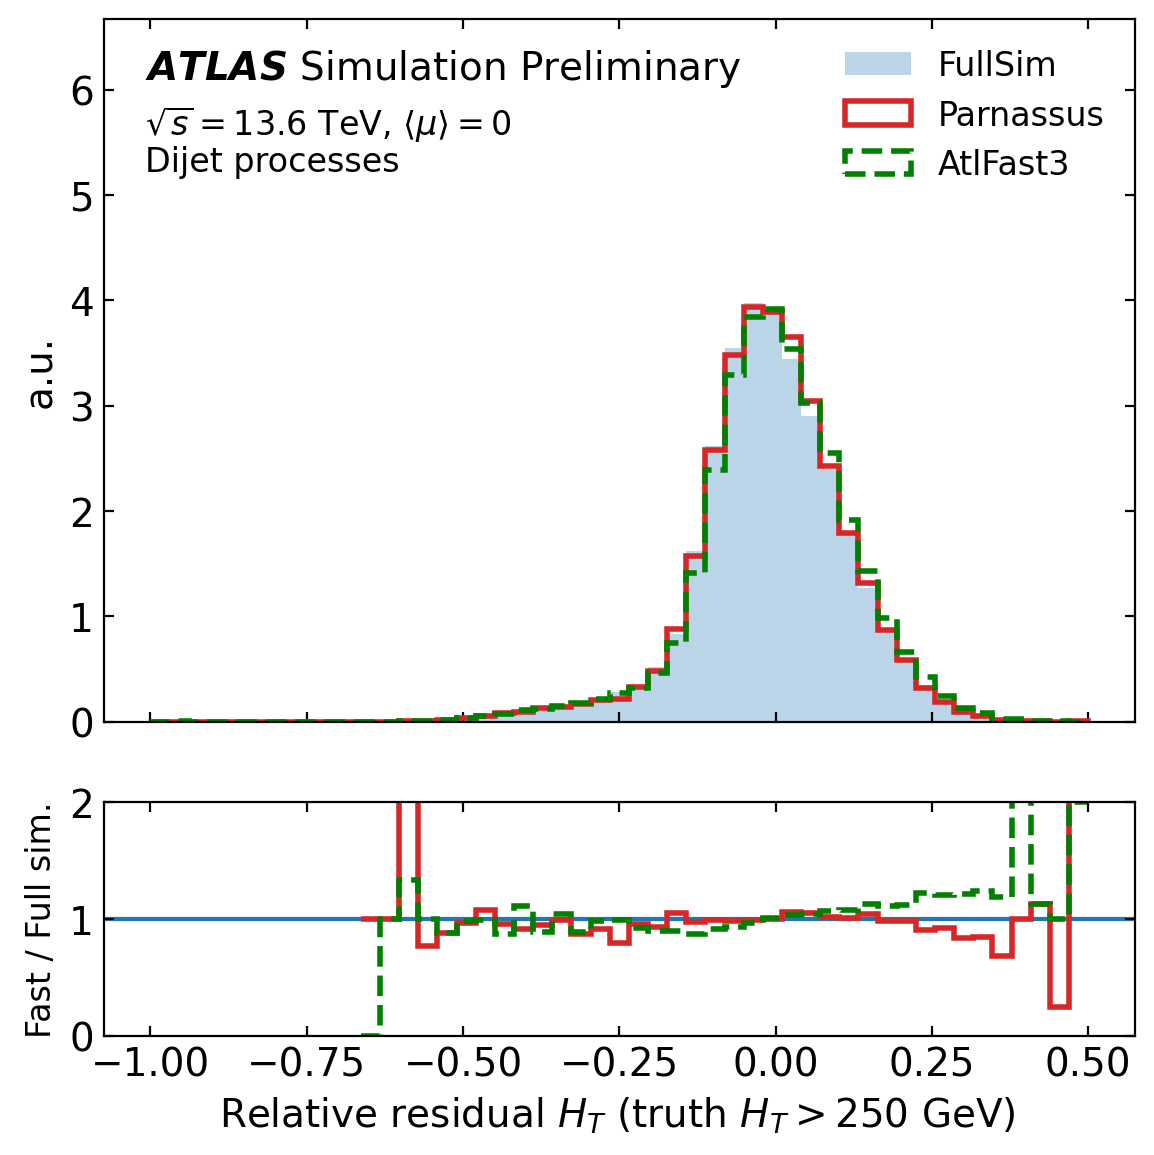

In [27]:

evt_res_var_list = ["n_part_res", "n_jets_res", "met_x_res", "met_y_res", "met_tot_res", "ht_res", "ht_res_cut"]
evt_res_xlabel_list = [
    r"$N_{\mathrm{PFO}}^{\mathrm{reco}} - N_{\mathrm{part}}^{\mathrm{truth}}$",
    r"$N_{\mathrm{jet}}^{\mathrm{reco}} - N_{\mathrm{jet}}^{\mathrm{truth}}$",
    r"Relative residual $E_{x}^{\mathrm{miss}}$",
    r"Relative residual $E_{y}^{\mathrm{miss}}$",
    r"Relative residual $E_{T}^{\mathrm{miss}}$",
    r"Relative residual $H_T$",
    r"Relative residual $H_T$ (truth $H_T > 250$ GeV) ",
]
# evt_res_xlabel_list = [
#     r"$N_{\mathrm{part}}^{\mathrm{reco}} - N_{\mathrm{part}}^{\mathrm{truth}}$",
#     r"$N_{\mathrm{jet}}^{\mathrm{reco}} - N_{\mathrm{jet}}^{\mathrm{truth}}$",
#     r"(reco $E_{x}^{\mathrm{miss}} - truth E_{x}^{\mathrm{miss}})$ / truth $E_{x}^{\mathrm{miss}}$",
#     r"(reco $E_{y}^{\mathrm{miss}} - truth E_{y}^{\mathrm{miss}})$ / truth $E_{y}^{\mathrm{miss}}$",
#     r"(reco $E_{T}^{\mathrm{miss}} - truth E_{T}^{\mathrm{miss}})$ / truth $E_{T}^{\mathrm{miss}}$",
#     r"$H_T^{\mathrm{reco}} - H_T^{\mathrm{truth}} / H_T^{\mathrm{truth}}$",
#     r"$H_T^{\mathrm{reco}} - H_T^{\mathrm{truth}} / H_T^{\mathrm{truth}}$ ($H_T^{\mathrm{truth}} > 250$ GeV)",
# ]

def compute_met_tot_residual(met_x, met_y, met_x_truth, met_y_truth):
    numerator = np.sqrt((met_x - met_x_truth)**2 + (met_y - met_y_truth)**2)
    denominator = np.sqrt(met_x_truth**2 + met_y_truth**2)
    with np.errstate(divide='ignore', invalid='ignore'):
        met_tot_res = np.where(denominator > 0, numerator / denominator, np.nan)
    return met_tot_res

for sample in samples_data.keys():
    value_truth = samples_data[sample]["all"]["tr"]
    for key in ['pf', *fms]:
        value = samples_data[sample]["all"][key]
        value['n_part_res'] = value[card_varnames[key]] - value_truth[card_varnames['tr']]
        value["n_jets_res"] = value["n_jets"] - value_truth["n_jets"]
        value["met_x_res"] = (value["met_x"] - value_truth["met_x"]) / np.abs(value_truth["met_x"])
        value["met_y_res"] = (value["met_y"] - value_truth["met_y"]) / np.abs(value_truth["met_y"])
        value["met_tot_res"] = compute_met_tot_residual(value["met_x"], value["met_y"], value_truth["met_x"], value_truth["met_y"])
        value["ht_res"]    = (value["ht"]    - value_truth["ht"])    / value_truth["ht"]
        value["ht_res_cut"] = (value["ht"]    - value_truth["ht"])    / value_truth["ht"]
    for var, xlabel in zip(evt_res_var_list, evt_res_xlabel_list):
        bins = res_bins_dict[var]
        if isinstance(bins, dict):
            bins = bins[sample]
        fig, ax_main, ax_ratio = _make_fig(xlabel, 
                                           yscale="log" if var in ["met_tot_res"] else "linear",
                                           ratio_ylim=(0.5, 1.5) if var[:3] == "met" else (0.0, 2.0))
        ref_counts = None

        for key in ['pf', *fms]:
            if 'fm' in key:
                good_color = good_colors[xbins.index(int(key[2:]))]
            value = samples_data[sample]["all"][key]
            mask = np.ones(len(value[var]), dtype=bool)
            if var == "ht_res_cut":
                ### HT cut
                min_ht = 250
                mask = np.abs(samples_data[sample]["all"]["tr"]["ht"]) > min_ht
                print(f"Applying HT > {min_ht} GeV cut: {np.sum(mask)} events pass the cut out of {len(mask)} total events")

            s = settings_dict.get(key, settings_dict["fm"] | {"label": "Parnassus", "color": good_color})
            counts, _, _ = _hist_overflow(ax_main,
                value[var][mask], bins=bins, **s,
                density=True,
                histtype="stepfilled" if key == "pf" else "step",
            )
            if key == "pf":
                ref_counts = counts
            else:
                _add_ratio_line(ax_ratio, counts, bins, ref_counts, s)

        _finalize_fig(fig, ax_main, ax_ratio)

        ### Patch #1
        if var == "n_part_res":
            ### Multiply y-axis labels by 100 to avoid leading zeros
            ticks = ax_main.get_yticks()
            ax_main.set_yticklabels([f"{tick * 100:.2f}" for tick in ticks])
            fig.tight_layout()

        ### Patch #2
        if var == "met_tot_res":
            ax_main.set_ylim(2e-6, 1)

        plt.show()

        fig.savefig(os.path.join(plot_dir, 'event_residuals', f"{sample}_event_residual_{var}.png"))
        fig.savefig(os.path.join(plot_dir, 'event_residuals', f"{sample}_event_residual_{var}.pdf"))


### Investigate $H_T\sim -0.5$ peak

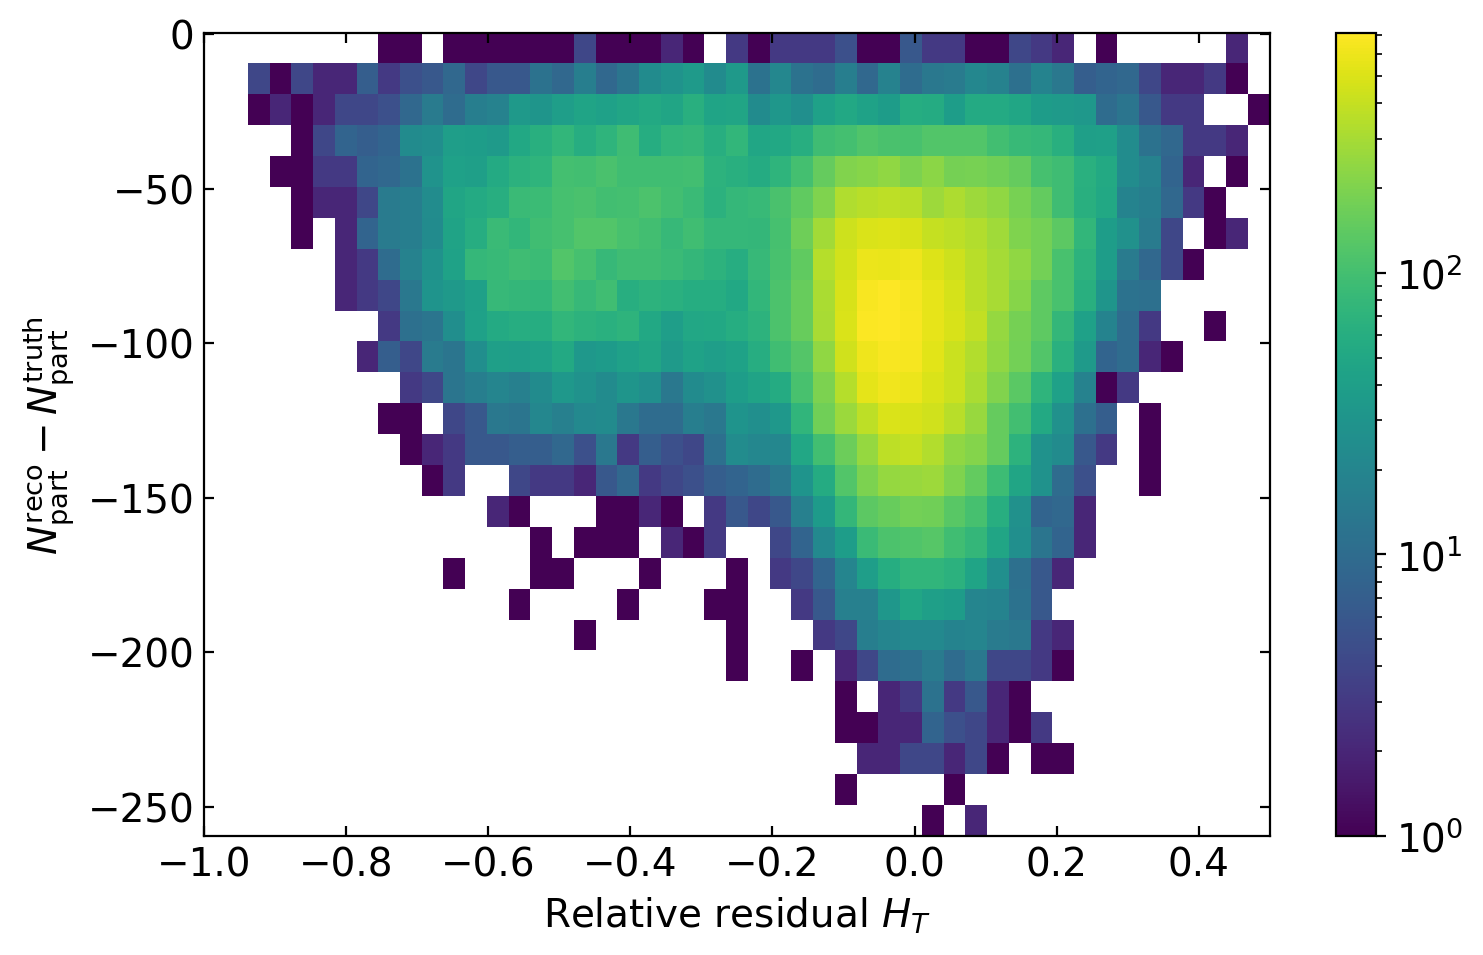

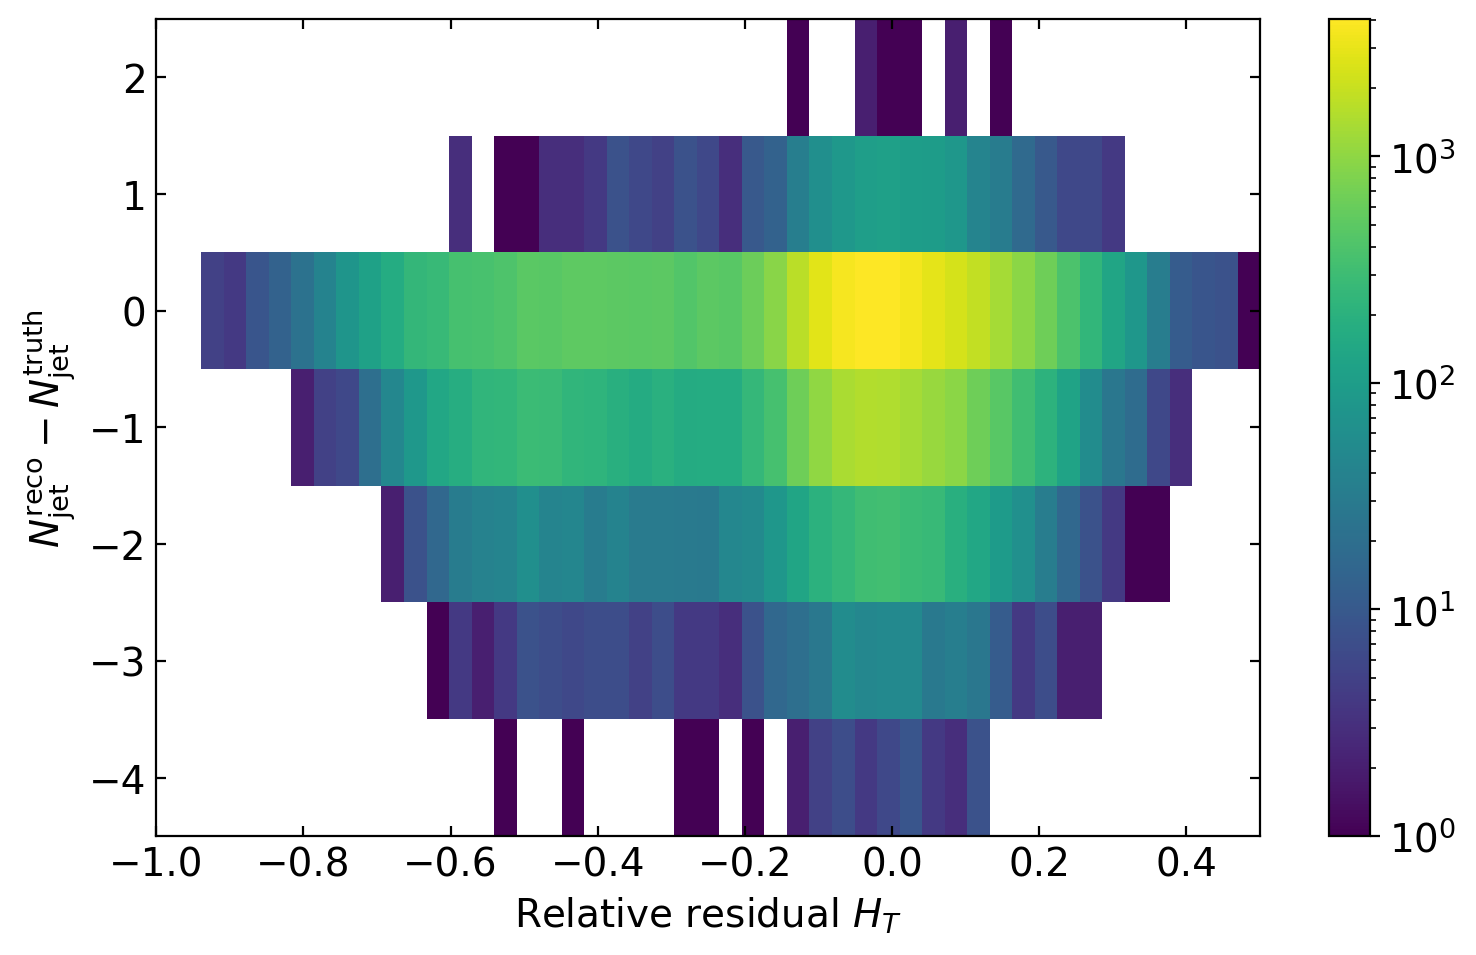

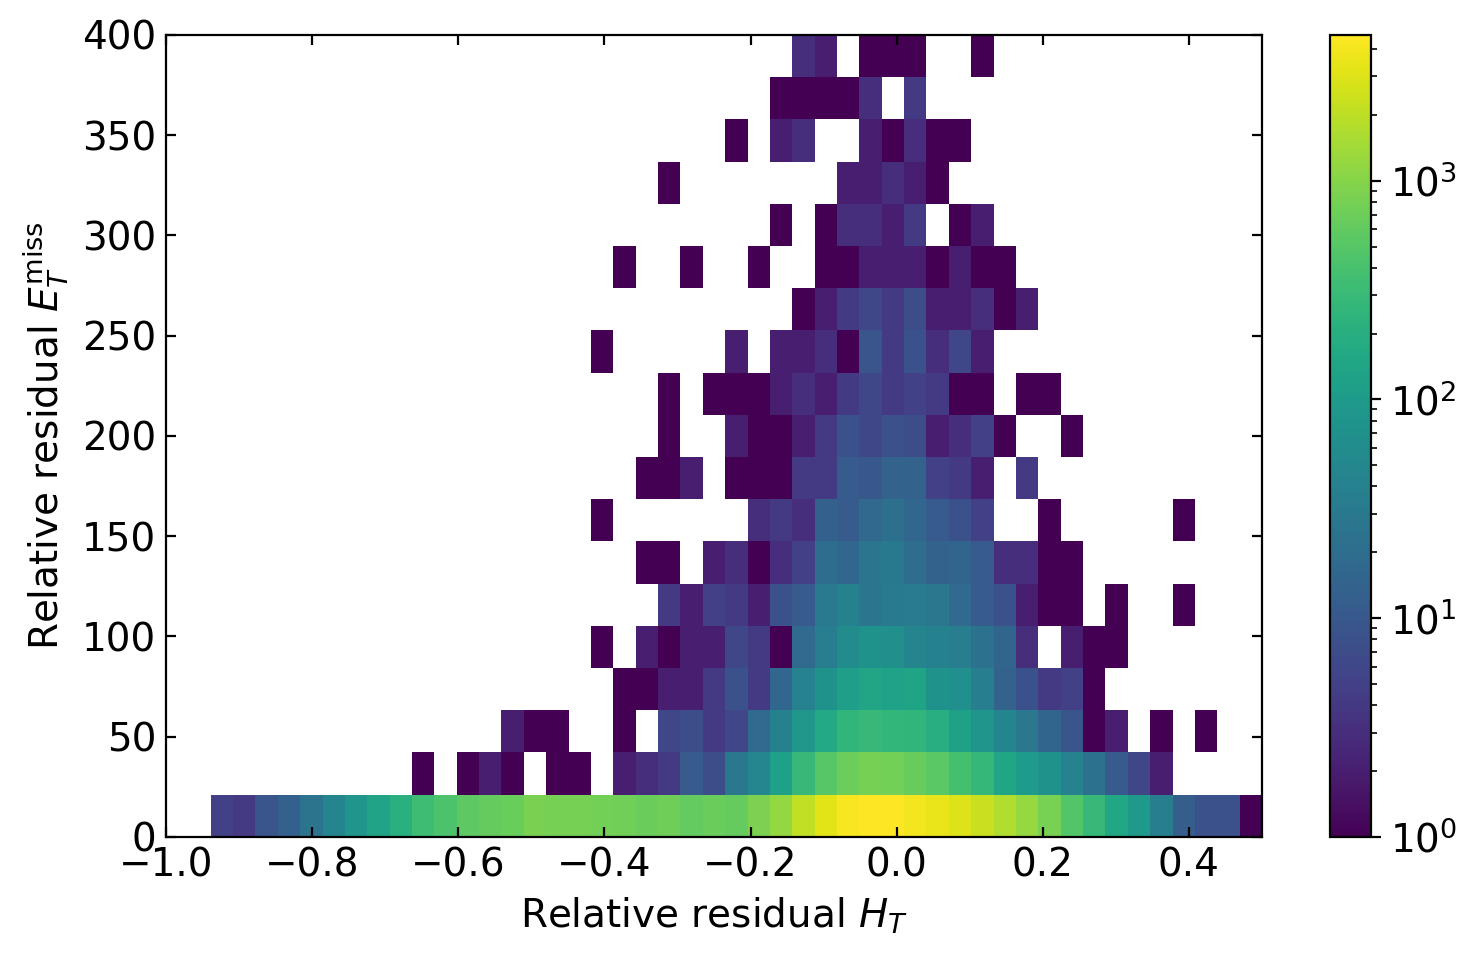

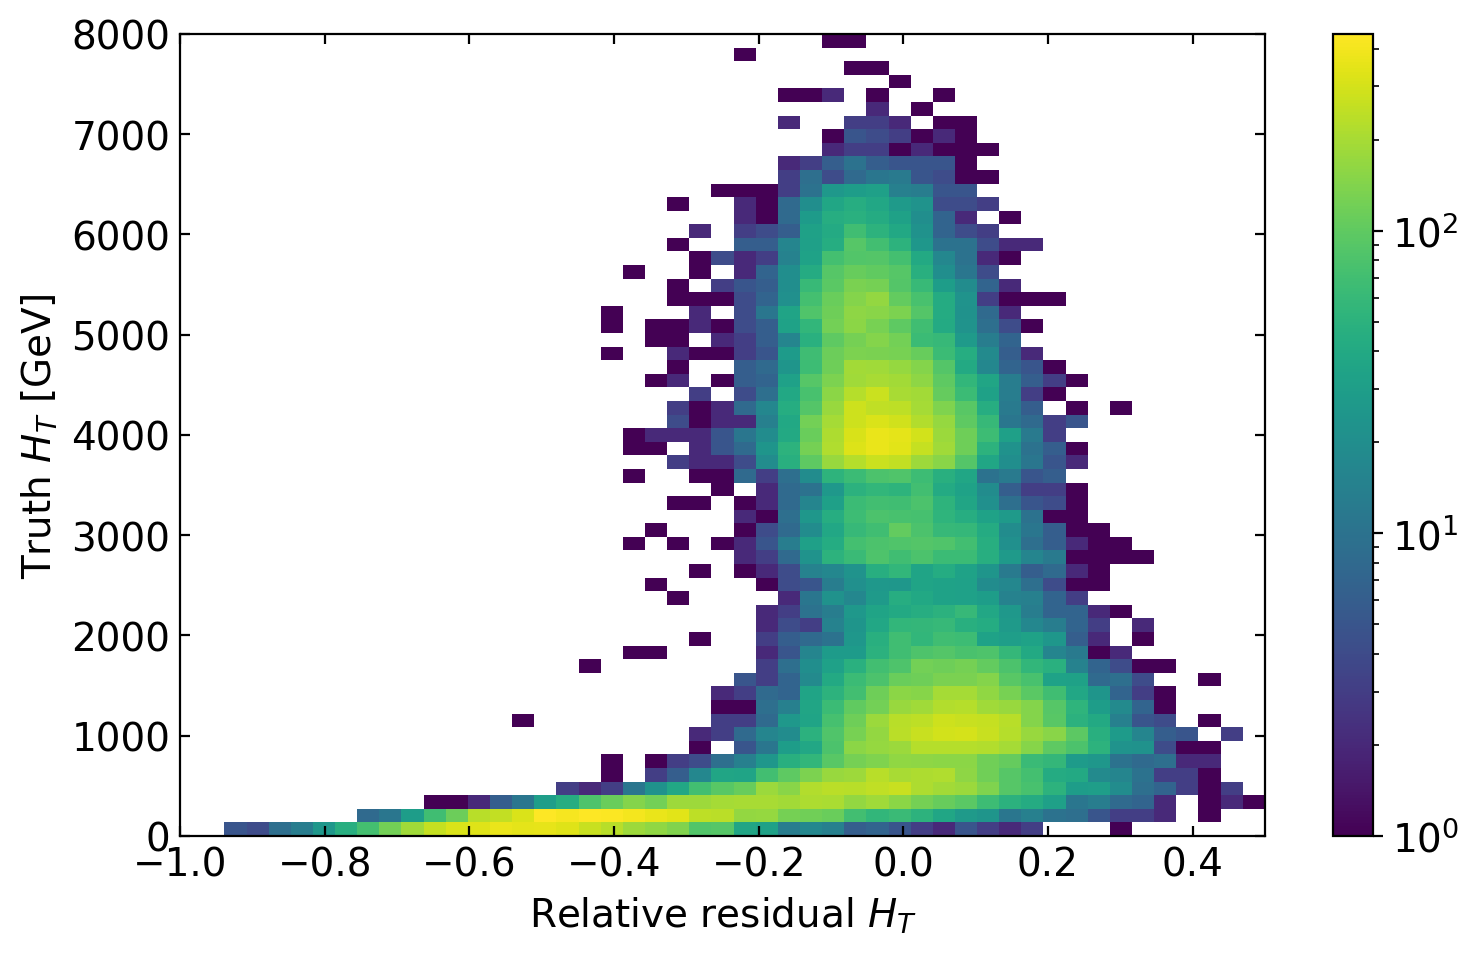

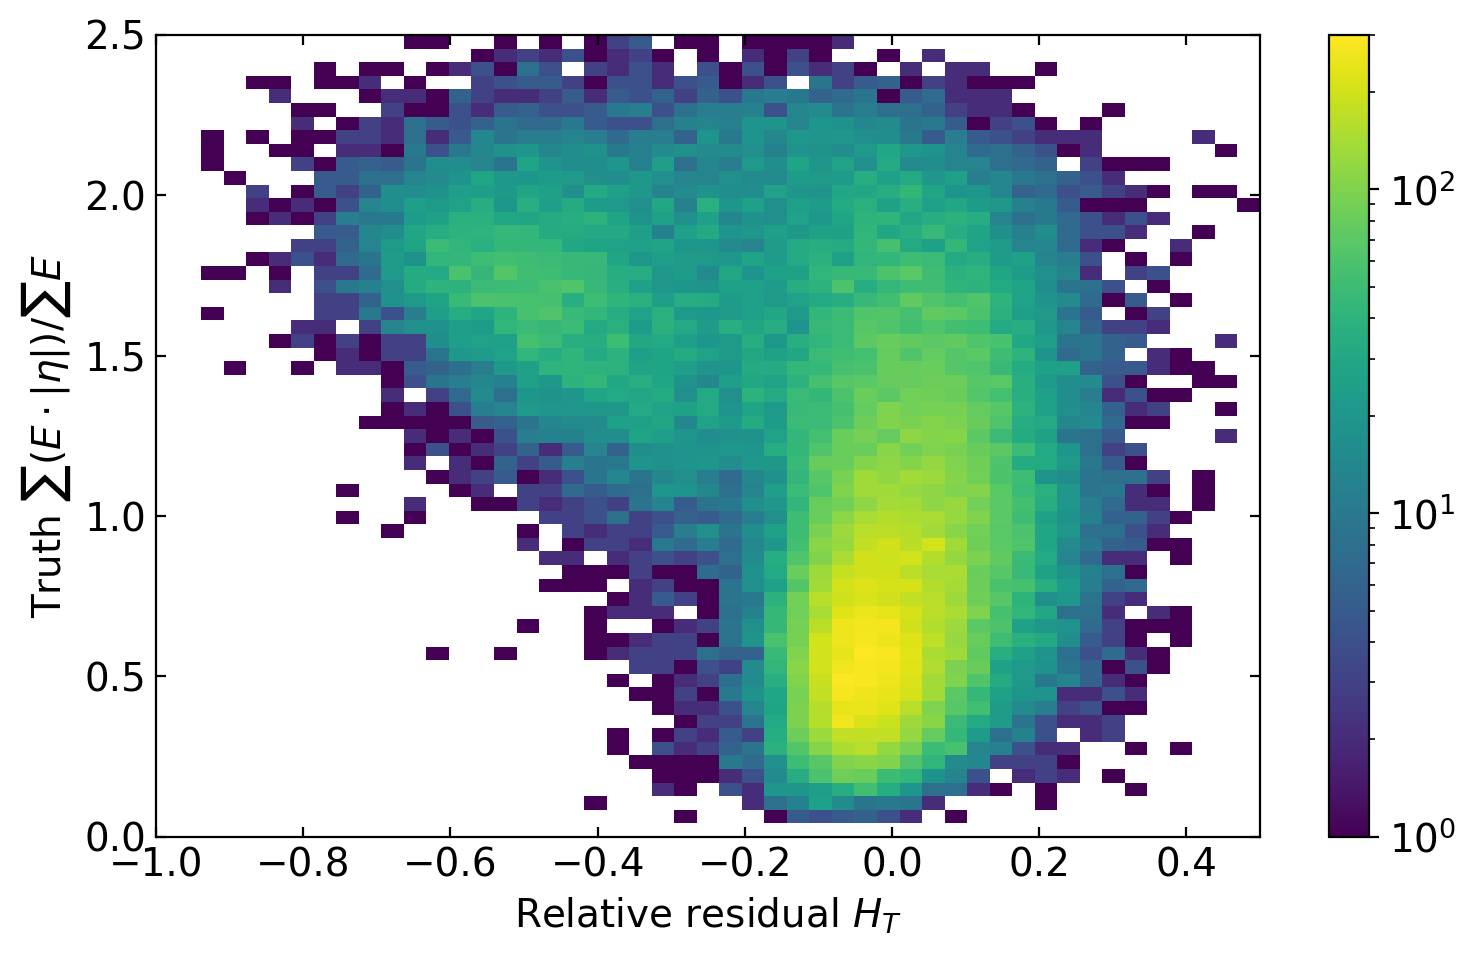

In [28]:
### Plot 2D histogram number of jets residual on y axis vs HT residual on x axis
from matplotlib.colors import LogNorm

var_y_dict_2D = {"n_part_res": "pf", 
                 "n_jets_res": "pf", 
                 "met_tot_res": "pf",
                 "ht": "tr",
                 "forwardness": "tr",
                }

var_y_label_list_2D = [
    r"$N_{\mathrm{part}}^{\mathrm{reco}} - N_{\mathrm{part}}^{\mathrm{truth}}$",
    r"$N_{\mathrm{jet}}^{\mathrm{reco}} - N_{\mathrm{jet}}^{\mathrm{truth}}$",
    r"Relative residual $E_{T}^{\mathrm{miss}}$",
    r"Truth $H_T$ [GeV]",
    r"Truth $\sum (E \cdot |\eta|) / \sum E$",
]

def compute_forwardness(particle_pt, particle_eta):

    forwardness = []
    for pt, eta in zip(particle_pt, particle_eta):
        ### energy-weighted sum over particle |eta|, normalized to total energy
        E = pt * np.cosh(eta)
        forwardness_ev = np.sum(E * np.abs(eta)) / np.sum(E)
        forwardness.append(forwardness_ev)
    return np.array(forwardness)

truth_ht_cut = False

for var_y, lab_y in zip(var_y_dict_2D.keys(), var_y_label_list_2D):

    for sample in samples_data.keys():
        var_x = "ht_res"
        xlabel = r"Relative residual $H_T$"
        ylabel = lab_y
        fig, ax = plt.subplots(figsize=(8, 5), dpi=200)
        _xbins = res_bins_dict[var_x][sample] if isinstance(res_bins_dict[var_x], dict) else res_bins_dict[var_x]
        if var_y == "ht":
            _ybins = np.linspace(0, 8000, 60)
        elif var_y == "forwardness":
            _ybins = np.linspace(0, 2.5, 60)
        else:
            _ybins = res_bins_dict[var_y][sample] if isinstance(res_bins_dict[var_y], dict) else res_bins_dict[var_y]
        if var_y == "met_tot_res":
            data_y = compute_met_tot_residual(
                samples_data[sample]["all"]["pf"]["met_x"],
                samples_data[sample]["all"]["pf"]["met_y"],
                samples_data[sample]["all"]["tr"]["met_x"],
                samples_data[sample]["all"]["tr"]["met_y"],
            )
        elif var_y == "forwardness":
            data_y = compute_forwardness(
                samples_data[sample]["all"]["tr"]["pt"],
                samples_data[sample]["all"]["tr"]["eta"],
            )
        else:
            data_x = samples_data[sample]["all"]["pf"][var_x]
            y_src = var_y_dict_2D[var_y]
            data_y = samples_data[sample]["all"][y_src][var_y]

        if truth_ht_cut:
            min_ht = 250
            ht_truth = samples_data[sample]["all"]["tr"]["ht"]
            mask = np.abs(ht_truth) < min_ht
            print(f"Applying HT < {min_ht} GeV cut: {np.sum(mask)} events pass the cut out of {len(mask)} total events")
            data_x = data_x[mask]
            data_y = data_y[mask]

        h = ax.hist2d(
            data_x, data_y,
            bins=[_xbins, _ybins],
            norm=LogNorm(),
            cmap="viridis",
        )
        fig.colorbar(h[3], ax=ax)
        ax.set_xlabel(xlabel, fontsize=fs)
        ax.set_ylabel(ylabel, fontsize=fs)
        ax.tick_params(
            axis='y', which='both',
            left=True, right=True, labelleft=True, labelright=False, direction='in',
        )
        ax.tick_params(axis='x', which='both', bottom=True, top=True, direction='in')
        # ax.yaxis.set_label_position("right")
        fig.tight_layout()
        plt.show()
        fig.savefig(os.path.join(plot_dir, 'event_residuals', f"{sample}_event_residual_2d_{var_y}_vs_{var_x}.png"))
        fig.savefig(os.path.join(plot_dir, 'event_residuals', f"{sample}_event_residual_2d_{var_y}_vs_{var_x}.pdf"))

# Jet-level residual distributions

In [29]:
jet_matching_dicts = {key: {} for key in samples_data.keys()}

In [30]:
for sample in samples_data.keys():
    for key in samples_data[sample]["jet"].keys():
        if key == 'tr':
            continue
        jet_matching_dicts[sample][key] = matching(
            jet_dicts[sample][key], jet_dicts[sample]["tr"], dr_match=True, dr_cut=0.2
        )

matching: 100%|██████████| 58522/58522 [00:06<00:00, 9433.23it/s] 


Matching done!


matching: 100%|██████████| 58522/58522 [00:06<00:00, 9480.62it/s] 


Matching done!


matching: 100%|██████████| 58522/58522 [00:06<00:00, 9482.53it/s] 

Matching done!


In [31]:
jet_res_dicts = {key: {} for key in samples_data.keys()}
for sample in samples_data.keys():
    for key in samples_data[sample]["jet"].keys():
        if key == 'tr':
            continue
        jet_res_dicts[sample][key] = calc_jet_residuals(
            jet_matching_dicts[sample][key][0],
            jet_matching_dicts[sample][key][1],
            jet_dicts[sample][key],
            jet_dicts[sample]["tr"],
        )

residuals:  17%|█▋        | 9767/58522 [00:00<00:00, 97657.99it/s]

residuals: 100%|██████████| 58522/58522 [00:00<00:00, 115620.76it/s]


In [32]:
def get_leading_jet_res_dict(data, key):
    varlist = ["pt", "eta", "phi", "c2", "d2"]
    res = {var: [] for var in varlist}
    for var in varlist:
        for tr_, fs_ in zip(data["tr"][f"jets_{var}"], data[key][f"jets_{var}"]):
            if len(tr_) > 0 and len(fs_) > 0:
                if var == "d2":
                    res[var].append(np.log(fs_[0] + 1e-9) - np.log(tr_[0] + 1e-9))
                elif var == "phi":
                    tr_phi = reshape_phi(tr_)
                    fs_phi = reshape_phi(fs_)
                    res[var].append(fs_phi[0] - tr_phi[0])
                elif var == "pt":
                    res[var].append((tr_[0] - fs_[0]) / tr_[0])
                else:
                    res[var].append(tr_[0] - fs_[0])
        res[var] = np.array(res[var], dtype=np.float32)
    return res

In [33]:
leading_jet_res_dicts = {key: {} for key in samples_data.keys()}
for sample in samples_data.keys():
    for key in samples_data[sample]["jet"].keys():
        if key == 'tr':
            continue
        leading_jet_res_dicts[sample][key] = get_leading_jet_res_dict(
            samples_data[sample]["all"], key
        )

In [34]:
bins_jet_res = {
    "pt": defaultdict(constant_factory(np.linspace(-0.75, 0.75, 40))),
    "eta": defaultdict(constant_factory(np.linspace(-0.1, 0.1, 40))),
    "phi": defaultdict(constant_factory(np.linspace(-0.1, 0.1, 40))),
    "dR": defaultdict(constant_factory(np.linspace(0, 0.2, 40))),
    "d2": defaultdict(constant_factory(np.linspace(-2.5, 1.5, 40))),
    "c2": defaultdict(constant_factory(np.linspace(-0.2, 0.2, 40))),
}
if 'WprimeWZ' in samples_data:
    bins_jet_res["d2"] = defaultdict(constant_factory(np.linspace(-2.0, 4.0, 40)))

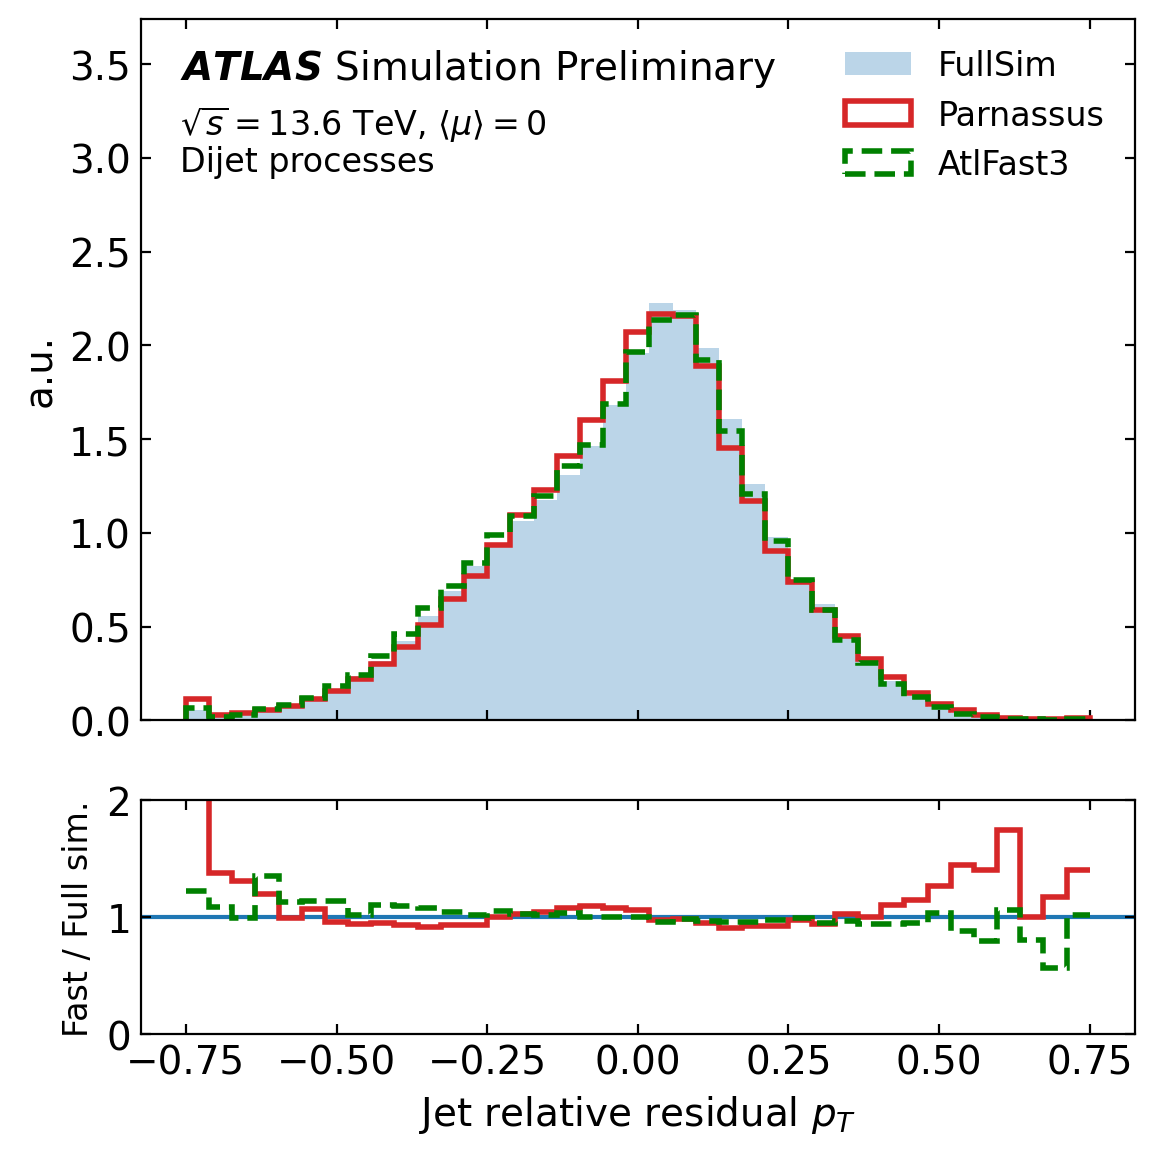

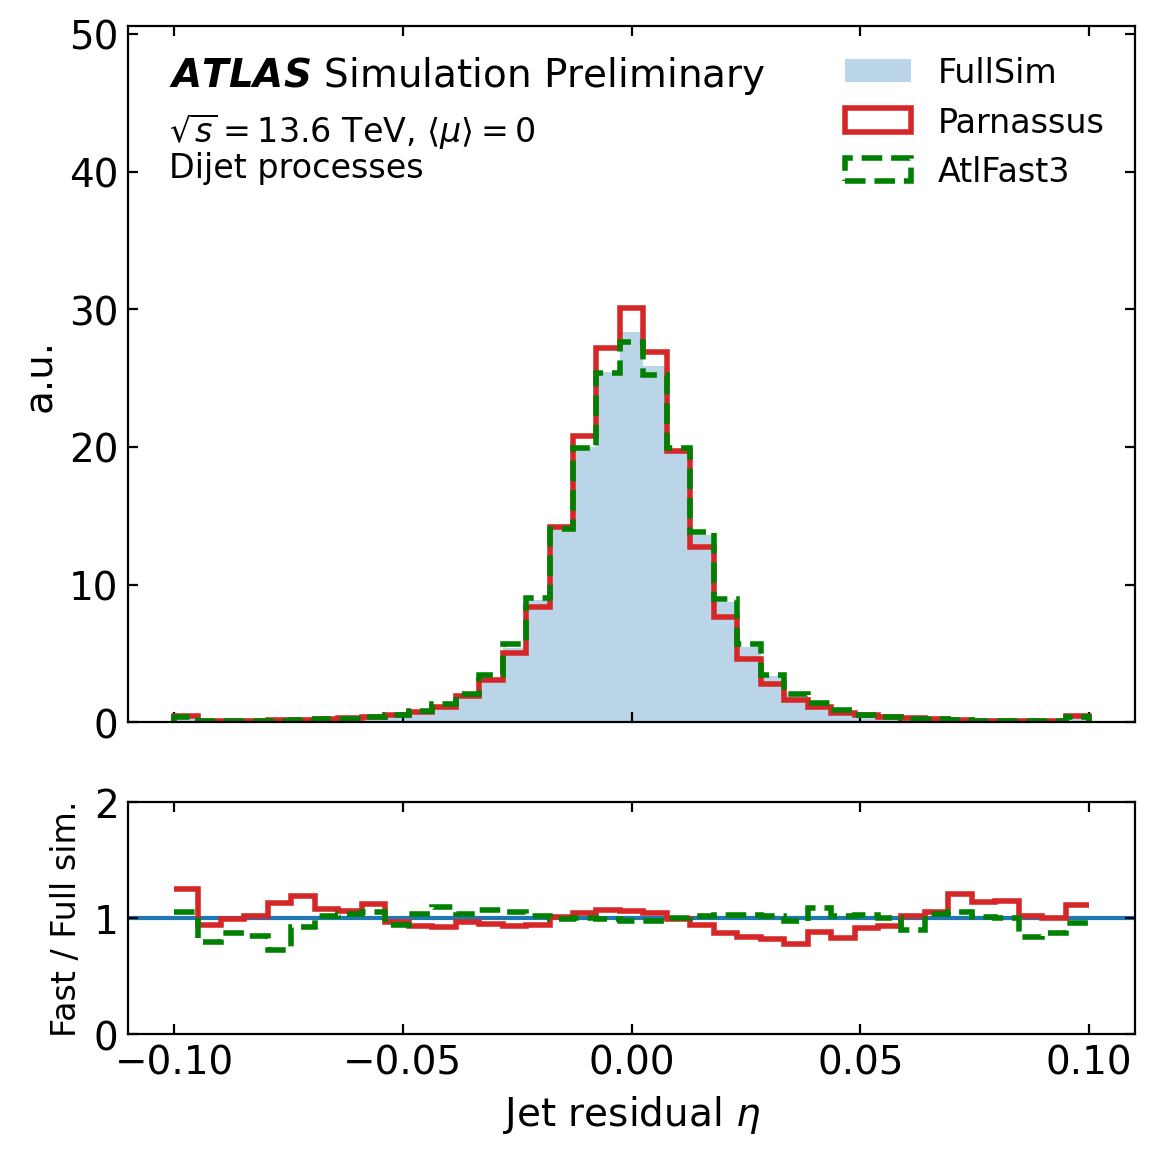

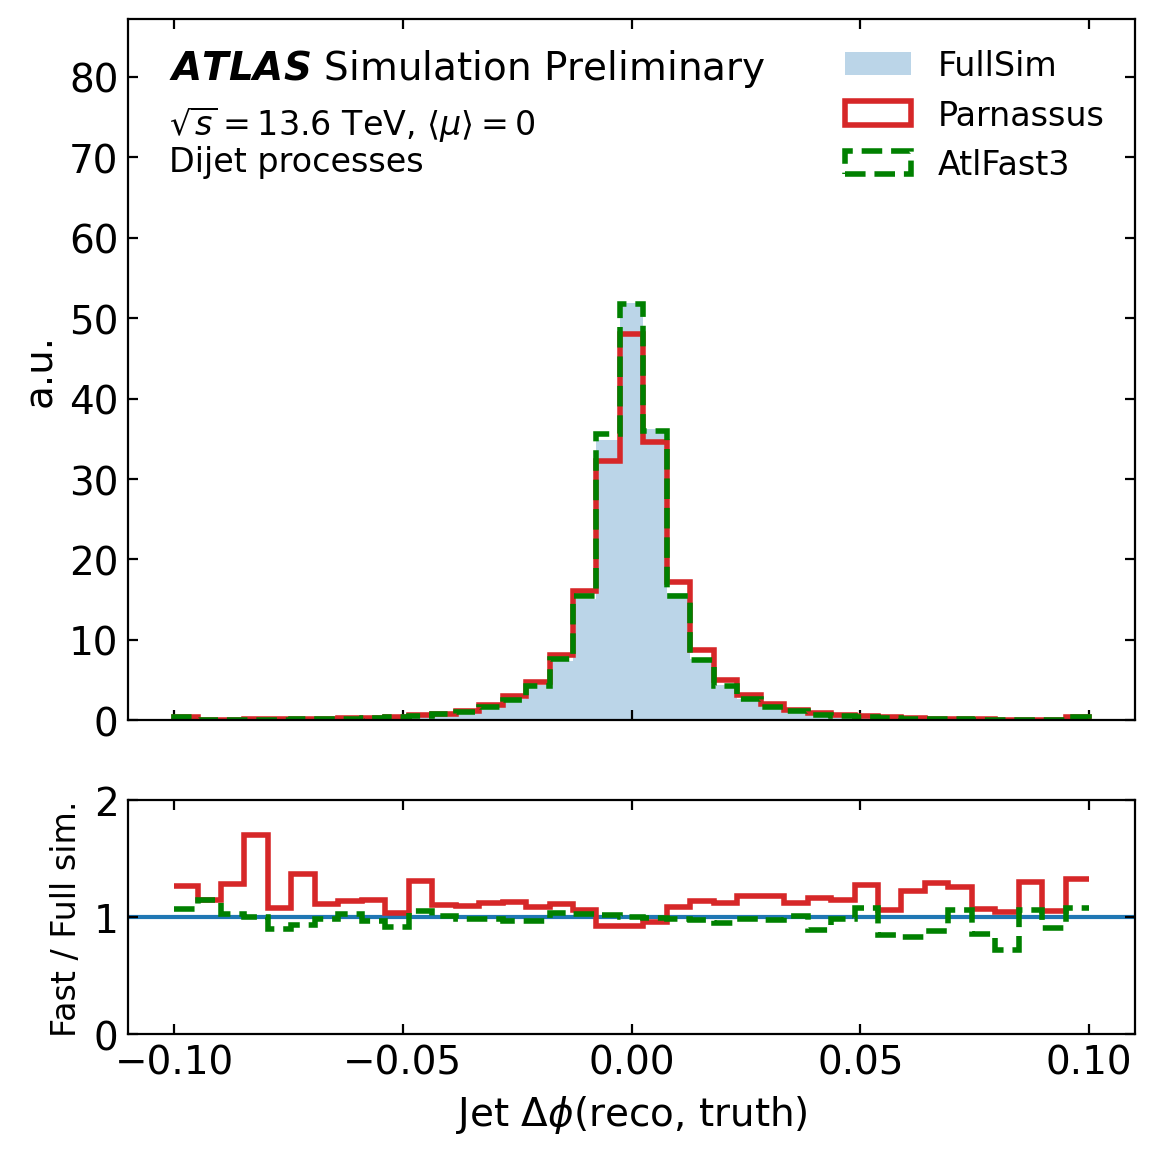

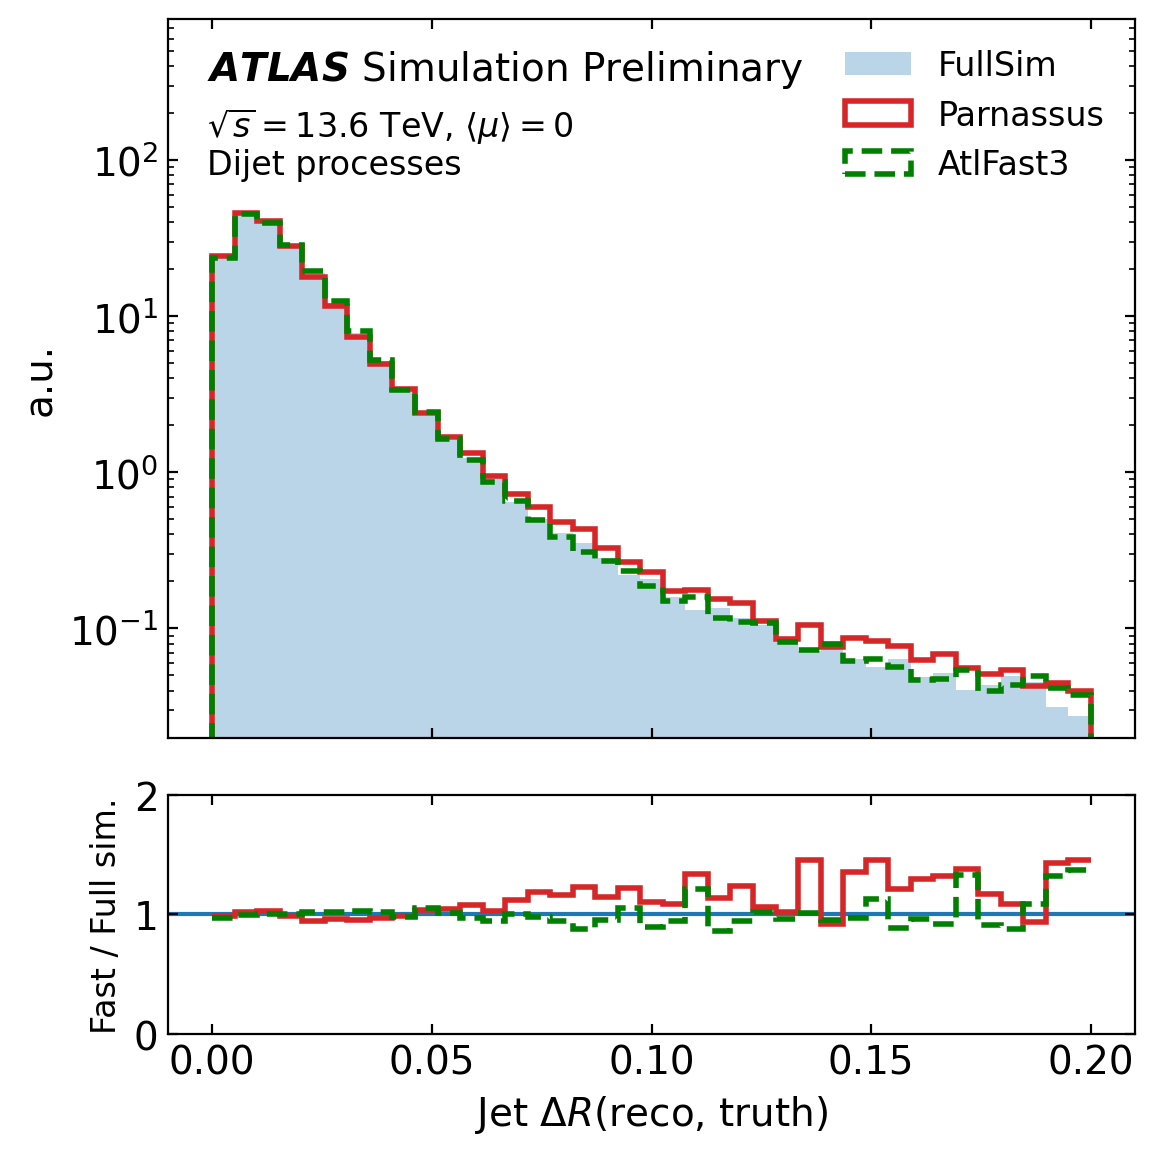

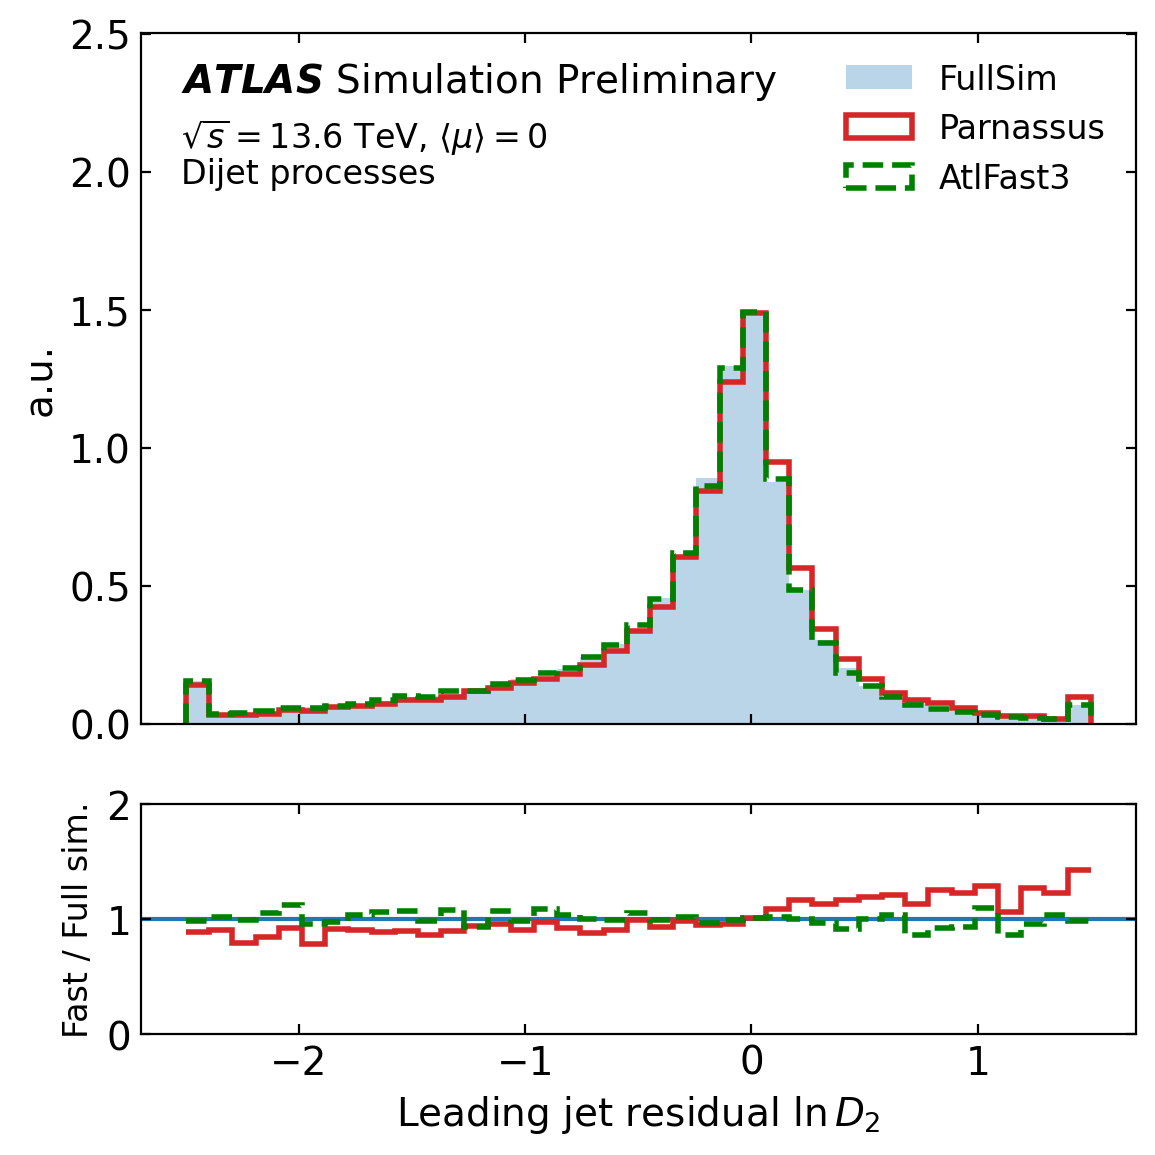

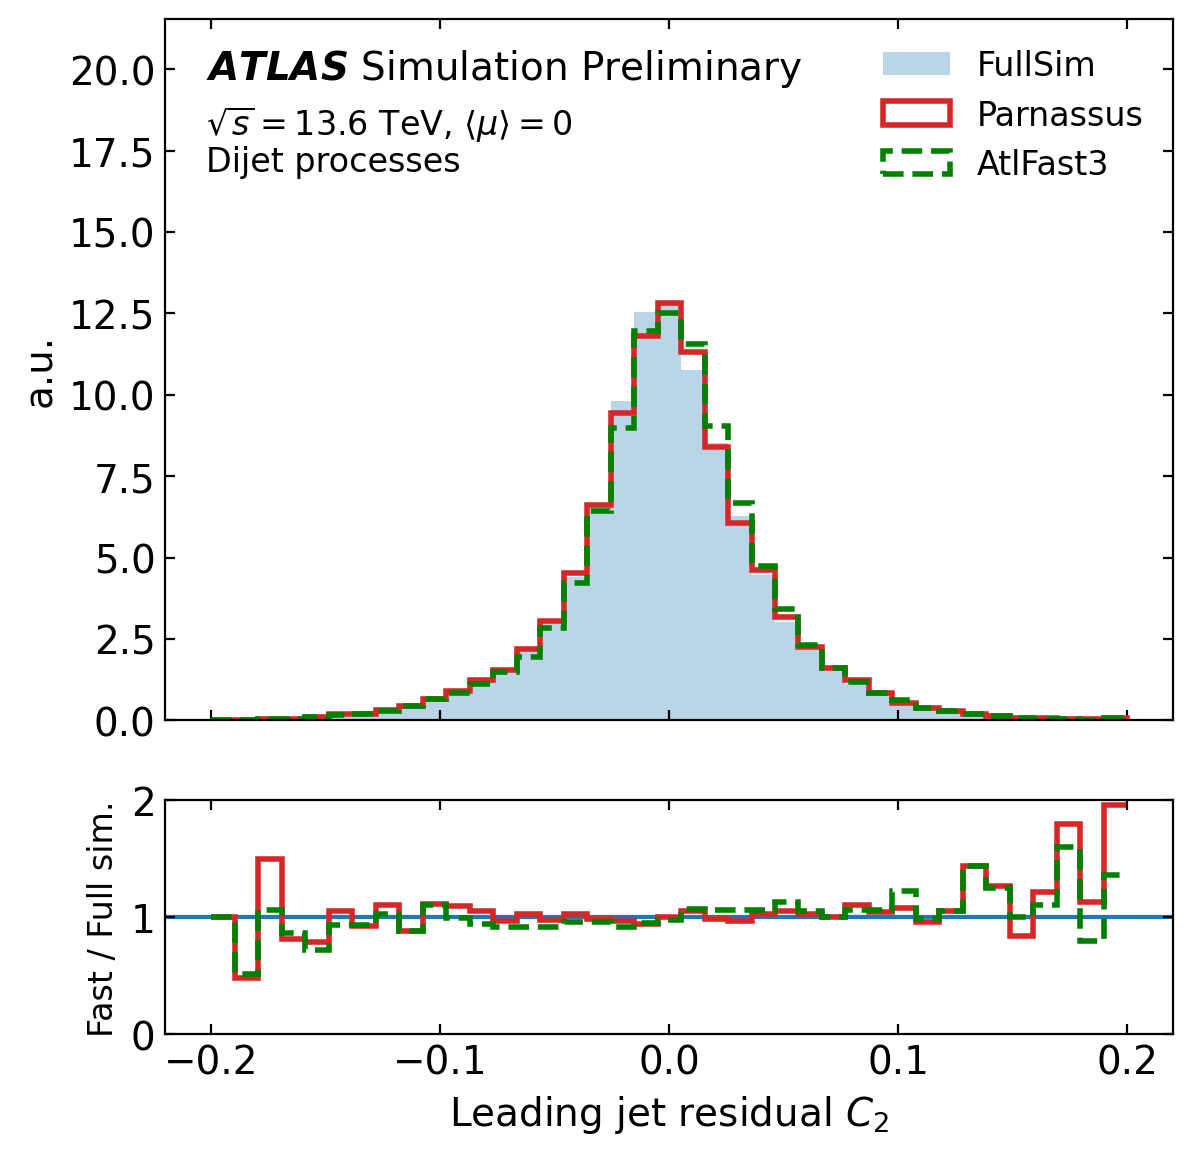

In [35]:

jet_res_var_list = ["pt", "eta", "phi", "dR", "d2", "c2"]
jet_res_xlabel_list = [
    r"Jet relative residual $p_T$",
    r"Jet residual $\eta$",
    r"Jet $\Delta \phi$(reco, truth)",
    r"Jet $\Delta R$(reco, truth)",
    r"Leading jet residual $\ln{D_2}$",
    r"Leading jet residual $C_2$",
]
# jet_res_xlabel_list = [
#     r"Jet ($p_T^{reco}$ - $p_T^{truth}$) / $p_T^{truth}$",
#     r"Jet ($\eta^{reco}$ - $\eta^{truth}$)",
#     r"Jet $\Delta \phi$(reco, truth)",
#     r"Jet $\Delta R$(reco, truth)",
#     r"Leading jet ($\ln{D_2}^{reco}$ - $\ln{D_2}^{truth}$)",
#     r"Leading jet ($\ln{C_2}^{reco}$ - $\ln{C_2}^{truth}$)",
# ]

for sample in samples_data.keys():
    for var, xlabel in zip(jet_res_var_list, jet_res_xlabel_list):
        fig, ax_main, ax_ratio = _make_fig(xlabel, yscale="log" if var == "dR" else "linear")
        ref_counts = None

        for key in ['pf', *fms]:
            if 'fm' in key:
                good_color = good_colors[xbins.index(int(key[2:]))]
            s = settings_dict.get(key, settings_dict["fm"] | {"label": "Parnassus", "color": good_color})
            if var in ["d2", "c2"]:
                plot_data = leading_jet_res_dicts[sample][key][var]
            elif var == "dR":
                plot_data = np.sqrt(jet_res_dicts[sample][key]["phi"]**2 + jet_res_dicts[sample][key]["eta"]**2)
            else:
                plot_data = jet_res_dicts[sample][key][var]
    
            counts, _, _ = _hist_overflow(ax_main,
                plot_data,
                bins=bins_jet_res[var][sample],
                **s,
                density=True,
                histtype="stepfilled" if key == "pf" else "step",
            )
            if key == "pf":
                ref_counts = counts
            else:
                _add_ratio_line(ax_ratio, counts, bins_jet_res[var][sample], ref_counts, s)

        _finalize_fig(fig, ax_main, ax_ratio)

        if var == "dR":
            ax_main.set_ylim(2e-2, 8e2)

        plt.show()

        fig.savefig(os.path.join(plot_dir, 'jet_residuals', f"{sample}_jet_residual_{var}.png"))
        fig.savefig(os.path.join(plot_dir, 'jet_residuals', f"{sample}_jet_residual_{var}.pdf"))


# Particle-level residual distributions

In [36]:
particle_matching_dicts = {key: {} for key in samples_data.keys()}
particle_matching_dicts_jet = {key: {} for key in samples_data.keys()}
particle_matching_dicts_bkg = {key: {} for key in samples_data.keys()}

In [37]:
import pickle

with open(
    # "/storage/agrp/dreyet/f_delphes/cms-flow-evt/evals/all_eval_mc23e_test_JZ1-9_FullSim_50steps_rcfm_atlas_part_mc23ae_JZ1-9_nsteps25_75_50_76k_test_eta25Eval.root",
    # "/storage/agrp/dreyet/f_delphes/cms-flow-evt/evals/all_eval_mc23e_test_JZ1-9_FullSim_50steps_rcfm_atlas_part_mc23ae_JZ1-9_nsteps10_76_50_76k_test_eta25Eval.root",
    # "/storage/agrp/dreyet/f_delphes/cms-flow-evt/evals/all_eval_mc23e_test_WprimeWZ_00000x_FullSim_50steps_rcfm_atlas_part_mc23ae_JZ1-9_nsteps10_76_50_44k_test_eta25Eval.root",
    # "/storage/agrp/dreyet/f_delphes/cms-flow-evt/evals/all_eval_mc23e_test_JZ1-9_FullSim_50steps_rcfm_atlas_part_mc23ae_JZ1-9_nsteps25_75_50_76k_test_eta25Eval.root",
    # "/storage/agrp/dreyet/f_delphes/cms-flow-evt/evals/all_eval_mc23e_test_JZ1-9_FullSim_50steps_rcfm_atlas_part_mc23ae_JZ1-9_nsteps25_75_50_bugfix_58k_test_eta25Eval.root",
    "/storage/agrp/dreyet/f_delphes/cms-flow-evt/evals/all_eval_mc23e_test_JZ1-9_FullSim_50steps_rcfm_atlas_part_mc23ae_JZ1-9_nsteps25_75_50_bugfix_58k_test_eta27Eval.root",
    "rb",
) as f:
    particle_matching_dicts = pickle.load(f)
with open(
    # "/storage/agrp/dreyet/f_delphes/cms-flow-evt/evals/jet_eval_mc23e_test_JZ1-9_FullSim_50steps_rcfm_atlas_part_mc23ae_JZ1-9_nsteps25_75_50_76k_test_eta25Eval_jet.pkl",
    # "/storage/agrp/dreyet/f_delphes/cms-flow-evt/evals/jet_eval_mc23e_test_JZ1-9_FullSim_50steps_rcfm_atlas_part_mc23ae_JZ1-9_nsteps10_76_50_76k_test_eta25Eval_jet.pkl",
    # "/storage/agrp/dreyet/f_delphes/cms-flow-evt/evals/jet_eval_mc23e_test_WprimeWZ_00000x_FullSim_50steps_rcfm_atlas_part_mc23ae_JZ1-9_nsteps10_76_50_44k_test_eta25Eval_jet.pkl",
    # "/storage/agrp/dreyet/f_delphes/cms-flow-evt/evals/jet_eval_mc23e_test_JZ1-9_FullSim_50steps_rcfm_atlas_part_mc23ae_JZ1-9_nsteps25_75_50_76k_test_eta25Eval_jet.pkl",
    # "/storage/agrp/dreyet/f_delphes/cms-flow-evt/evals/jet_eval_mc23e_test_JZ1-9_FullSim_50steps_rcfm_atlas_part_mc23ae_JZ1-9_nsteps25_75_50_bugfix_58k_test_eta25Eval_jet.pkl",
    "/storage/agrp/dreyet/f_delphes/cms-flow-evt/evals/jet_eval_mc23e_test_JZ1-9_FullSim_50steps_rcfm_atlas_part_mc23ae_JZ1-9_nsteps25_75_50_bugfix_58k_test_eta27Eval_jet.pkl",
    "rb",
) as f:
    particle_matching_dicts_jet = pickle.load(f)
with open(
    # "/storage/agrp/dreyet/f_delphes/cms-flow-evt/evals/bkg_eval_mc23e_test_JZ1-9_FullSim_50steps_rcfm_atlas_part_mc23ae_JZ1-9_nsteps25_75_50_76k_test_eta25Eval_bkg.pkl",
    # "/storage/agrp/dreyet/f_delphes/cms-flow-evt/evals/bkg_eval_mc23e_test_JZ1-9_FullSim_50steps_rcfm_atlas_part_mc23ae_JZ1-9_nsteps10_76_50_76k_test_eta25Eval_bkg.pkl",
    # "/storage/agrp/dreyet/f_delphes/cms-flow-evt/evals/bkg_eval_mc23e_test_WprimeWZ_00000x_FullSim_50steps_rcfm_atlas_part_mc23ae_JZ1-9_nsteps10_76_50_44k_test_eta25Eval_bkg.pkl",
    # "/storage/agrp/dreyet/f_delphes/cms-flow-evt/evals/bkg_eval_mc23e_test_JZ1-9_FullSim_50steps_rcfm_atlas_part_mc23ae_JZ1-9_nsteps25_75_50_76k_test_eta25Eval_bkg.pkl",
    # "/storage/agrp/dreyet/f_delphes/cms-flow-evt/evals/bkg_eval_mc23e_test_JZ1-9_FullSim_50steps_rcfm_atlas_part_mc23ae_JZ1-9_nsteps25_75_50_bugfix_58k_test_eta25Eval_bkg.pkl",
    "/storage/agrp/dreyet/f_delphes/cms-flow-evt/evals/bkg_eval_mc23e_test_JZ1-9_FullSim_50steps_rcfm_atlas_part_mc23ae_JZ1-9_nsteps25_75_50_bugfix_58k_test_eta27Eval_bkg.pkl",
    "rb",
) as f:
    particle_matching_dicts_bkg = pickle.load(f)

In [38]:
particle_res_dicts = {key: {} for key in samples_data.keys()}
particle_res_dicts_jet = {key: {} for key in samples_data.keys()}
particle_res_dicts_bkg = {key: {} for key in samples_data.keys()}

In [39]:
for sample in samples_data.keys():
    print(f"Processing... {sample} sample")
    for key in samples_data[sample]["all"].keys():
        if key == 'tr':
            continue
        particle_res_dicts[sample][key] = calc_residuals(
            particle_matching_dicts[sample][key][1],
            particle_matching_dicts[sample][key][0],
            samples_data[sample]["all"][key],
            samples_data[sample]["all"]["tr"],
        )
for sample in samples_data.keys():
    print(f"Processing... {sample} sample")
    for key in samples_data[sample]["all"].keys():
        if key == 'tr':
            continue
        particle_res_dicts_jet[sample][key] = calc_residuals(
            particle_matching_dicts_jet[sample][key][1],
            particle_matching_dicts_jet[sample][key][0],
            samples_data[sample]["jet"][key],
            samples_data[sample]["jet"]["tr"],
        )
for sample in samples_data.keys():
    print(f"Processing... {sample} sample")
    for key in samples_data[sample]["all"].keys():
        if key == 'tr':
            continue
        particle_res_dicts_bkg[sample][key] = calc_residuals(
            particle_matching_dicts_bkg[sample][key][1],
            particle_matching_dicts_bkg[sample][key][0],
            samples_data[sample]["bkg"][key],
            samples_data[sample]["bkg"]["tr"],
        )

Processing... JZall sample


residuals: 100%|██████████| 58522/58522 [00:00<00:00, 120857.27it/s]


Processing... JZall sample


residuals: 100%|██████████| 58522/58522 [00:00<00:00, 148523.18it/s]


Processing... JZall sample


residuals: 100%|██████████| 58522/58522 [00:00<00:00, 161359.90it/s]


## All particles

In [40]:
bins_res = {
    "pt": np.linspace(-1, 1, 40),
    "eta": np.linspace(-0.4, 0.4, 40),
    "phi": np.linspace(-0.4, 0.4, 40),
    "dR": np.linspace(0, 0.4, 40),
}

num_particle_features = len(bins_res)

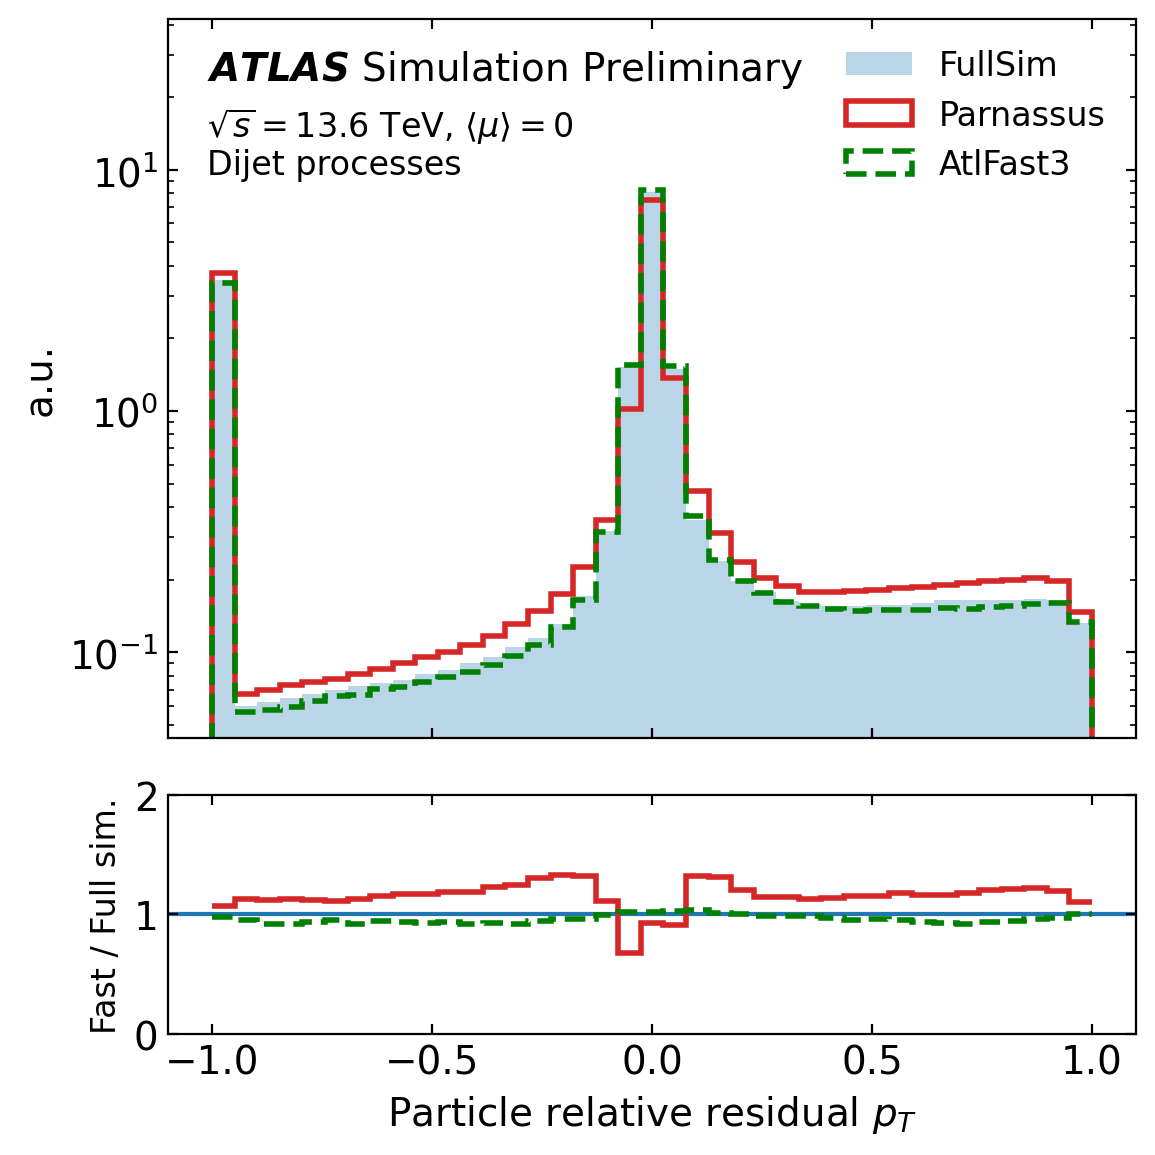

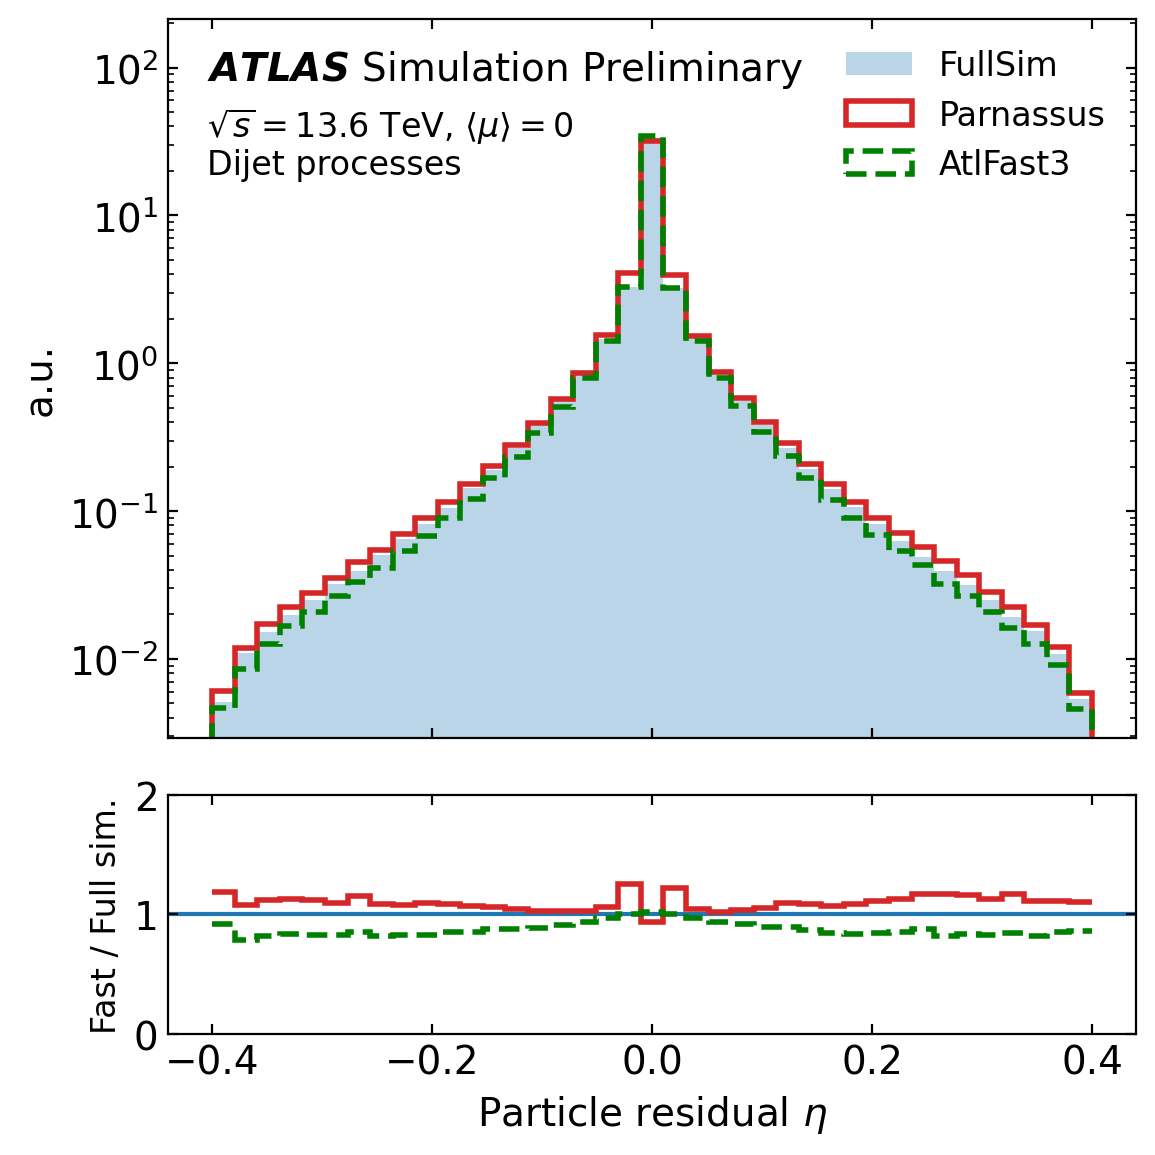

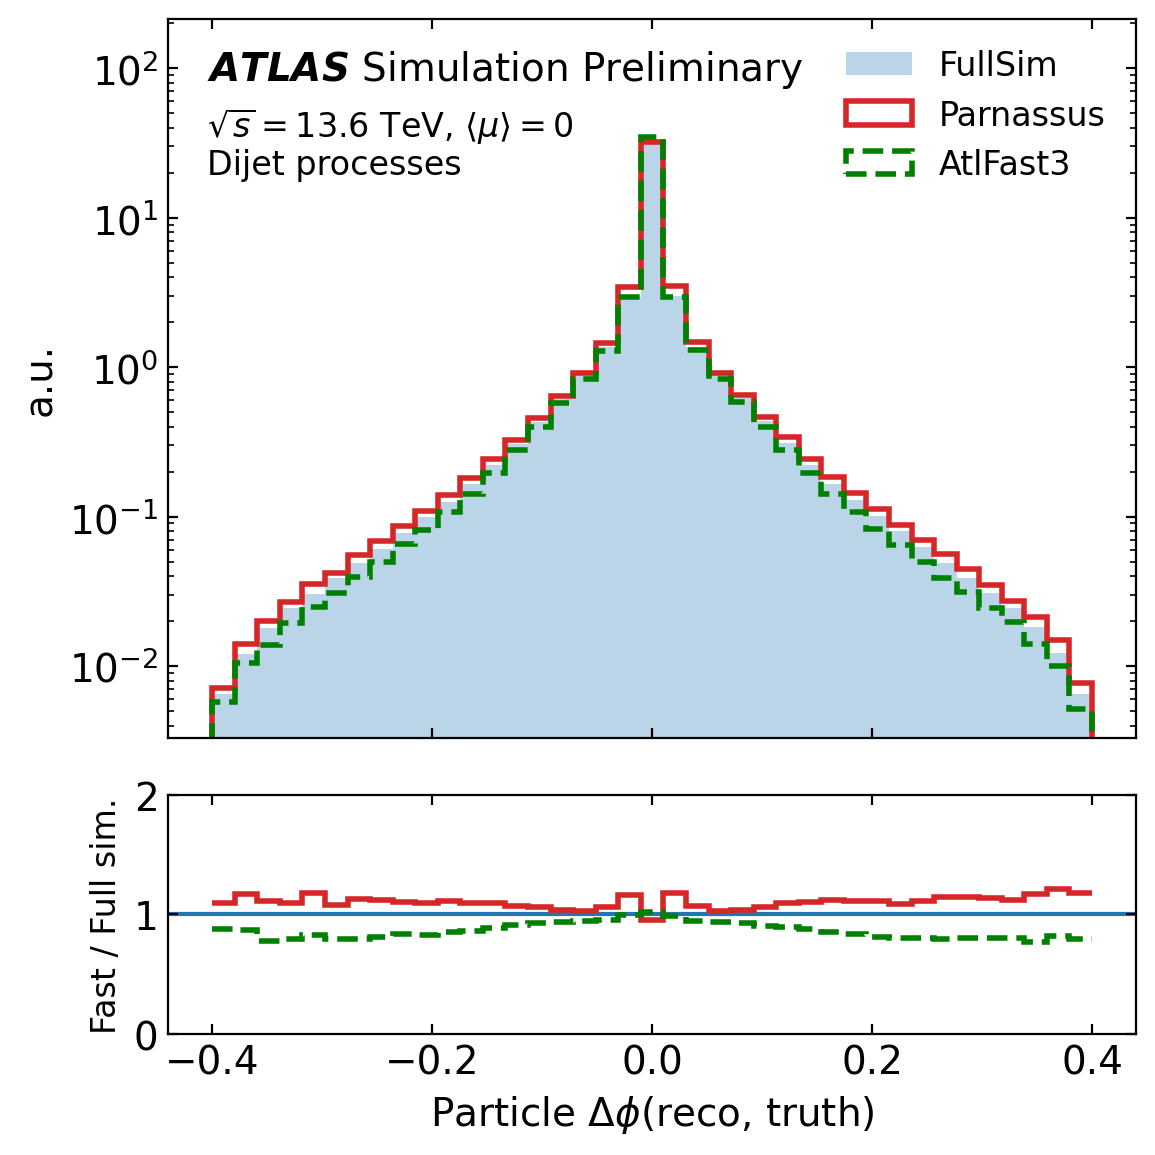

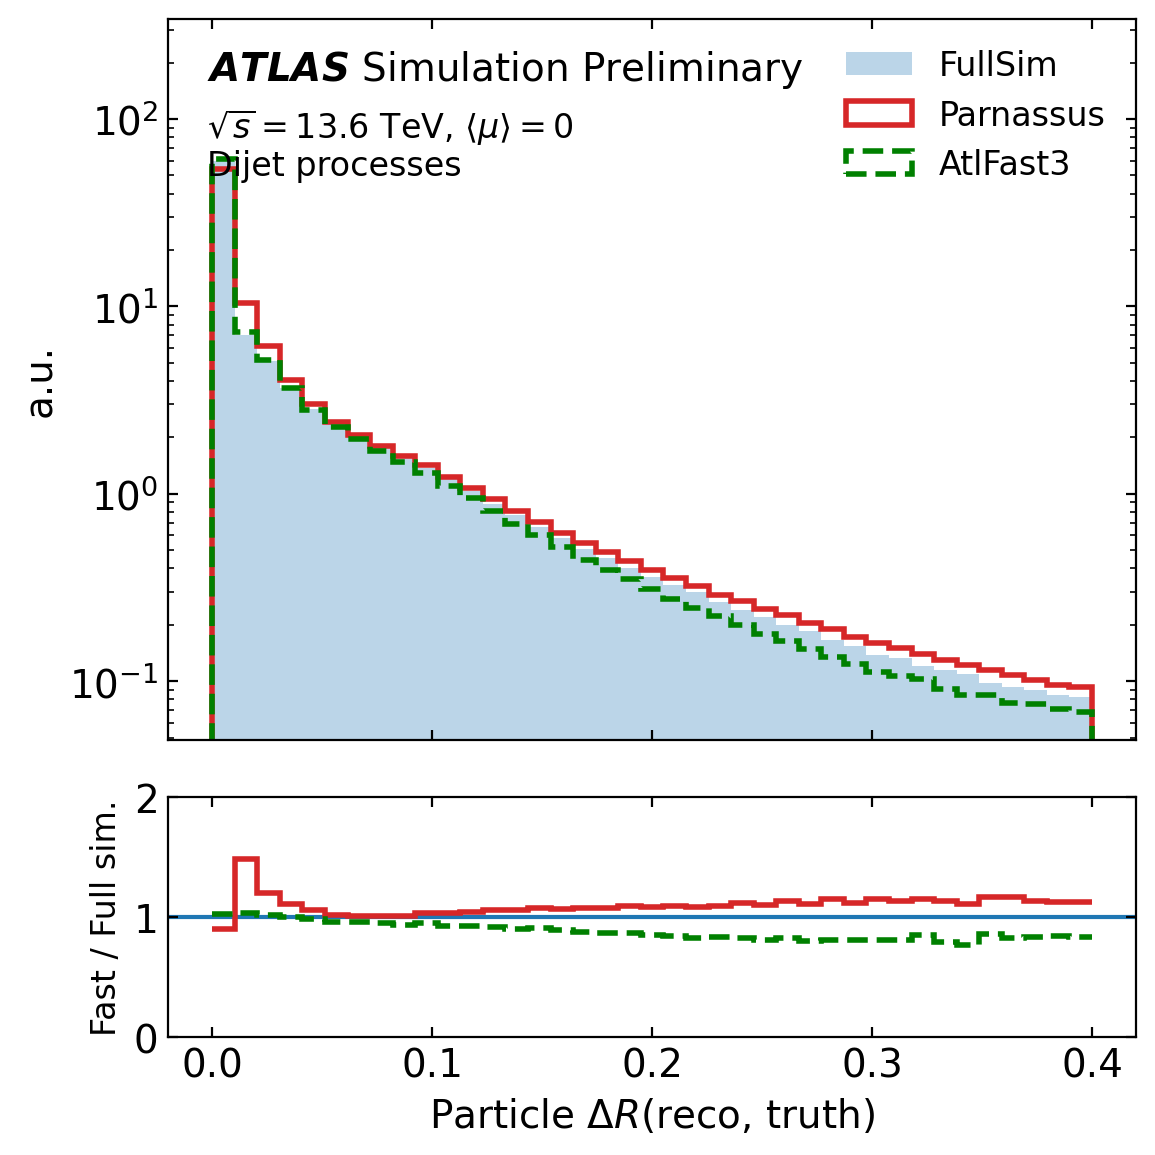

In [41]:

part_res_var_list    = ["pt", "eta", "phi", "dR"] #, "vx", "vy", "vz"]
part_res_xlabel_list = [r"Particle relative residual $p_T$", 
                        r"Particle residual $\eta$", 
                        r"Particle $\Delta \phi$(reco, truth)", 
                        r"Particle $\Delta R$(reco, truth)"]
# part_res_xlabel_list = [r"Particle ($p_T^{reco}$ - $p_T^{truth}$) / $p_T^{truth}$", 
#                         r"Particle ($\eta^{reco}$ - $\eta^{truth}$)",
#                         r"Particle $\Delta \phi(reco, truth)$",
#                         r"Particle $\Delta R(reco, truth)$"]

for sample in samples_data.keys():
    for var, xlabel in zip(part_res_var_list, part_res_xlabel_list):
        fig, ax_main, ax_ratio = _make_fig(xlabel, yscale="log")
        ref_counts = None

        for key in ['pf', *fms]:
            if 'fm' in key:
                good_color = good_colors[xbins.index(int(key[2:]))]
            s = (
                settings_dict.get(key, settings_dict["fm"] | {"label": "Parnassus", "color": good_color})
                | {"linewidth": 2}
            )
            if var == "dR":
                value = np.sqrt(particle_res_dicts[sample][key]["phi"]**2 + particle_res_dicts[sample][key]["eta"]**2)
            else:
                value = particle_res_dicts[sample][key][var]
            counts, _, _ = _hist_overflow(ax_main,
                value,
                bins=bins_res[var], **s,
                density=True,
                histtype="stepfilled" if key == "pf" else "step",
            )
            if key == "pf":
                ref_counts = counts
            else:
                _add_ratio_line(ax_ratio, counts, bins_res[var], ref_counts, s)

        _finalize_fig(fig, ax_main, ax_ratio)
        plt.show()

        fig.savefig(os.path.join(plot_dir, 'particle_residuals', f"{sample}_particle_all_residual_{var}.png"))
        fig.savefig(os.path.join(plot_dir, 'particle_residuals', f"{sample}_particle_all_residual_{var}.pdf"))


## Jet particles

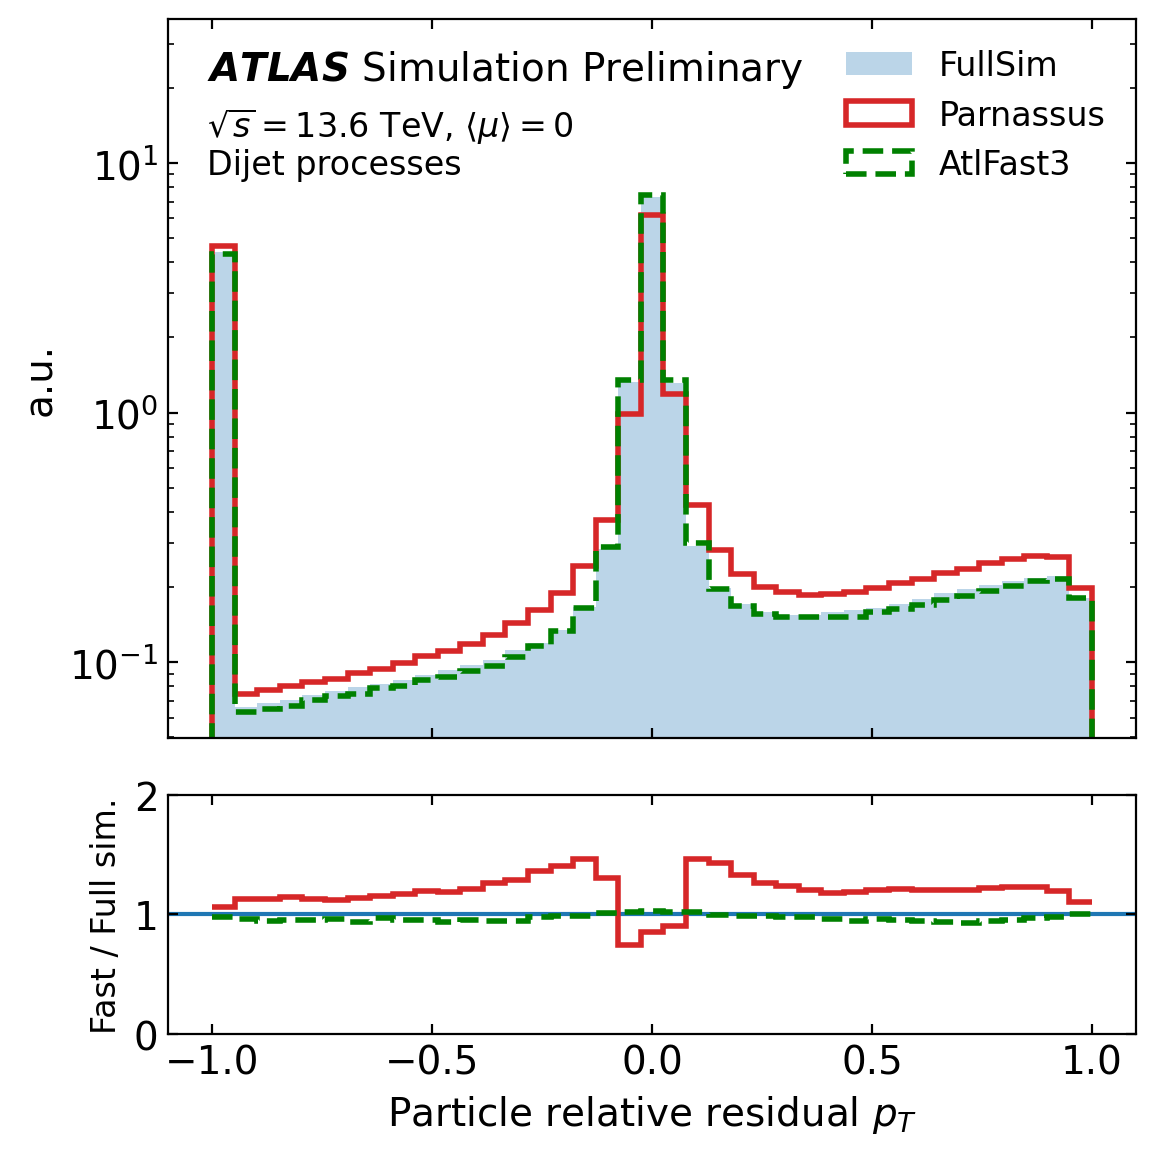

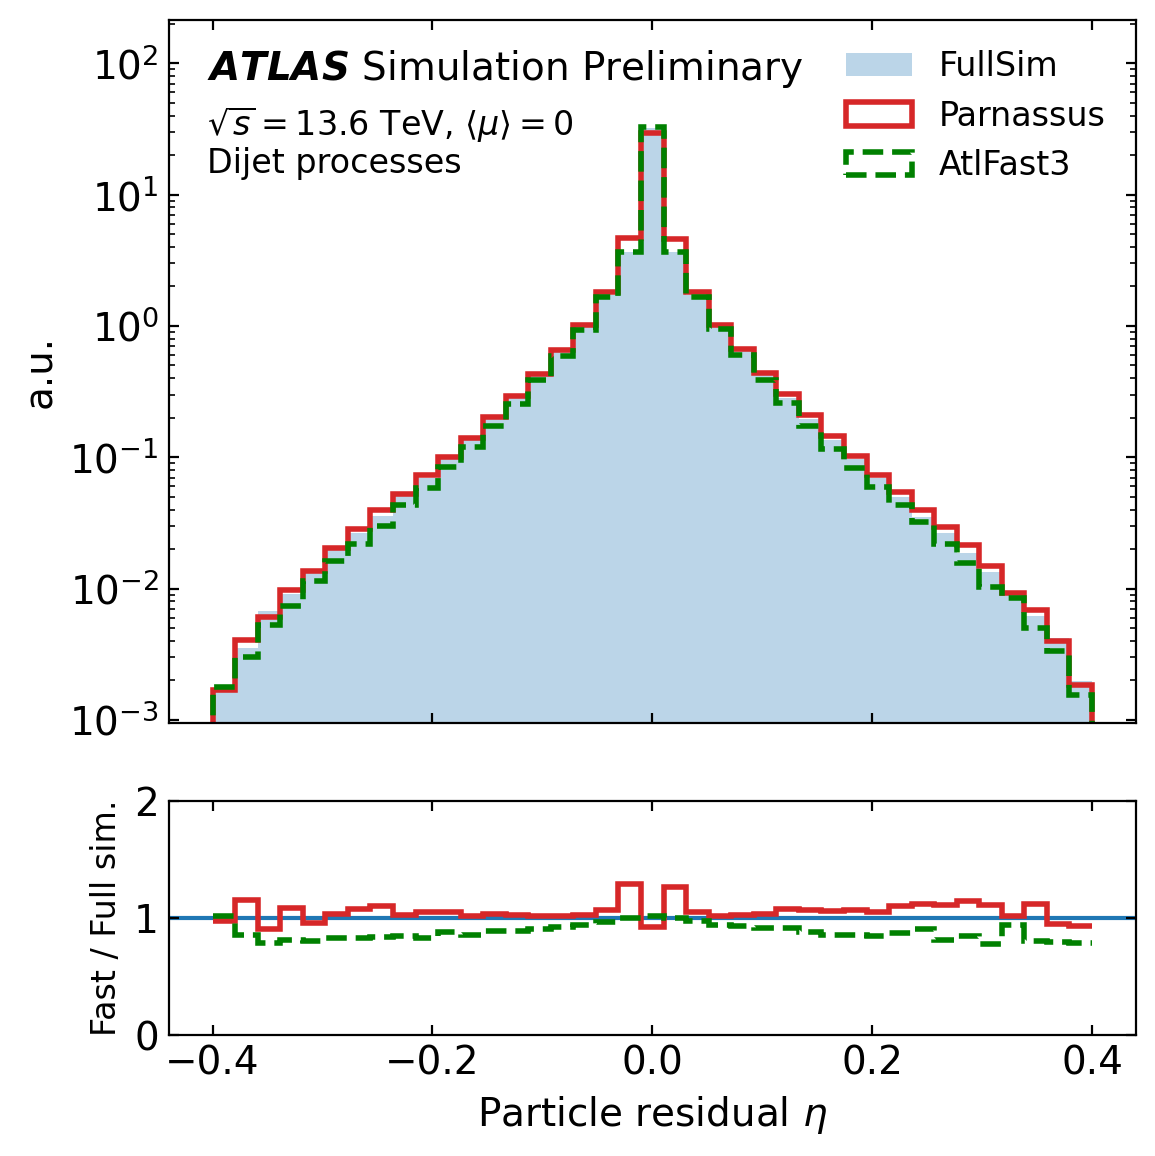

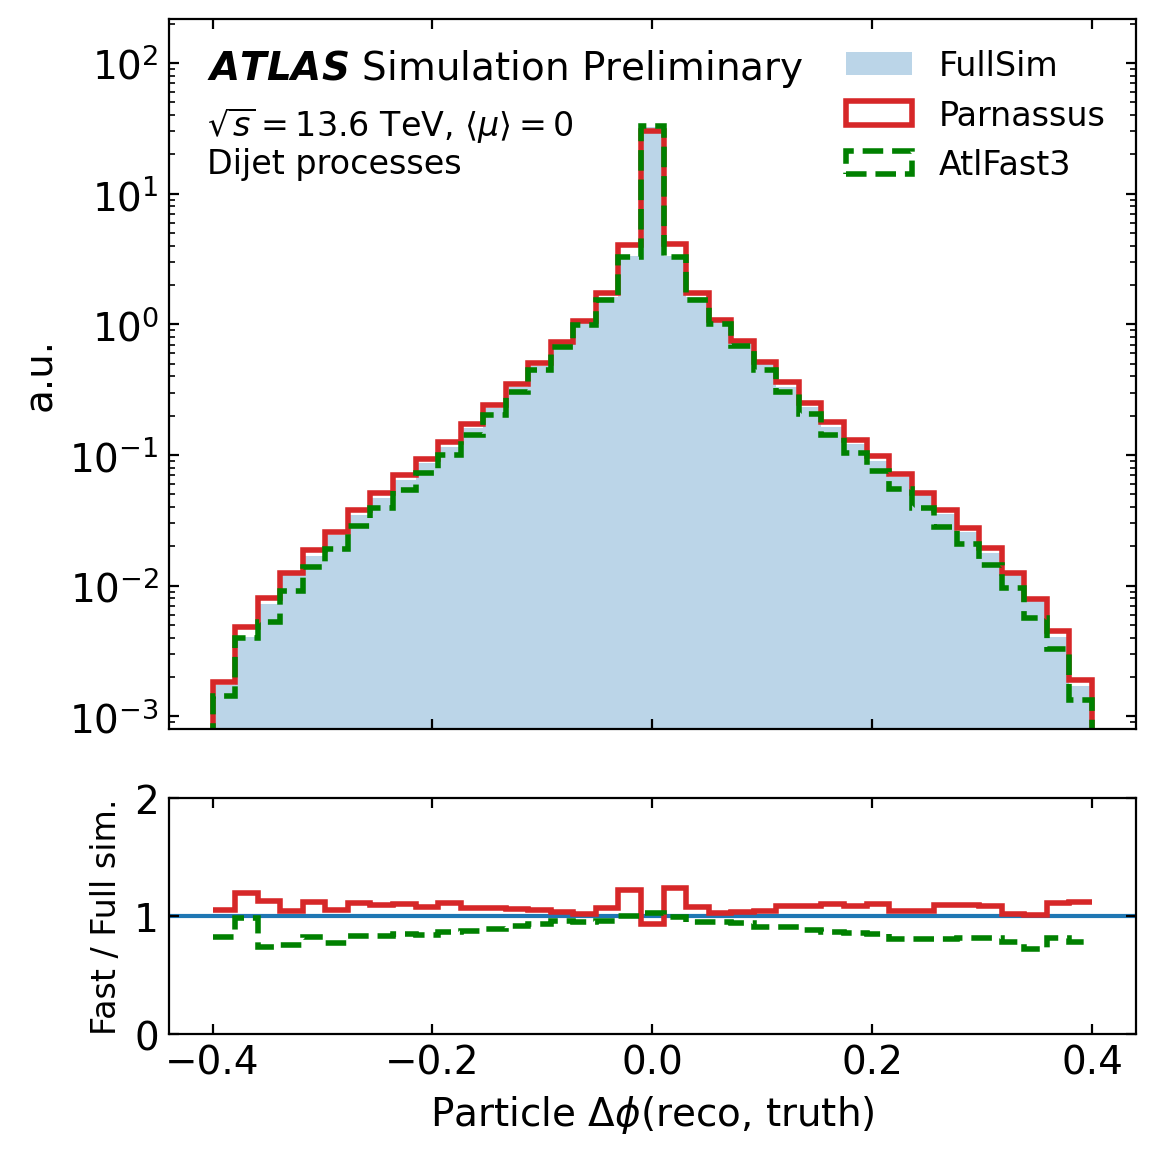

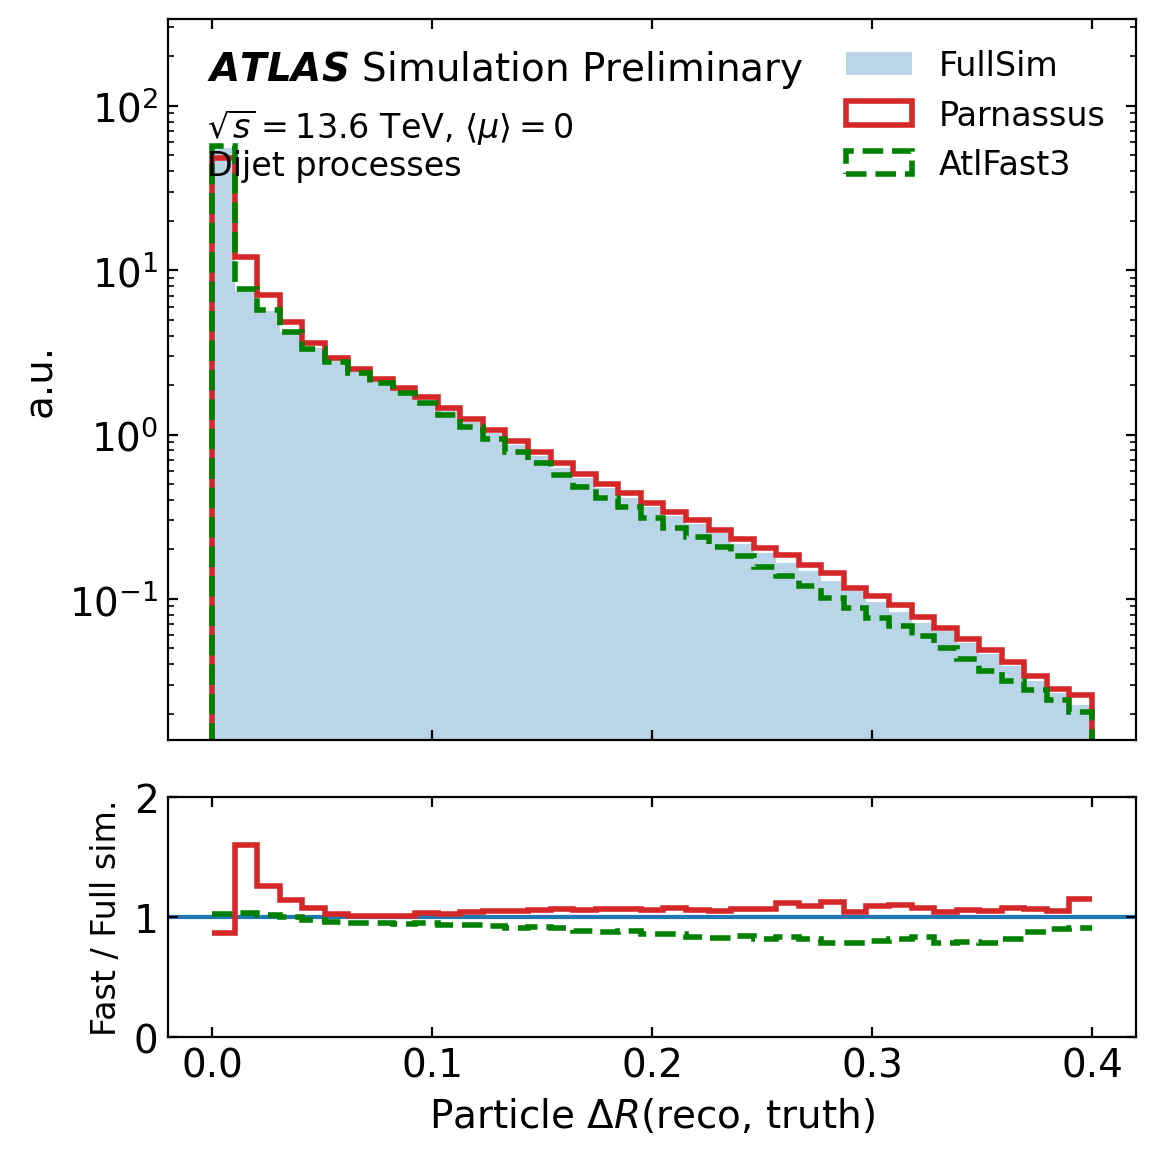

In [42]:

for sample in samples_data.keys():
    for var, xlabel in zip(part_res_var_list, part_res_xlabel_list):
        fig, ax_main, ax_ratio = _make_fig(xlabel, yscale="log")
        ref_counts = None

        for key in ['pf', *fms]:
            if 'fm' in key:
                good_color = good_colors[xbins.index(int(key[2:]))]
            s = (
                settings_dict.get(key, settings_dict["fm"] | {"label": "Parnassus", "color": good_color})
                | {"linewidth": 2}
            )
            if var == "dR":
                value = np.sqrt(particle_res_dicts_jet[sample][key]["phi"]**2 + particle_res_dicts_jet[sample][key]["eta"]**2)
            else:
                value = particle_res_dicts_jet[sample][key][var]
            counts, _, _ = _hist_overflow(ax_main,
                value,
                bins=bins_res[var], **s,
                density=True,
                histtype="stepfilled" if key == "pf" else "step",
            )
            if key == "pf":
                ref_counts = counts
            else:
                _add_ratio_line(ax_ratio, counts, bins_res[var], ref_counts, s)

        _finalize_fig(fig, ax_main, ax_ratio)
        plt.show()

        fig.savefig(os.path.join(plot_dir, 'particle_residuals', f"{sample}_particle_jet_residual_{var}.png"))
        fig.savefig(os.path.join(plot_dir, 'particle_residuals', f"{sample}_particle_jet_residual_{var}.pdf"))


## Bkg particles

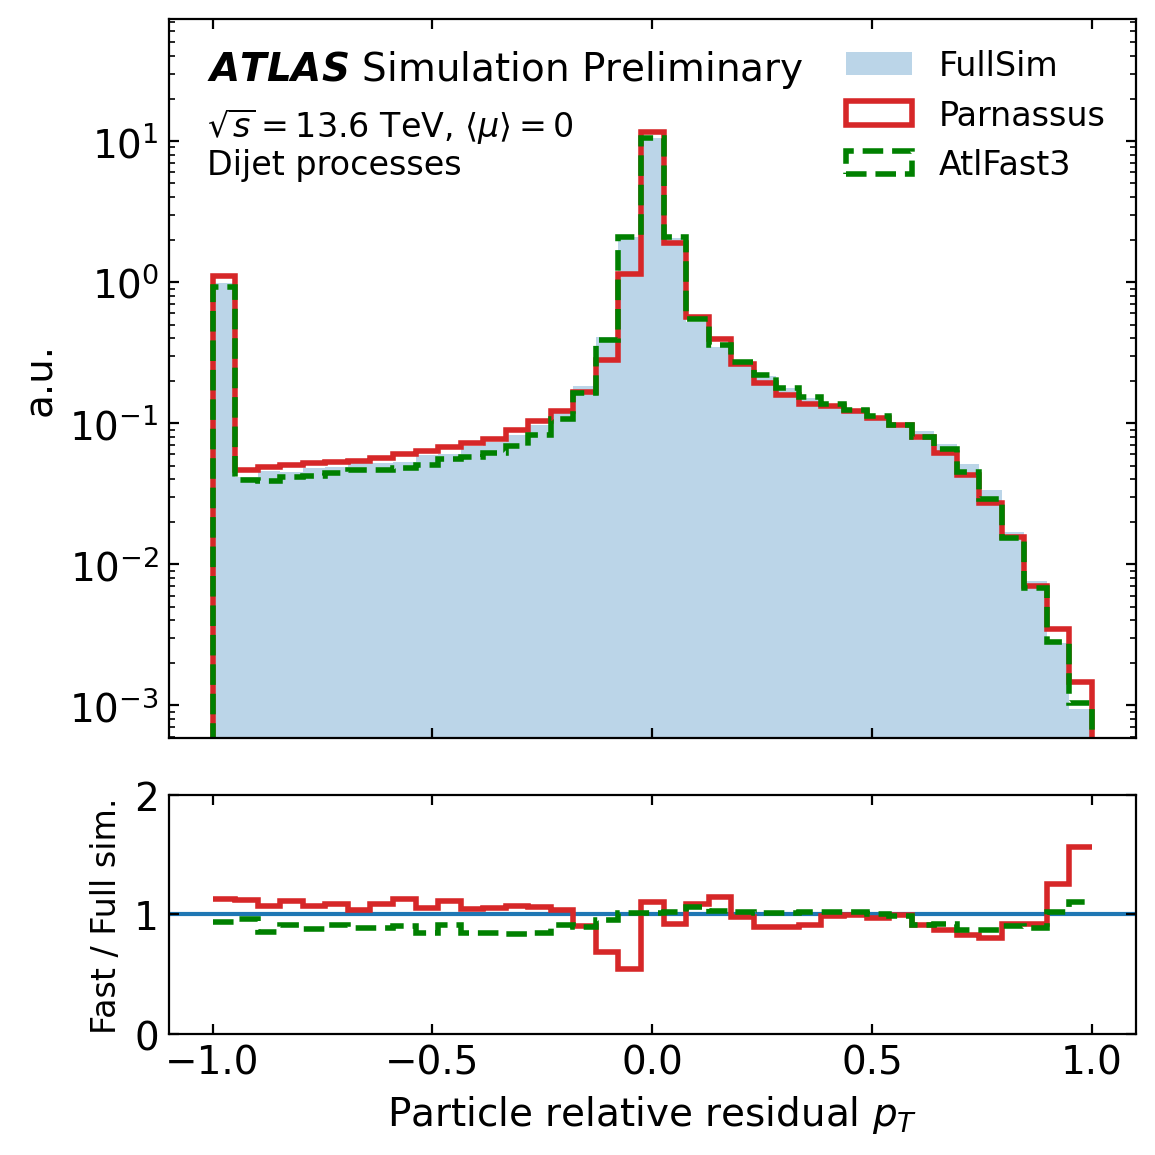

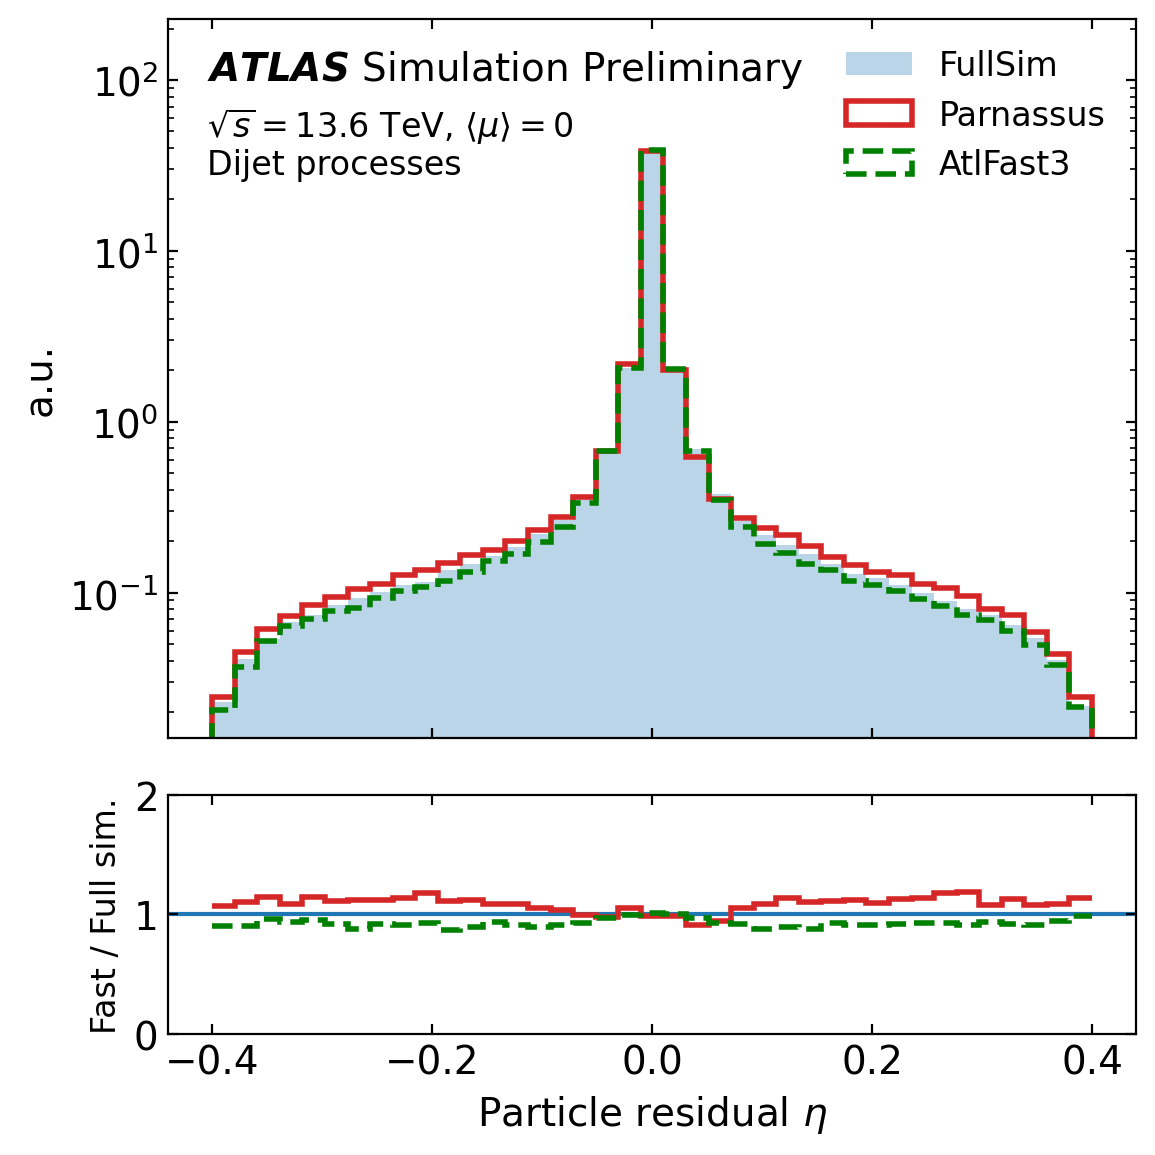

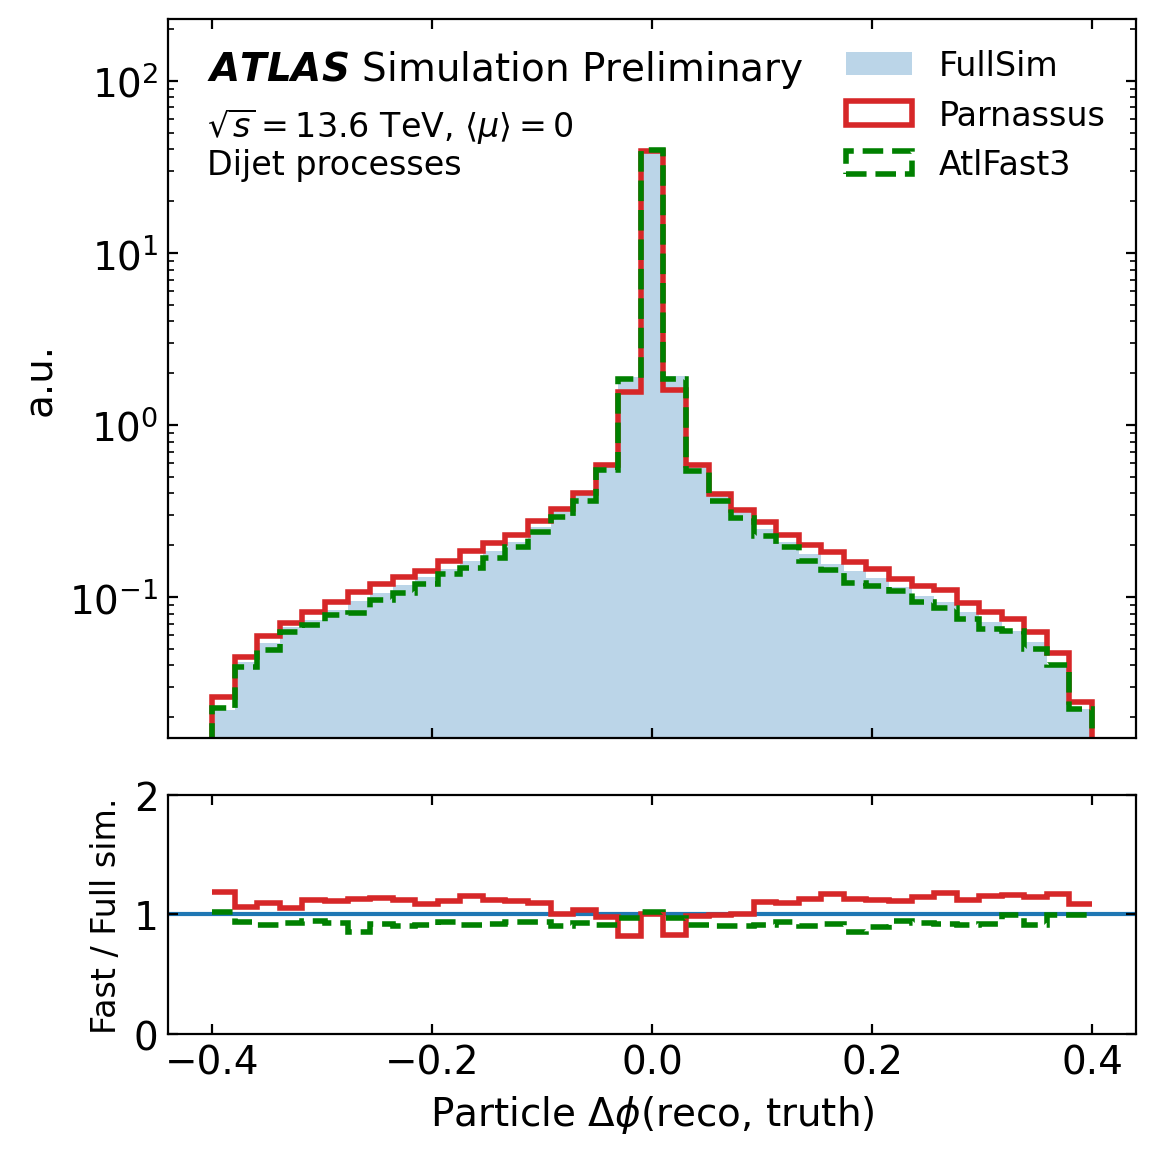

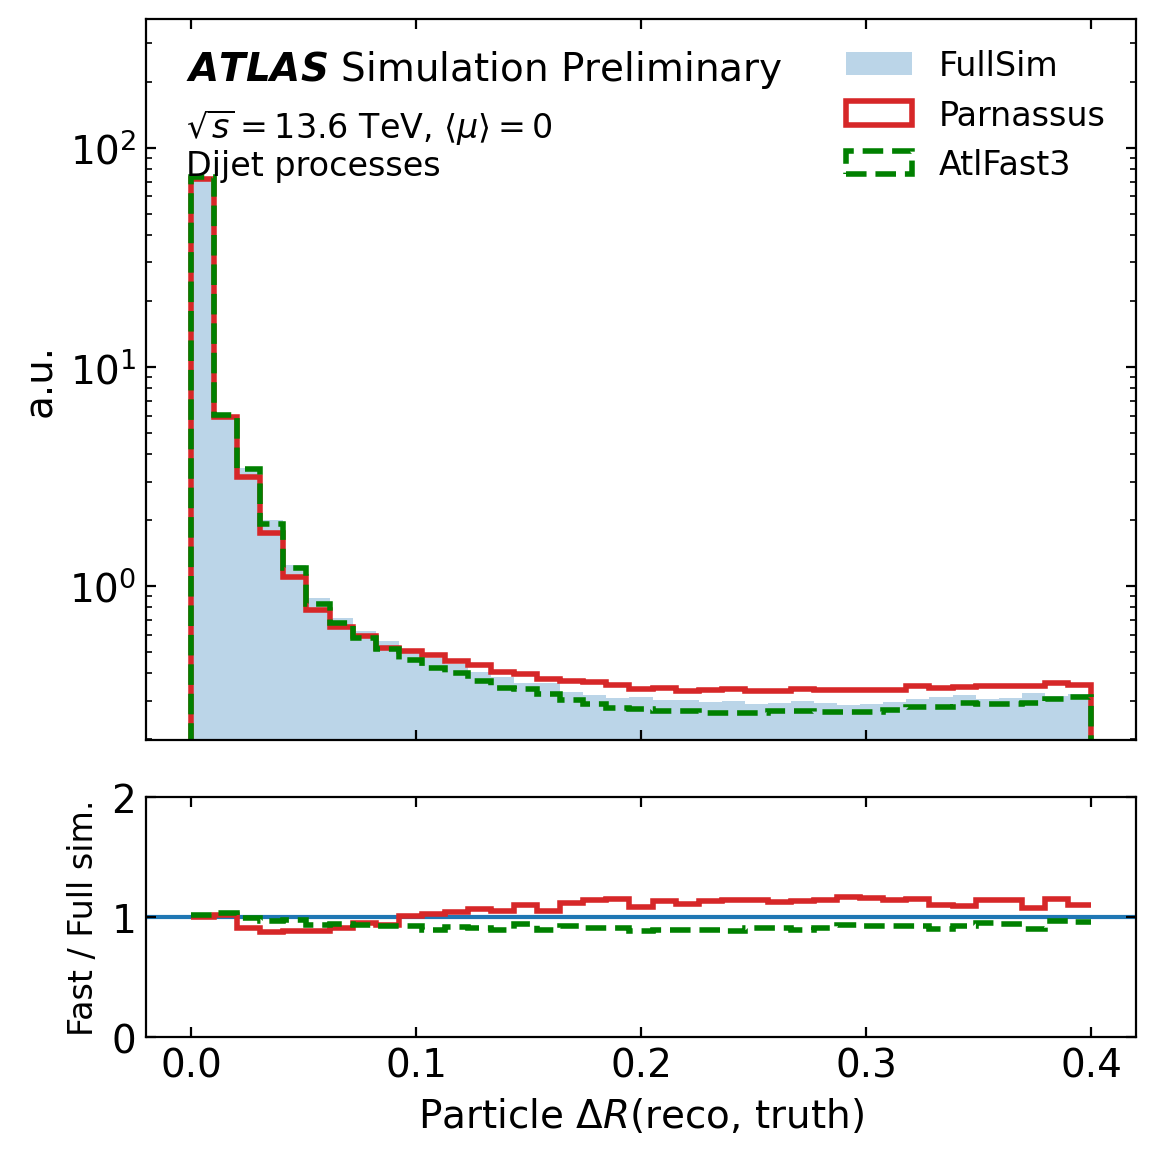

In [43]:

for sample in samples_data.keys():
    for var, xlabel in zip(part_res_var_list, part_res_xlabel_list):
        fig, ax_main, ax_ratio = _make_fig(xlabel, yscale="log")
        ref_counts = None

        for key in ['pf', *fms]:
            if 'fm' in key:
                good_color = good_colors[xbins.index(int(key[2:]))]
            s = (
                settings_dict.get(key, settings_dict["fm"] | {"label": "Parnassus", "color": good_color})
                | {"linewidth": 2}
            )
            if var == "dR":
                value = np.sqrt(particle_res_dicts_bkg[sample][key]["phi"]**2 + particle_res_dicts_bkg[sample][key]["eta"]**2)
            else:
                value = particle_res_dicts_bkg[sample][key][var]
            counts, _, _ = _hist_overflow(ax_main,
                value,
                bins=bins_res[var], **s,
                density=True,
                histtype="stepfilled" if key == "pf" else "step",
            )
            if key == "pf":
                ref_counts = counts
            else:
                _add_ratio_line(ax_ratio, counts, bins_res[var], ref_counts, s)

        _finalize_fig(fig, ax_main, ax_ratio)
        plt.show()

        fig.savefig(os.path.join(plot_dir, 'particle_residuals', f"{sample}_particle_bkg_residual_{var}.png"))

## Class plots

In [44]:
classes_dicts = {key: {} for key in samples_data.keys()}
classes_dicts_jet = {key: {} for key in samples_data.keys()}
classes_dicts_bkg = {key: {} for key in samples_data.keys()}

In [45]:
for sample in samples_data.keys():
    print(f"Processing... {sample} sample")
    for key in samples_data[sample]["all"].keys():
        if key == 'tr':
            continue
        classes_dicts[sample][key] = get_classes(
            particle_matching_dicts[sample][key][1],
            particle_matching_dicts[sample][key][0],
            samples_data[sample]["all"][key],
            samples_data[sample]["all"]["tr"],
        )
for sample in samples_data.keys():
    print(f"Processing... {sample} sample")
    for key in samples_data[sample]["all"].keys():
        if key == 'tr':
            continue
        classes_dicts_jet[sample][key] = get_classes(
            particle_matching_dicts_jet[sample][key][1],
            particle_matching_dicts_jet[sample][key][0],
            samples_data[sample]["jet"][key],
            samples_data[sample]["jet"]["tr"],
        )
for sample in samples_data.keys():
    print(f"Processing... {sample} sample")
    for key in samples_data[sample]["all"].keys():
        if key == 'tr':
            continue
        classes_dicts_bkg[sample][key] = get_classes(
            particle_matching_dicts_bkg[sample][key][1],
            particle_matching_dicts_bkg[sample][key][0],
            samples_data[sample]["bkg"][key],
            samples_data[sample]["bkg"]["tr"],
        )

Processing... JZall sample
Processing... JZall sample
Processing... JZall sample


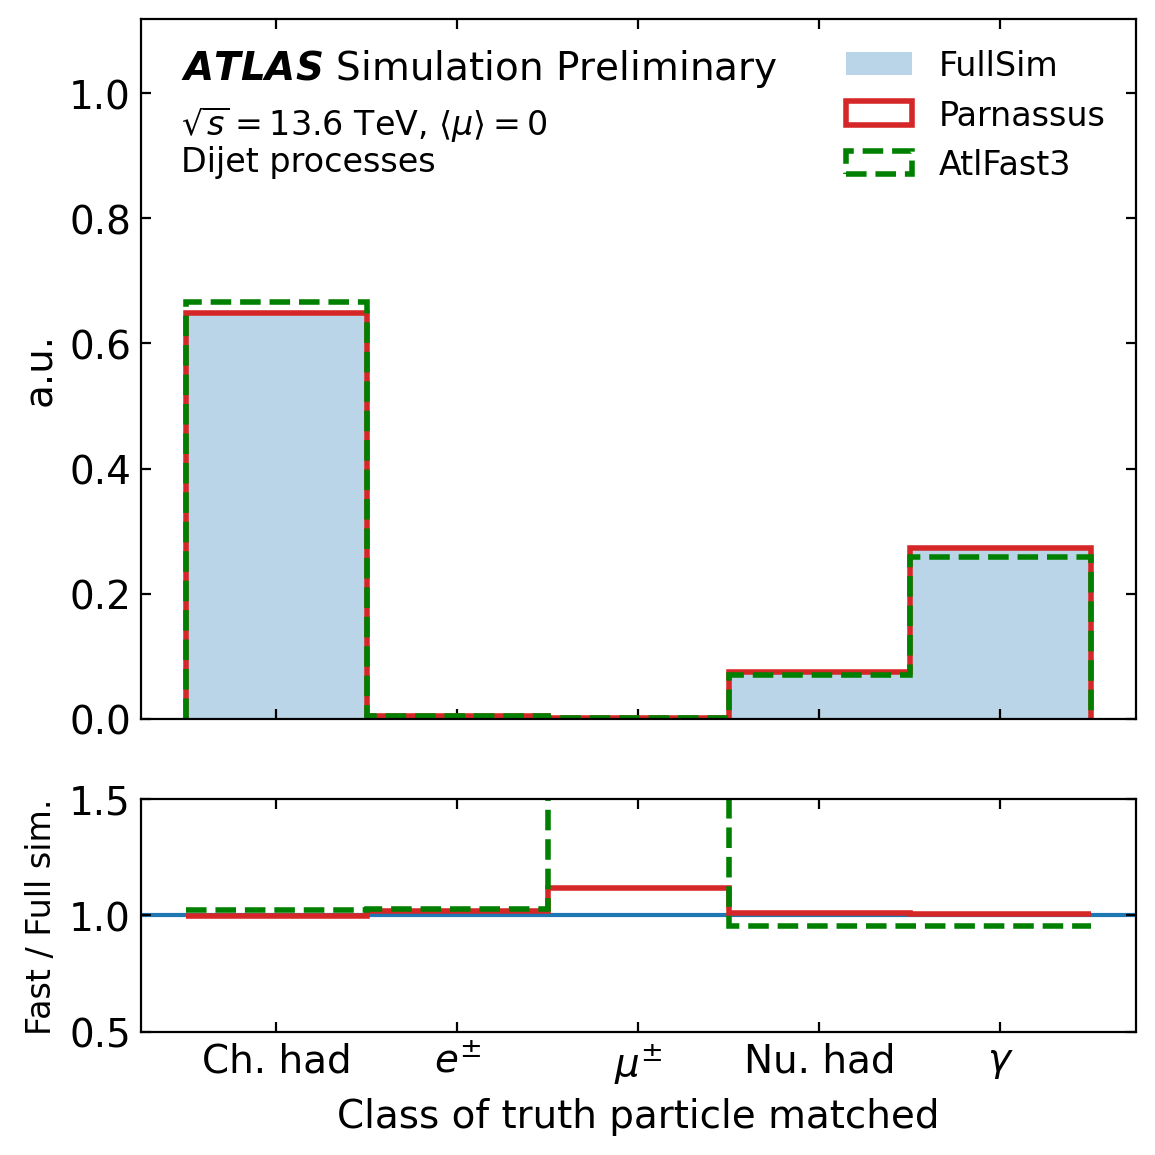

In [46]:
bins = np.arange(6) - 0.5

for i, sample in enumerate(samples_data.keys()):
    fig, ax_main, ax_ratio = _make_fig("Class of truth particle matched", yscale="linear", ratio_ylim=(0.5, 1.5))
    ref_counts = None

    for key in ['pf', *fms]:
        if 'fm' in key:
            good_color = good_colors[xbins.index(int(key[2:]))]
        s = (
            settings_dict.get(key, settings_dict["fm"] | {"label": "Parnassus", "color": good_color})
            | {"linewidth": 2}
        )
        # is_matched_to_neutral_pfo_mask = np.array(classes_dicts[sample][key][1]) > 2
        value = classes_dicts[sample][key][0] #[is_matched_to_neutral_pfo_mask]
        counts, _, _ =  _hist_overflow(ax_main,
            value,
            bins=bins,
            **(settings_dict.get(key, settings_dict["fm"] | {"label": f"Parnassus", "color" : good_color}) | {"linewidth" : 2}),
            density=True,
            histtype="stepfilled" if key == "pf" else "step",
        )
        if key == "pf":
            ref_counts = counts
        else:
            _add_ratio_line(ax_ratio, counts, bins, ref_counts, s)

    ax_ratio.set_xticks(
        np.arange(5),
        ["Ch. had", r"$e^{\pm}$", r"${\mu}^{\pm}$", "Nu. had", r"$\gamma$"],
        fontsize=fs,
    )

    _finalize_fig(fig, ax_main, ax_ratio)
    plt.show()

    fig.savefig(os.path.join(plot_dir, 'other', f"{sample}_particle_all_classes.png"))

# Unmatched particle marginal distributions

In [47]:
def get_unmatched_data(data, indices):
    varlist = ["pt", "eta", "phi"] #, "vx", "vy", "vz"]
    unmatched_data = {var: [] for var in varlist}
    idxs = np.arange(400)
    for i in range(len(data["pt"])):
        not_matched = np.setdiff1d(idxs[: len(data["pt"][i])], indices[i])
        for var in varlist:
            unmatched_data[var].append(data[var][i][not_matched])
    return unmatched_data

In [48]:
unmatched_data_dicts = {key: {} for key in samples_data.keys()}
unmatched_data_dicts_jet = {key: {} for key in samples_data.keys()}
unmatched_data_dicts_bkg = {key: {} for key in samples_data.keys()}

In [49]:
for sample in samples_data.keys():
    print(f"Processing... {sample} sample")
    for key in samples_data[sample]["all"].keys():
        if key == 'tr':
            continue
        unmatched_data_dicts[sample][key] = get_unmatched_data(
            samples_data[sample]["all"][key],
            particle_matching_dicts[sample][key][0],
        )
for sample in samples_data.keys():
    print(f"Processing... {sample} sample")
    for key in samples_data[sample]["all"].keys():
        if key == 'tr':
            continue
        unmatched_data_dicts_jet[sample][key] = get_unmatched_data(
            samples_data[sample]["jet"][key],
            particle_matching_dicts_jet[sample][key][0],
        )
for sample in samples_data.keys():
    print(f"Processing... {sample} sample")
    for key in samples_data[sample]["all"].keys():
        if key == 'tr':
            continue
        unmatched_data_dicts_bkg[sample][key] = get_unmatched_data(
            samples_data[sample]["bkg"][key],
            particle_matching_dicts_bkg[sample][key][0],
        )

Processing... JZall sample
Processing... JZall sample
Processing... JZall sample


In [50]:
bins_1d = {
    "pt": defaultdict(constant_factory(np.linspace(0, 600, 40))),
    "eta": defaultdict(constant_factory(np.linspace(-2.7, 2.7, 40))),
    "phi": defaultdict(constant_factory(np.linspace(-np.pi, np.pi, 40))),
}

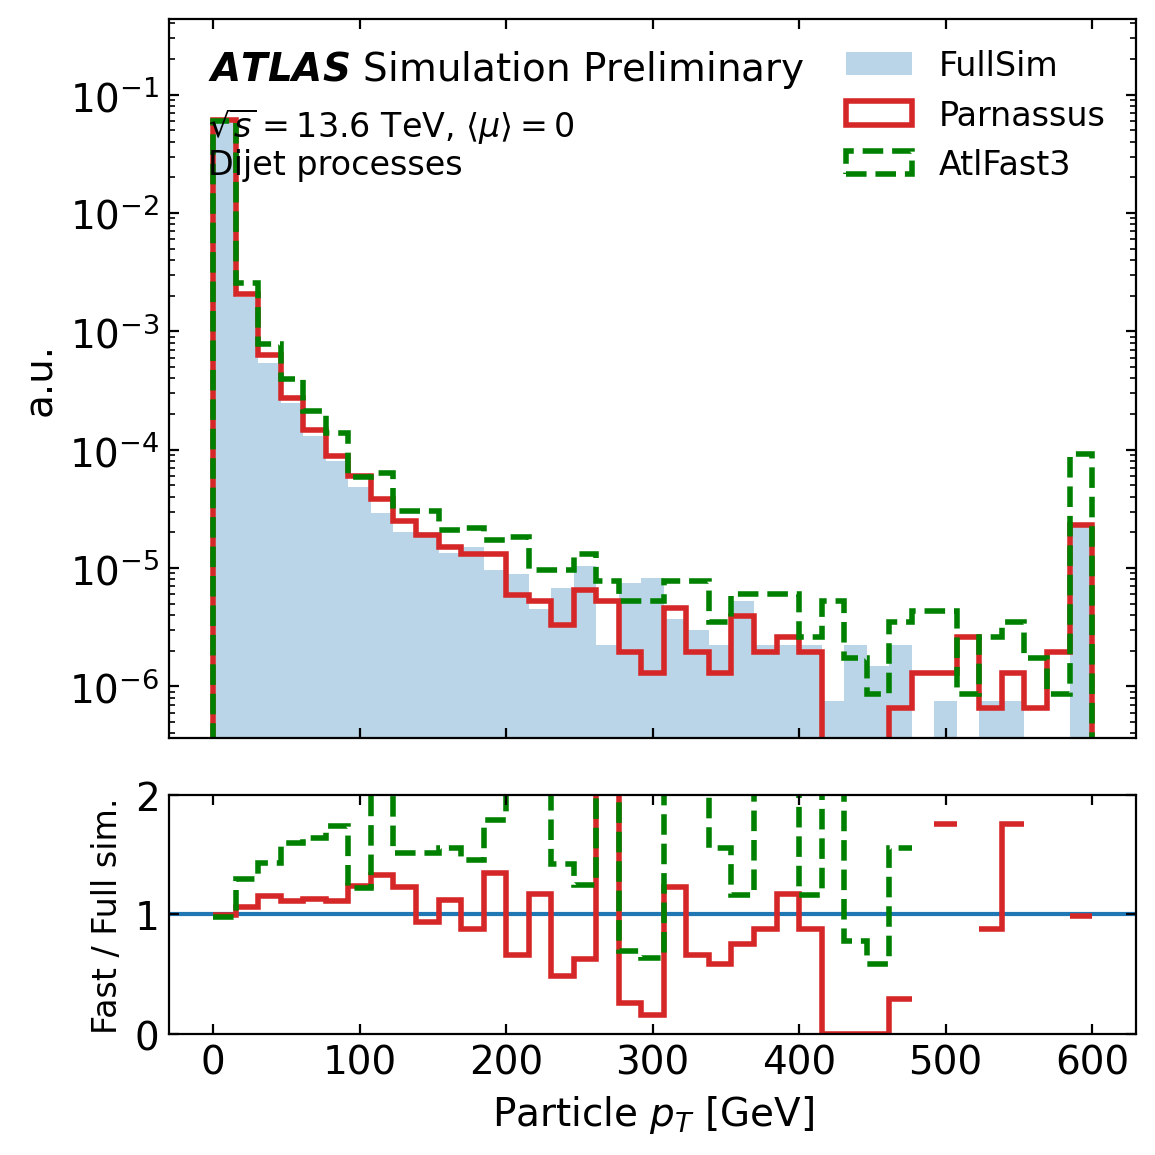

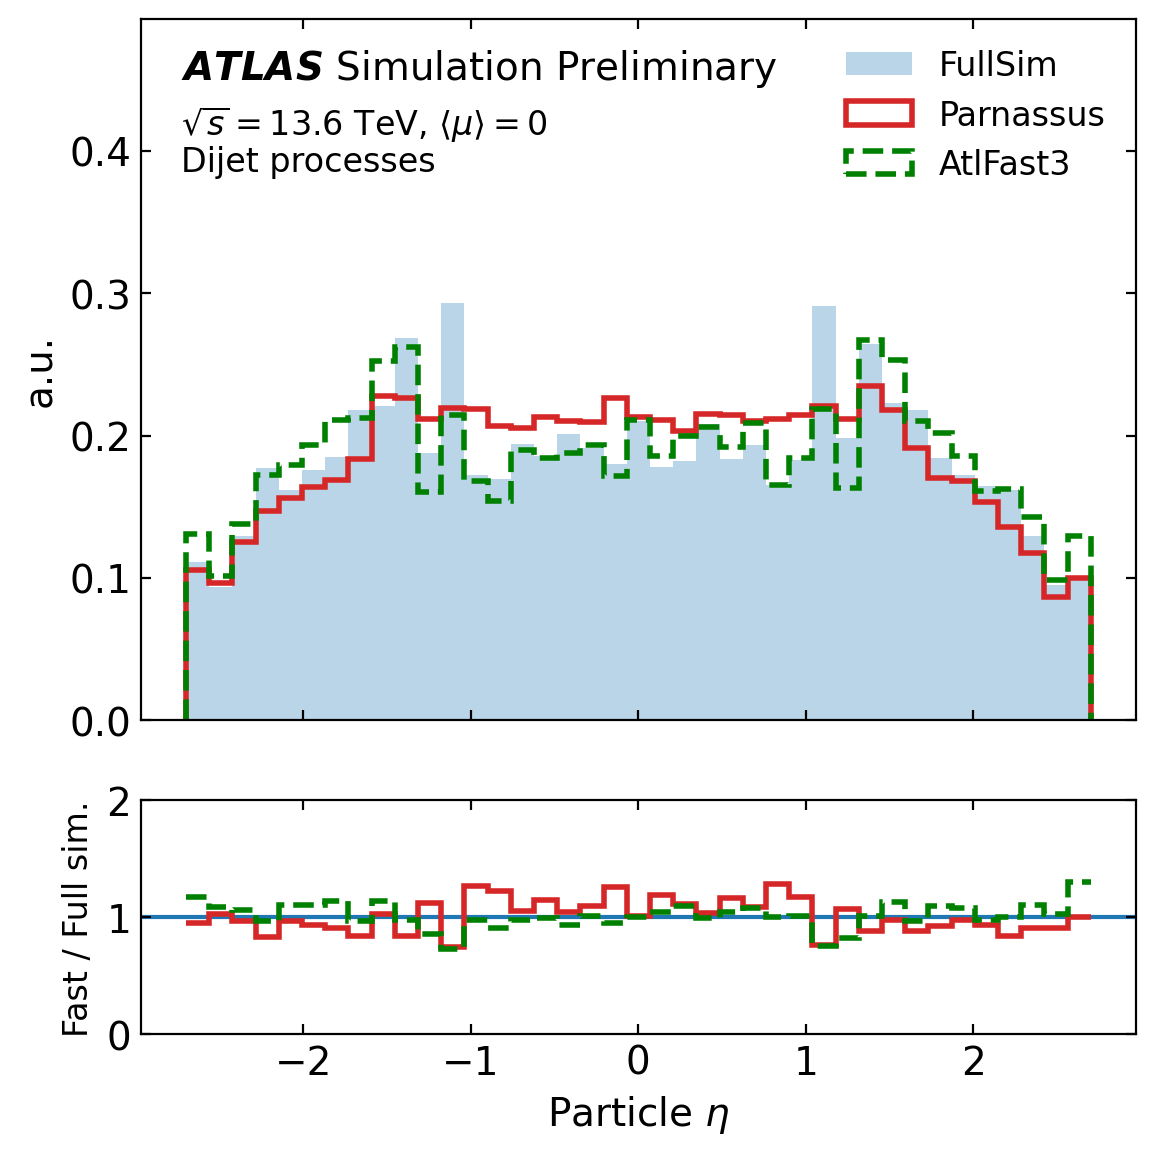

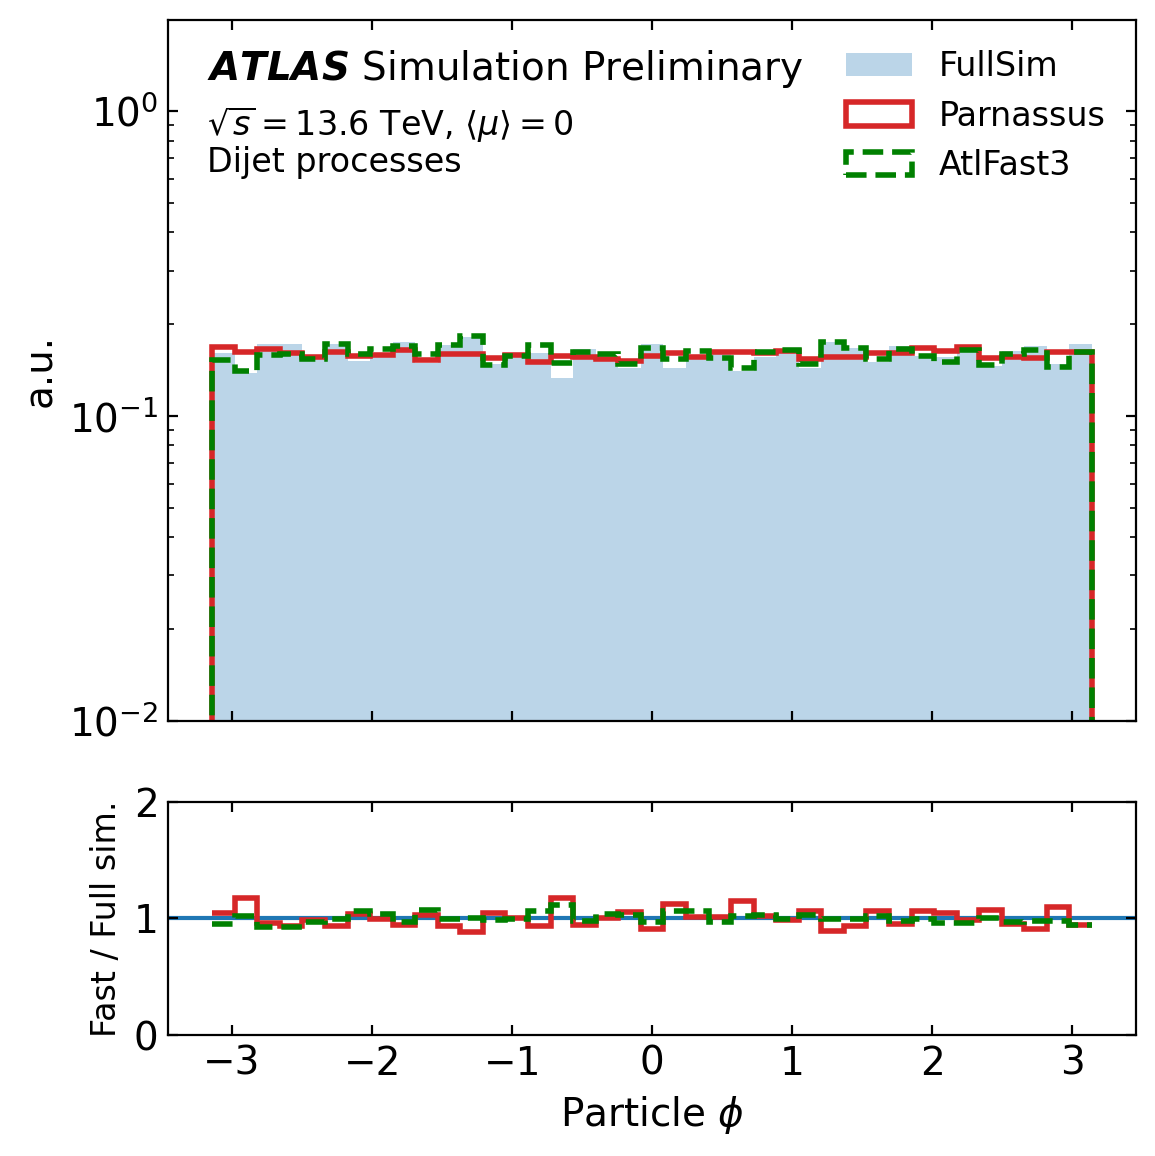

In [51]:

unmatch_var_list    = ["pt", "eta", "phi"]
unmatch_xlabel_list = [r"Particle $p_T$ [GeV]", r"Particle $\eta$", r"Particle $\phi$"]

for sample in samples_data.keys():
    for j, (var, xlabel) in enumerate(zip(unmatch_var_list, unmatch_xlabel_list)):
        yscale = "log" if j != 1 else "linear"
        fig, ax_main, ax_ratio = _make_fig(xlabel, yscale=yscale)
        ref_counts = None

        for key in ['pf', *fms]:
            if 'fm' in key:
                good_color = good_colors[xbins.index(int(key[2:]))]
            s = (
                settings_dict.get(key, settings_dict["fm"] | {"label": "Parnassus", "color": good_color})
                | {"linewidth": 2}
            )
            value = np.concatenate(unmatched_data_dicts[sample][key][var])
            counts, _, _ = _hist_overflow(ax_main,
                value, bins=bins_1d[var][sample], **s,
                density=True,
                histtype="stepfilled" if key == "pf" else "step",
            )
            if key == "pf":
                ref_counts = counts
            else:
                _add_ratio_line(ax_ratio, counts, bins_1d[var][sample], ref_counts, s)

        if var == "phi":
            ax_main.set_ylim(1e-2, 0.5)

        _finalize_fig(fig, ax_main, ax_ratio)
        plt.show()

        fig.savefig(os.path.join(plot_dir, 'particle_unmatched', f"{sample}_particle_all_unmatched_{var}.png"))


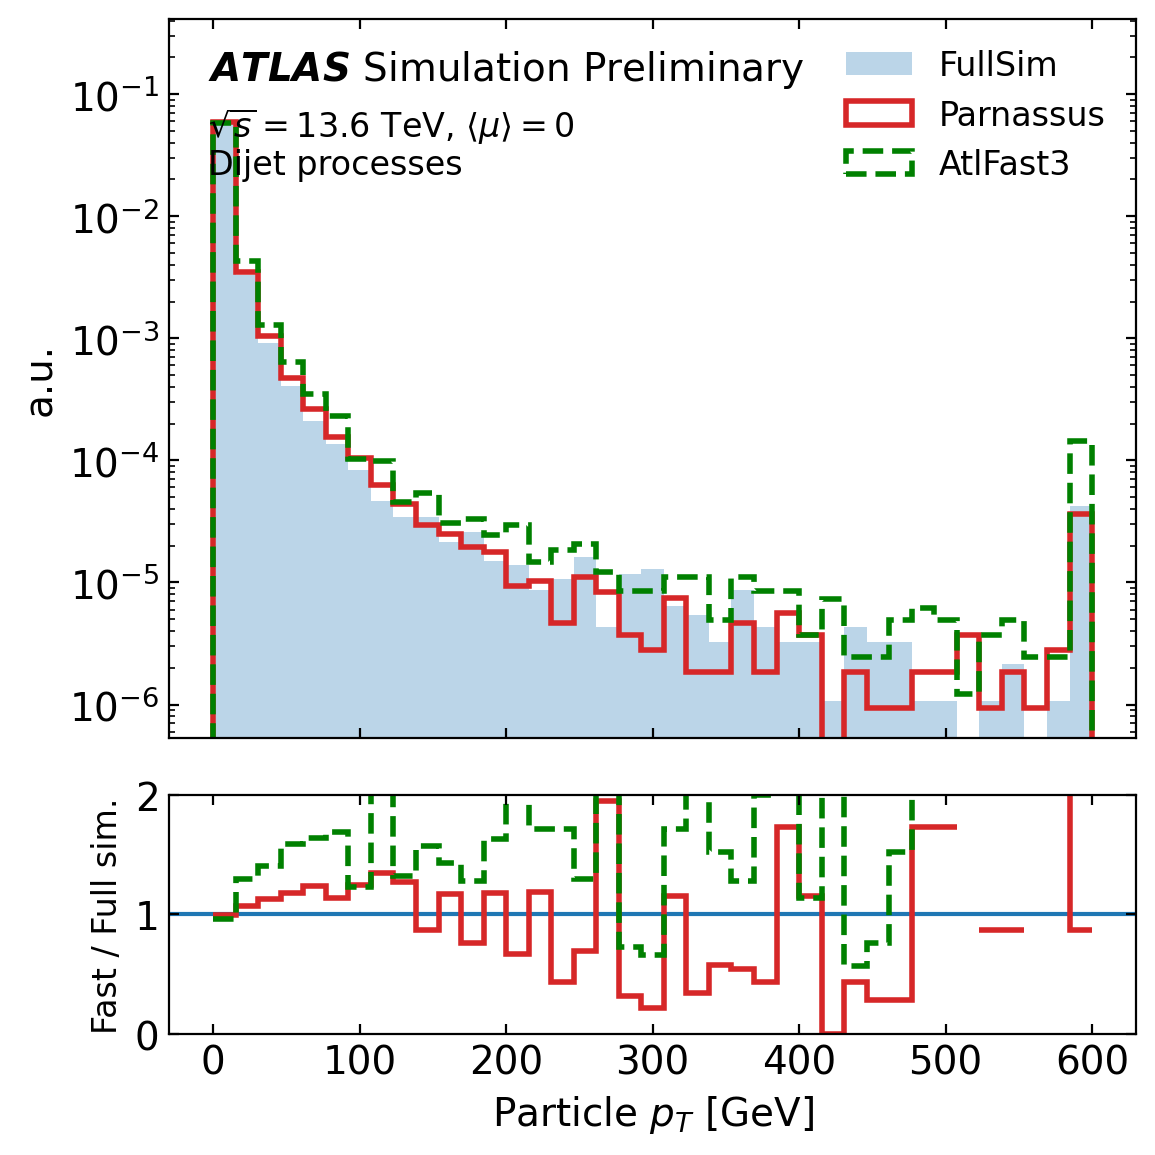

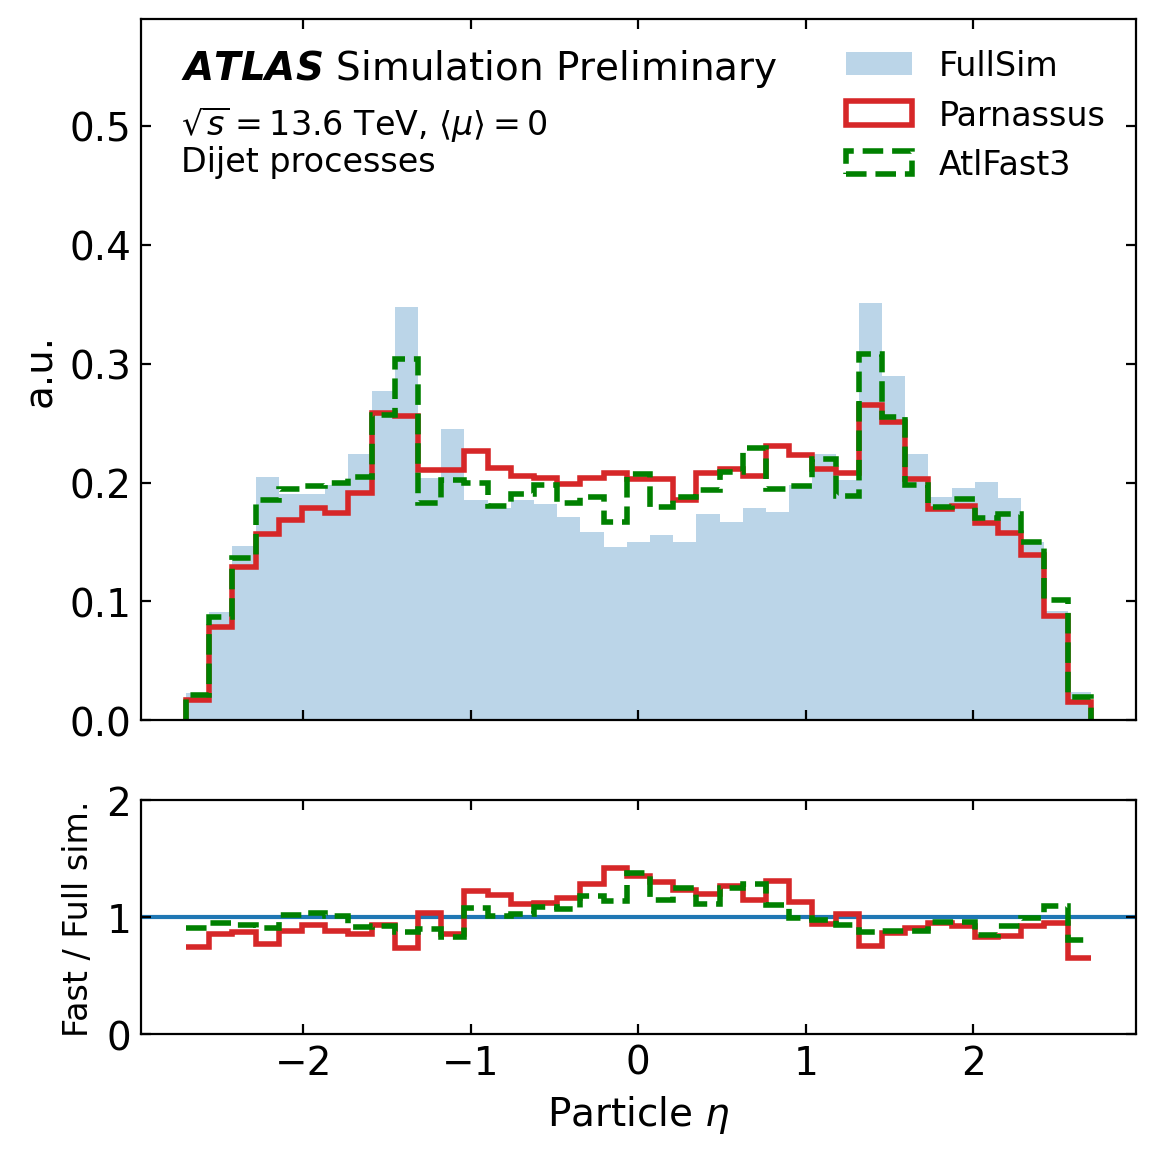

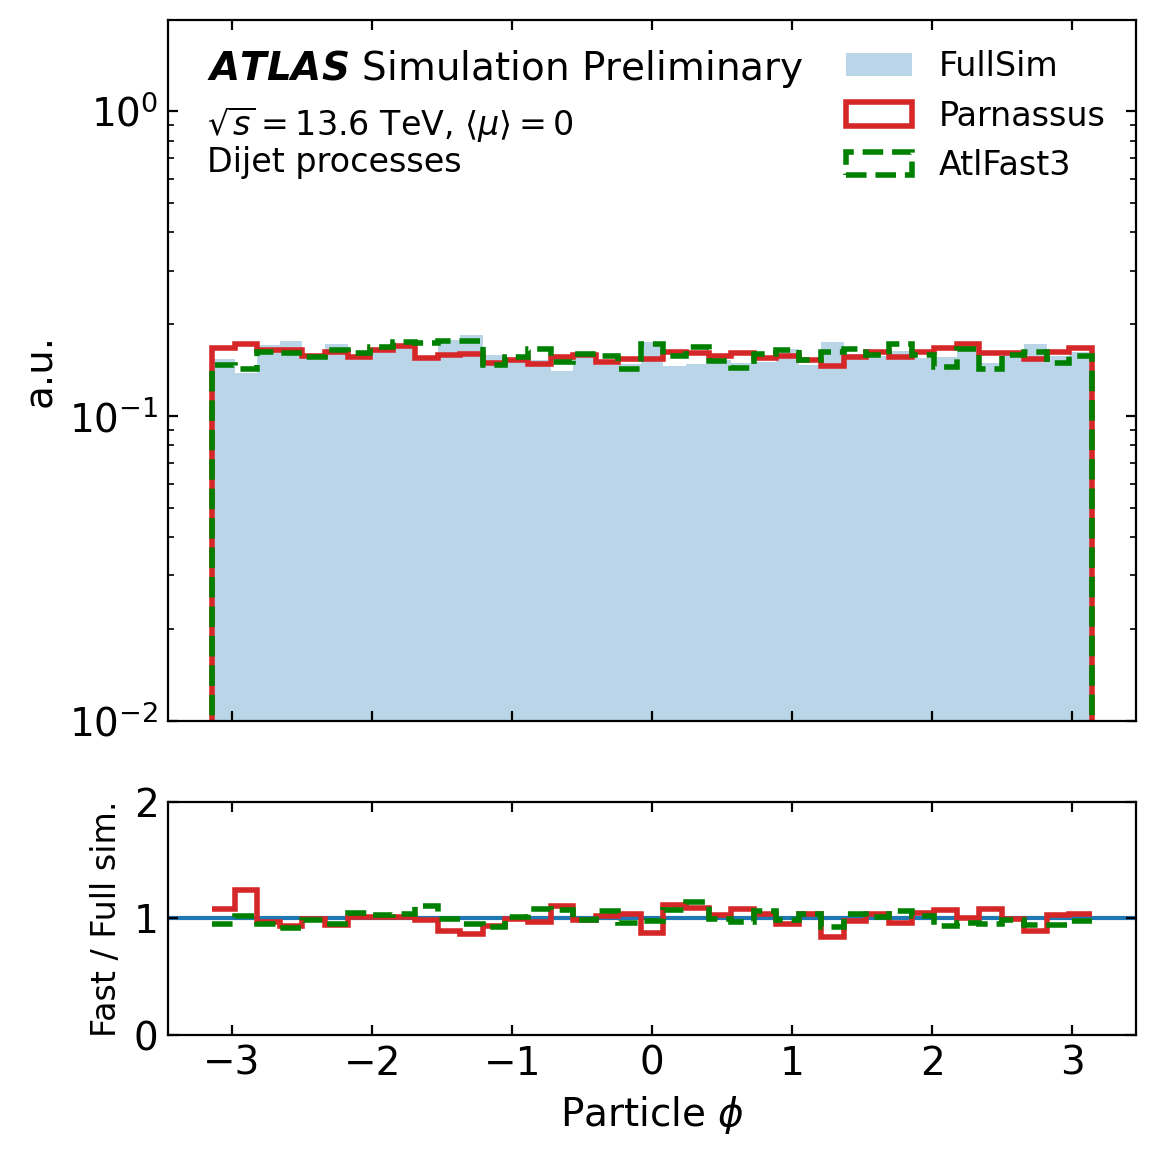

In [52]:

for sample in samples_data.keys():
    for j, (var, xlabel) in enumerate(zip(unmatch_var_list, unmatch_xlabel_list)):
        yscale = "log" if j != 1 else "linear"
        fig, ax_main, ax_ratio = _make_fig(xlabel, yscale=yscale)
        ref_counts = None

        for key in ['pf', *fms]:
            if 'fm' in key:
                good_color = good_colors[xbins.index(int(key[2:]))]
            s = (
                settings_dict.get(key, settings_dict["fm"] | {"label": "Parnassus", "color": good_color})
                | {"linewidth": 2}
            )
            value = np.concatenate(unmatched_data_dicts_jet[sample][key][var])
            counts, _, _ = _hist_overflow(ax_main,
                value, bins=bins_1d[var][sample], **s,
                density=True,
                histtype="stepfilled" if key == "pf" else "step",
            )
            if key == "pf":
                ref_counts = counts
            else:
                _add_ratio_line(ax_ratio, counts, bins_1d[var][sample], ref_counts, s)

        if var == "phi":
            ax_main.set_ylim(1e-2, 0.5)

        _finalize_fig(fig, ax_main, ax_ratio)
        plt.show()

        fig.savefig(os.path.join(plot_dir, 'particle_unmatched', f"{sample}_particle_jet_unmatched_{var}.png"))


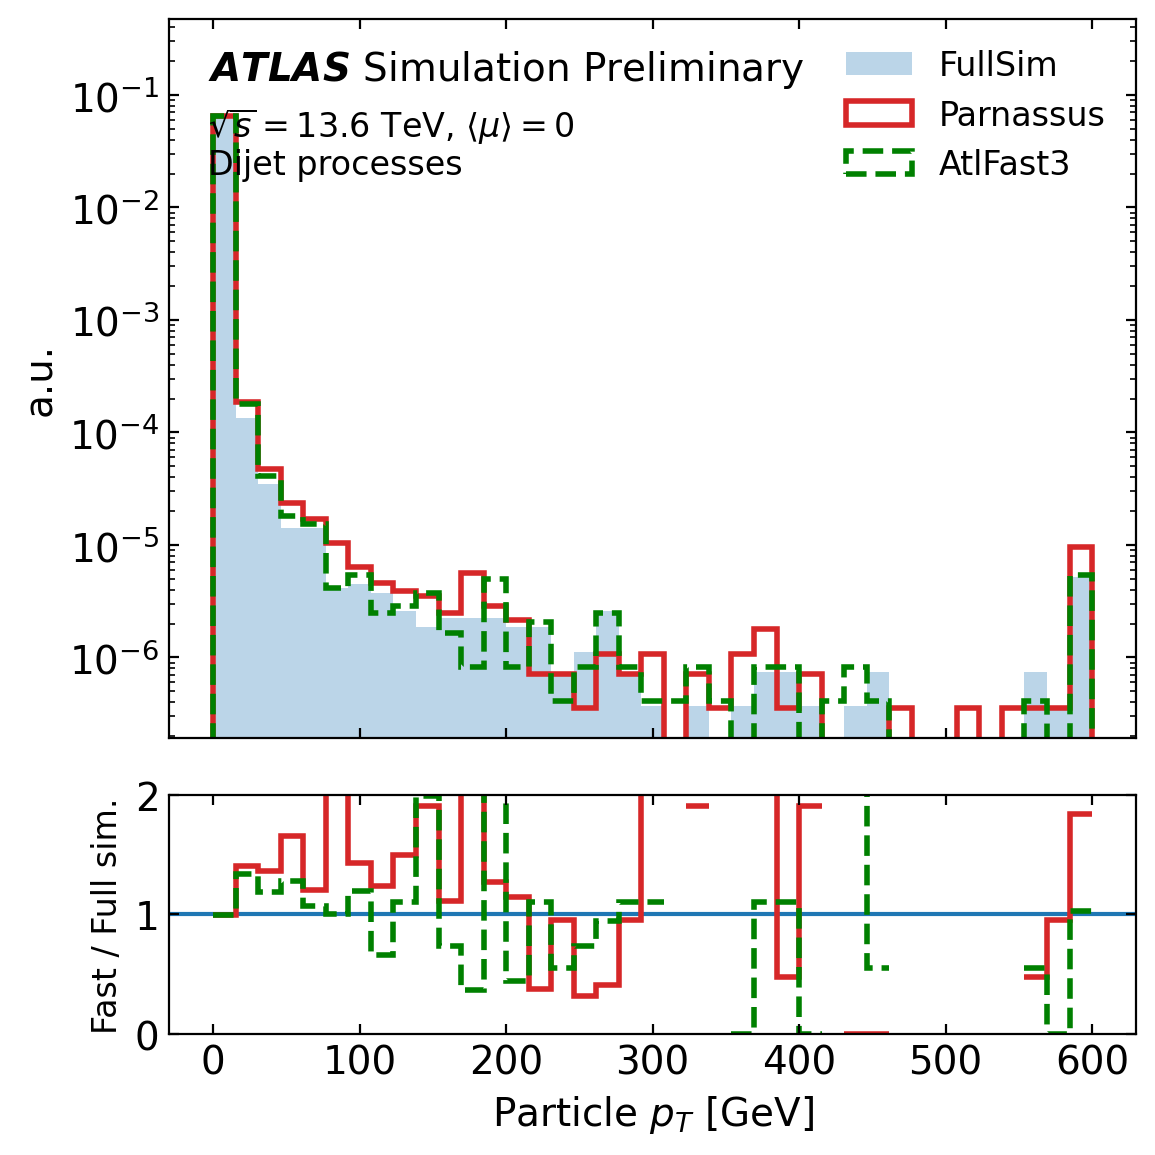

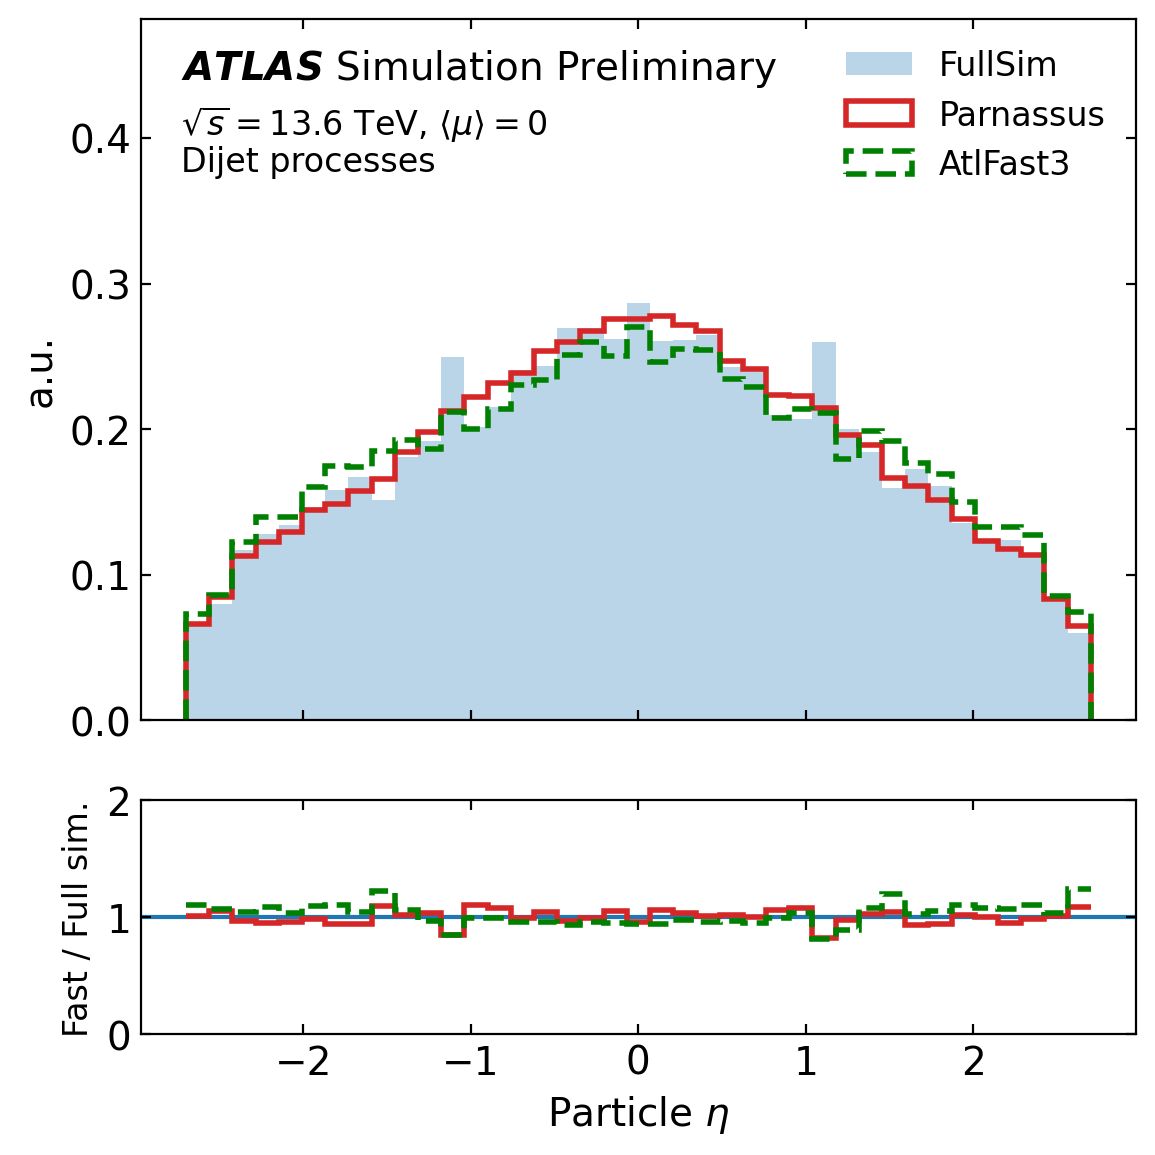

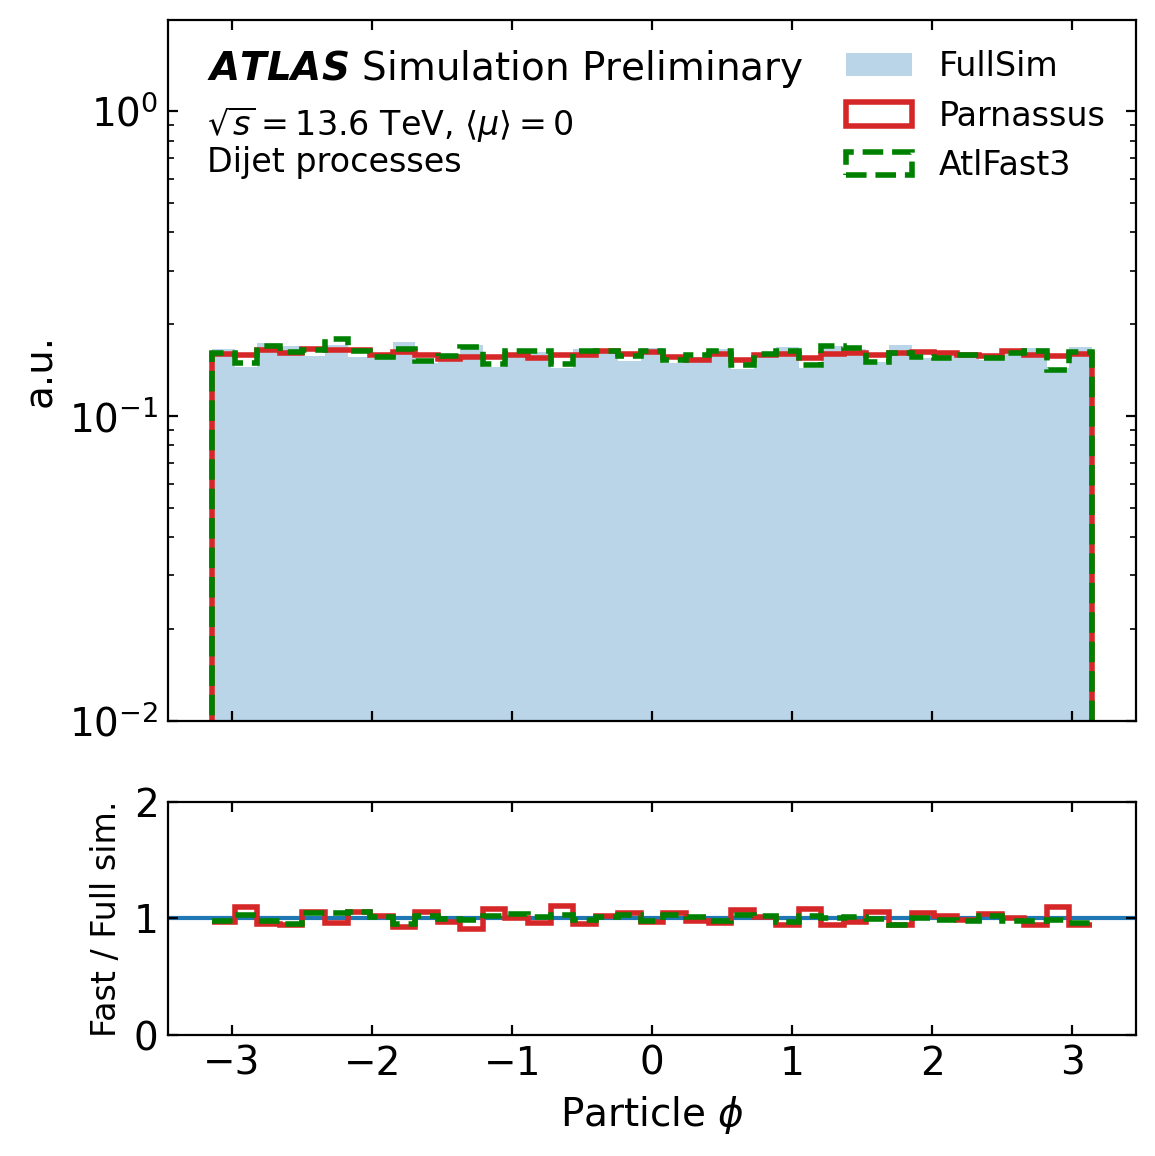

In [53]:

for sample in samples_data.keys():
    for j, (var, xlabel) in enumerate(zip(unmatch_var_list, unmatch_xlabel_list)):
        yscale = "log" if j != 1 else "linear"
        fig, ax_main, ax_ratio = _make_fig(xlabel, yscale=yscale)
        ref_counts = None

        for key in ['pf', *fms]:
            if 'fm' in key:
                good_color = good_colors[xbins.index(int(key[2:]))]
            s = (
                settings_dict.get(key, settings_dict["fm"] | {"label": "Parnassus", "color": good_color})
                | {"linewidth": 2}
            )
            value = np.concatenate(unmatched_data_dicts_bkg[sample][key][var])
            counts, _, _ = _hist_overflow(ax_main,
                value, bins=bins_1d[var][sample], **s,
                density=True,
                histtype="stepfilled" if key == "pf" else "step",
            )
            if key == "pf":
                ref_counts = counts
            else:
                _add_ratio_line(ax_ratio, counts, bins_1d[var][sample], ref_counts, s)

        if var == "phi":
            ax_main.set_ylim(1e-2, 0.5)

        _finalize_fig(fig, ax_main, ax_ratio)
        plt.show()

        fig.savefig(os.path.join(plot_dir, 'particle_unmatched', f"{sample}_particle_bkg_unmatched_{var}.png"))
